#Data Loading

In [ ]:
import os
import glob
import shutil
import random
import zipfile
import warnings

import numpy as np

from google.colab import drive

# Importing pyspark functions
from pyspark.sql import functions as F
from pyspark.sql import SparkSession, Row, Window
from pyspark.sql.types import ArrayType, StructType, StructField, StringType, FloatType, LongType, IntegerType, DoubleType
from pyspark.ml.fpm import FPGrowth, PrefixSpan

In [ ]:
warnings.filterwarnings("ignore", category=UserWarning)

Data uploading (csv formats)

In [ ]:
random.seed(42)
np.random.seed(42)

drive.mount('/content/drive')
data_path = "/content/drive/MyDrive/GoogleColab/Thesis Work Area/Data/"
archive_names = os.listdir(data_path)

def unzip_file(file_path, extract_to):
    with zipfile.ZipFile(file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    os.remove(file_path)

os.makedirs('/content/data', exist_ok=True)

for archive_name in archive_names:
    !cp "{data_path}{archive_name}" /content/
    unzip_file(f'/content/{archive_name}', '/content/data')

Mounted at /content/drive


Creating SparkSession object and "enable" arrow for the session to optimize and speed up processes

In [ ]:
os.environ["PYARROW_IGNORE_TIMEZONE"] = "1"

spark = SparkSession.builder \
    .config("spark.sql.ansi.enabled", "false") \
    .config("spark.sql.storeAssignmentPolicy", "LEGACY") \
    .getOrCreate()

key = "spark.sql.execution.arrow.pyspark.enabled"
prev = spark.conf.get(key, None)

Creating PySpark DataFrames

In [ ]:
files = sorted(os.listdir("data"))
aisles, departments, order_prod_prior, order_prod_train, orders, products, sample = [
    spark.read.csv(f"data/{file_name}", header=True, inferSchema=True) for file_name in files
]
aisles = aisles.filter(F.col("aisle_id")!=100)  # aisle 100 - Група товарів з невизначеною категорією

Making transactions set (with product names)

In [ ]:
search_data = order_prod_train.join(products, on="product_id", how="left")
search_data = search_data.join(aisles, on='aisle_id', how="left")
transactions = (
    search_data.groupBy("order_id")
    .agg(F.collect_list("product_name").alias("product_names"))
    .filter(F.size(F.col("product_names")) > 1)
)
transactions_groups = (
    search_data.groupBy("order_id")
    .agg(F.collect_list("aisle").alias("group_names"))
    .withColumn("group_names", F.array_distinct(F.col("group_names")))
    .filter(F.size(F.col("group_names")) > 1)
)

Making transactions set (with product ids) for SPMF

In [ ]:
spmf_transactions = (
    search_data.groupBy("order_id")
    .agg(F.collect_list("product_id").alias("product_ids"))
    .filter(F.size(F.col("product_ids")) > 1)
)

In [ ]:
tmp_dir = "/content/transactions_tmp_df"
final_path = "/content/transactions.txt"

shutil.rmtree(tmp_dir, ignore_errors=True)

(spmf_transactions
 .select(F.concat_ws(" ", "product_ids").alias("value"))
 .coalesce(1)
 .write
 .mode("overwrite")
 .text(tmp_dir)
)

part = glob.glob(tmp_dir + "/part*")[0]
shutil.move(part, final_path)
shutil.rmtree(tmp_dir, ignore_errors=True)

# Dataset specification

In [ ]:
total_users = orders.select("user_id").distinct().count()
print(f"Унікальних користувачів: {total_users:,}")

Унікальних користувачів: 206,209


In [ ]:
total_orders_all = orders.count()

print(f"Загальна кількість замовлень (всі історичні дані): {total_orders_all:,}")

Загальна кількість замовлень (всі історичні дані): 3,421,083


In [ ]:
total_products = products.select("product_id").distinct().count()
print(f"Унікальних товарів (SKU): {total_products:,}")

Унікальних товарів (SKU): 49,688


In [ ]:
total_aisles = aisles.count()
total_departments = departments.count()

print(f"Товарних рядів (aisles): {total_aisles}")
print(f"Макрокатегорій (departments): {total_departments}")

Товарних рядів (aisles): 133
Макрокатегорій (departments): 21


In [ ]:
total_items_bought = order_prod_train.count() + order_prod_prior.count()
print(f"Загальна кількість товарів у кошиках: {total_items_bought:,}")

avg_items_per_order = total_items_bought / total_orders_all
print(f"Середня кількість товарів у кошиках: {avg_items_per_order:.2f}")

Загальна кількість товарів у кошиках: 33,819,106
Середня кількість товарів у кошиках: 9.89


In [ ]:
display(products.limit(5).toPandas())

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [ ]:
display(orders.limit(5).toPandas())

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [ ]:
display(order_prod_train.limit(5).toPandas())

,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


In [ ]:
display(aisles.limit(5).toPandas())

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [ ]:
display(departments.limit(5).toPandas())

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
order_products_all = order_prod_prior.union(order_prod_train)

dark_bg = "#292929"
lime_color = "#e1ef72"
grid_color = "#444444"
text_color = "#FFFFFF"

plt.rcParams.update({
    "figure.facecolor": dark_bg,
    "axes.facecolor": dark_bg,
    "axes.edgecolor": dark_bg,
    "grid.color": grid_color,
    "text.color": text_color,
    "axes.labelcolor": text_color,
    "xtick.color": text_color,
    "ytick.color": text_color,
    "legend.facecolor": dark_bg,
    "legend.edgecolor": grid_color,
    "font.family": "sans-serif",
    "figure.titlesize": 16,
    "axes.titlesize": 14,
    "axes.labelsize": 12
})

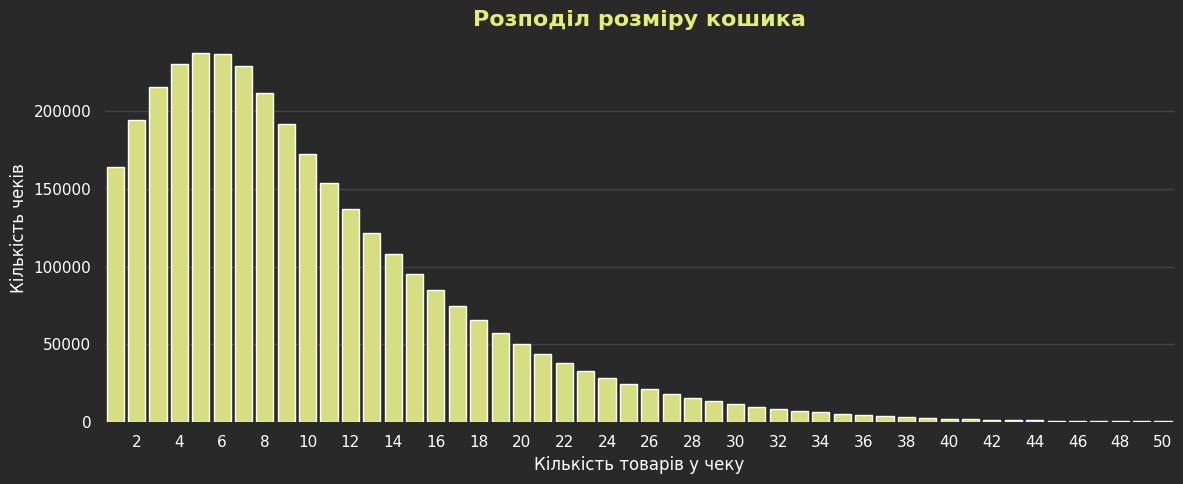

In [ ]:
# ======================================================
# 1. Графік: Розподіл розміру кошика
# ======================================================
basket_sizes = order_products_all.groupBy("order_id").count().withColumnRenamed("count", "basket_size")
size_distribution = basket_sizes.groupBy("basket_size").count().orderBy("basket_size").toPandas()

size_distribution = size_distribution[size_distribution['basket_size'] <= 50]

plt.figure(figsize=(12, 5))
sns.barplot(data=size_distribution, x='basket_size', y='count', color=lime_color)

plt.title('Розподіл розміру кошика', fontsize=16, color=lime_color, weight='bold')
plt.xlabel('Кількість товарів у чеку', fontsize=12)
plt.ylabel('Кількість чеків', fontsize=12)

plt.xticks(ticks=range(1, 50, 2), labels=range(2, 51, 2))
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [ ]:
from matplotlib.ticker import FuncFormatter

def format_numbers(x, pos):
    return f"{int(x):,}".replace(",", " ")

formatter = FuncFormatter(format_numbers)

/tmp/ipykernel_923/2268842941.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(data=top_aisles, y='aisle', x='count', palette=custom_palette)


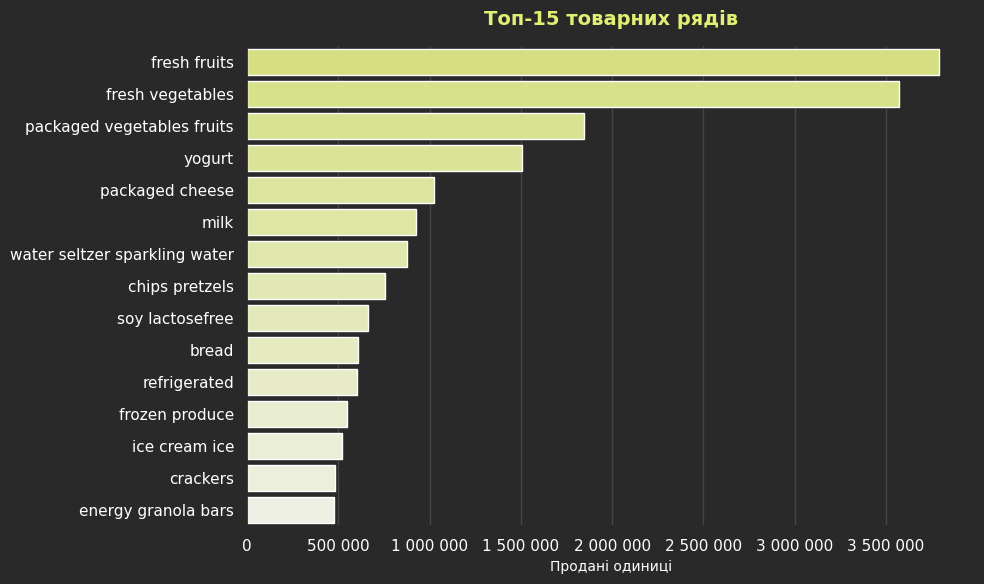

In [ ]:
all_search_data = order_products_all.join(products, on="product_id", how="left").join(aisles, on="aisle_id", how="left")
top_aisles = all_search_data.groupBy("aisle").count().orderBy(F.desc("count")).limit(15).toPandas()

plt.figure(figsize=(10, 6))
custom_palette = sns.light_palette(lime_color, n_colors=15, reverse=True)
ax2 = sns.barplot(data=top_aisles, y='aisle', x='count', palette=custom_palette)

plt.title('Топ-15 товарних рядів', fontsize=14, color=lime_color, weight='bold', pad=15)
plt.xlabel('Продані одиниці', fontsize=10)
plt.ylabel('')

ax2.xaxis.set_major_formatter(formatter)

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

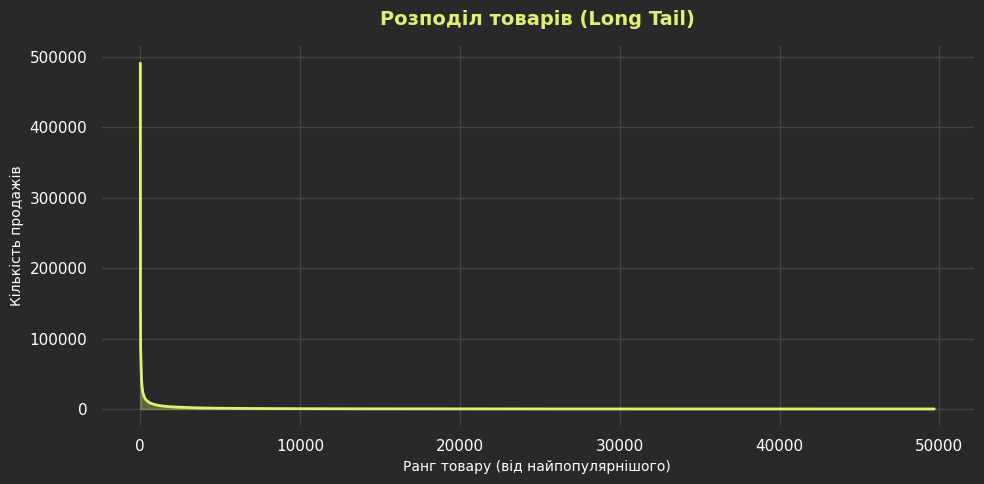

In [ ]:
product_freq = order_products_all.groupBy("product_id").count().orderBy(F.desc("count")).toPandas()
product_freq['rank'] = range(1, len(product_freq) + 1)

plt.figure(figsize=(10, 5))
plt.plot(product_freq['rank'], product_freq['count'], color=lime_color, linewidth=2)
plt.fill_between(product_freq['rank'], product_freq['count'], color=lime_color, alpha=0.3)
plt.title('Розподіл товарів (Long Tail)', fontsize=14, color=lime_color, weight='bold', pad=15)
plt.xlabel('Ранг товару (від найпопулярнішого)', fontsize=10)
plt.ylabel('Кількість продажів', fontsize=10)
plt.yscale('log')
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

In [ ]:
total_sales = product_freq['count'].sum()
top_20_percent_idx = int(len(product_freq) * 0.20)

sales_top_20 = product_freq.iloc[:top_20_percent_idx]['count'].sum()
sales_bottom_80 = product_freq.iloc[top_20_percent_idx:]['count'].sum()

tail_table = pd.DataFrame({
    "Сегмент асортименту": ["Топ 20% товарів (Бестселери)", "Нижні 80% товарів (Довгий хвіст)"],
    "Кількість SKU": [f"{top_20_percent_idx:,}", f"{len(product_freq) - top_20_percent_idx:,}"],
    "Загальні продажі (одиниць)": [f"{sales_top_20:,}", f"{sales_bottom_80:,}"],
    "Частка у виторгу (%)": [f"{(sales_top_20/total_sales)*100:.1f}%", f"{(sales_bottom_80/total_sales)*100:.1f}%"]
})

from IPython.display import display, HTML
print("\n=== ТАБЛИЦЯ РОЗПОДІЛУ (ДОВГИЙ ХВІСТ) ===")
display(HTML(tail_table.to_html(index=False, justify='center')))


=== ТАБЛИЦЯ РОЗПОДІЛУ (ДОВГИЙ ХВІСТ) ===


Сегмент асортименту,Кількість SKU,Загальні продажі (одиниць),Частка у виторгу (%)
Топ 20% товарів (Бестселери),"9,937","30,749,657",90.9%
Нижні 80% товарів (Довгий хвіст),"39,748","3,069,449",9.1%


# Method CHARM (SPMF)

In [ ]:
import re
import math
import itertools
import subprocess

from collections import defaultdict
from IPython.core.magic import register_cell_magic

In [ ]:
!apt-get update -qq
!apt-get install -y openjdk-21-jdk-headless
!wget -q http://www.philippe-fournier-viger.com/spmf/spmf.jar -O spmf.jar

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  openjdk-21-jre-headless
Suggested packages:
  openjdk-21-demo openjdk-21-source libnss-mdns fonts-dejavu-extra
  fonts-ipafont-gothic fonts-ipafont-mincho fonts-wqy-microhei
  | fonts-wqy-zenhei fonts-indic
The following NEW packages will be installed:
  openjdk-21-jdk-headless openjdk-21-jre-headless
0 upgraded, 2 newly installed, 0 to remove and 56 not upgraded.
Need to get 130 MB of archives.
After this operation, 299 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 openjdk-21-jre-headless amd64 21.0.10+7-1~22.04 [46.9 MB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd6

Функція презначена для компіляції коду в Java середовищі:

1. Створює тимчасовий файл Main.java.
2. Компілює його (javac) разом із бібліотекою spmf.jar.
3. Запускає його (java).

In [ ]:
JAVA_HOME = "/usr/lib/jvm/java-21-openjdk-amd64"
os.environ["JAVA_HOME"] = JAVA_HOME
os.environ["PATH"] = os.path.join(JAVA_HOME, "bin") + ":" + os.environ.get("PATH", "")

SPMF_JAR = os.path.abspath("spmf.jar")

@register_cell_magic
def java(line, cell):
    import tempfile, os, subprocess
    with tempfile.TemporaryDirectory() as tmpdir:
        path = os.path.join(tmpdir, "Main.java")
        with open(path, "w") as f:
            f.write(cell)

        compile_proc = subprocess.run(
            ["javac", "-cp", f"{SPMF_JAR}:{tmpdir}", path],
            capture_output=True, text=True,
            env=os.environ
        )

        if compile_proc.returncode != 0:
            print("❌ Compilation failed:\n", compile_proc.stderr)
            return

        run_proc = subprocess.run(
            ["java", "-cp", f"{SPMF_JAR}:{tmpdir}", "Main"],
            capture_output=True, text=True,
            env=os.environ
        )

        if run_proc.stderr:
            print("⚠️ Runtime stderr:\n", run_proc.stderr)

Функція apply_filters_and_export() призначена для початкової фільтрації за метриками. Вона приймає як mode, тобто режим фільтрації, так і окремі значення метрик (якщо треба відхилення від режиму по певній окремій метриці). Також присутня додаткова фільтрація: top_k_per_antecedent - "Для кожного набору товарів 'А' залиш тільки 5 найсильніших правил" та top_k_per_consequent - "Для кожного товару-наслідку 'Б' залиш тільки 10 правил, де він зустрічається".

Можливі режими mode:

- zero - нульова фільтрація. Лише застосовуєтсья min_lift > 1.2 (щоб гарантувати якість правил), а також top_k_per_antecedent = 5 та top_k_per_consequent = 10, щоб підсумкові правила були різноманітними, а не фокусувались навколо "єдиного" набору.
- lite - легка фільтрація. Застосувються дуже легкі налаштування для мінімальної фільтрації.
- conservative - консервативна фільтрація. Застосовується більш жорстка фільтрація.
- strict - дуже жорстка фільтрація для отримання ЛИШЕ якісних та інформативних правил.


Використовується в наступній функції - make_rules_advanced().

In [ ]:
def apply_filters_and_export(rules_df,
                             mode='conservative',
                             min_support=None, min_confidence=None, min_lift=None,
                             min_leverage=None, min_kulc=None, min_jaccard=None,
                             top_k_per_antecedent=None, top_k_per_consequent=None,
                             output_filtered="association_rules_filtered.xlsx",
                             output_excluded="association_rules_excluded.xlsx",
                             filter_order_col="lift"):
    presets = {
        'absolute': {
            'min_support': 0.0, 'min_confidence': 0.0, 'min_lift': 1.2,
            'min_leverage': 0.0, 'min_kulc': 0.0, 'min_jaccard': 0.0,
            'top_k_per_antecedent': None, 'top_k_per_consequent': None
        },
        'zero': {
            'min_support': 0.0, 'min_confidence': 0.0, 'min_lift': 1.2,
            'min_leverage': 0.0, 'min_kulc': 0.0, 'min_jaccard': 0.0,
            'top_k_per_antecedent': 5, 'top_k_per_consequent': 10
        },
        'lite': {
            'min_support': 0.0, 'min_confidence': 0.25, 'min_lift': 1.2,
            'min_leverage': 0.00005, 'min_kulc': 0.1, 'min_jaccard': 0.0005,
            'top_k_per_antecedent': 5, 'top_k_per_consequent': 10
        },
        'conservative': {
            'min_support': 0.0, 'min_confidence': 0.40, 'min_lift': 3.0,
            'min_leverage': 0.0002, 'min_kulc': 0.21, 'min_jaccard': 0.002,
            'top_k_per_antecedent': 5, 'top_k_per_consequent': 10
        },
        'strict': {
            'min_support': 0.00025, 'min_confidence': 0.45, 'min_lift': 4.0,
            'min_leverage': 0.00035, 'min_kulc': 0.24, 'min_jaccard': 0.0035,
            'top_k_per_antecedent': 3, 'top_k_per_consequent': 5
        }
    }

    if mode in presets:
        p = presets[mode]
        min_support = min_support if min_support is not None else p['min_support']
        min_confidence = min_confidence if min_confidence is not None else p['min_confidence']
        min_lift = min_lift if min_lift is not None else p['min_lift']
        min_leverage = min_leverage if min_leverage is not None else p['min_leverage']
        min_kulc = min_kulc if min_kulc is not None else p['min_kulc']
        min_jaccard = min_jaccard if min_jaccard is not None else p['min_jaccard']
        top_k_per_antecedent = top_k_per_antecedent if top_k_per_antecedent is not None else p['top_k_per_antecedent']
        top_k_per_consequent = top_k_per_consequent if top_k_per_consequent is not None else p['top_k_per_consequent']

    df = rules_df

    numeric_cols = ['support','confidence','lift','leverage','added_value','jaccard','cosine','kulczynski','conviction','chi2']
    for c in numeric_cols:
        if c in df.columns:
            df = df.withColumn(c, F.col(c).cast('double'))

    ant_col = 'antecedent' if 'antecedent' in df.columns else ('antecedent_names' if 'antecedent_names' in df.columns else None)
    cons_col = 'consequent' if 'consequent' in df.columns else ('consequent_names' if 'consequent_names' in df.columns else None)

    if ant_col is None or cons_col is None:
        raise ValueError("apply_filters_and_export requires columns antecedent/antecedent_names and consequent/consequent_names to exist in the rules DataFrame")

    df = df.withColumn('_ant_key', F.concat_ws('||', F.col(ant_col))) \
           .withColumn('_cons_key', F.concat_ws('||', F.col(cons_col)))

    if filter_order_col not in df.columns:
        for cand in ['lift','confidence','added_value','leverage','support']:
            if cand in df.columns:
                filter_order_col = cand
                break

    filtered = df.filter(
        (F.col('support') >= F.lit(min_support)) &
        (F.col('confidence') >= F.lit(min_confidence)) &
        (F.col('lift') >= F.lit(min_lift)) &
        (F.col('leverage') >= F.lit(min_leverage)) &
        (F.col('kulczynski') >= F.lit(min_kulc)) &
        (F.col('jaccard') >= F.lit(min_jaccard))
    )

    if top_k_per_antecedent is not None:
        w = Window.partitionBy('_ant_key').orderBy(F.col(filter_order_col).desc())
        filtered = filtered.withColumn('_rk', F.row_number().over(w)).filter(F.col('_rk') <= top_k_per_antecedent).drop('_rk')

    if top_k_per_consequent is not None:
        w2 = Window.partitionBy('_cons_key').orderBy(F.col(filter_order_col).desc())
        filtered = filtered.withColumn('_rk2', F.row_number().over(w2)).filter(F.col('_rk2') <= top_k_per_consequent).drop('_rk2')

    filtered_out = filtered.drop('_ant_key','_cons_key').orderBy(F.col(filter_order_col).desc())

    filtered_pd = filtered_out.toPandas()

    filtered_pd.to_excel(output_filtered, index=False, engine='openpyxl')

    print(f" - Filtered rules saved to {output_filtered}")

    return filtered_out

Функція make_rules_advanced() призначена для побудови правил та їх подальшої фільтрації з частих наборів після алгоритму CHARM.

1. Функція опрацьовує файл формату SPMF (1 2 3 #SUP: 50).
2. Розраховується нова метрика IPF (Аналог до IDF: наскільки рідкісний кожен товар).
3. Розраховуються правила з частих наборів + підрахунок різних метрик (а також кастомна метрика).
4. Перевіряється склад правила. Якщо всі товари правила (і ліва, і права частина) належать одному кластеру / полиці (aisle) / відділу (department) - правило видаляється (залежно від mode).
5. Виклик функції apply_filters_and_export() для фільтрації за метриками (кінцеве відсіювання правил).

In [ ]:
def make_rules_advanced(
    frequent_items_path,
    n_rules=20,
    minConfidence=0.4,
    minLift=1.2,
    filter="lift",
    decimals=4,
    show=False,
    filter_mode=None,
    pandas_df=None,
    membership_threshold=0.0,
    non_cluster=False,
    mode=None,
    department_mode=False,
    multy=True,
    conf_w=1,
    lift_w=1,
    ipf_w=1
):

    freq_itemsets = []
    pattern = re.compile(r'^\s*([\d]+(?:\s+[\d]+)*)\s+#SUP\s*:\s*([0-9]+)\s*$', flags=re.IGNORECASE)
    with open(frequent_items_path, 'r', encoding='utf-8') as f:
        for line in f:
            s = line.strip()
            if not s:
                continue
            m = pattern.match(s)
            if m:
                items = tuple(sorted(int(x) for x in re.split(r'\s+', m.group(1).strip()) if x != ''))
                support_count = int(m.group(2))
                freq_itemsets.append((items, support_count))

    freq_dict = {tuple(sorted(items)): sup for items, sup in freq_itemsets}

    def fmt_num(x, key=None):
        if isinstance(x, float):
            if math.isfinite(x):
                if key in ("support", "leverage"):
                    return f"{x:.6f}"
                else:
                    return round(x, decimals)
            else:
                return x
        return x

    # ---- IPF ----
    df_counts = defaultdict(int)

    N = 0
    with open("transactions.txt", "r", encoding="utf-8") as f:
        for ln in f:
            ln = ln.strip()
            if not ln:
                continue
            N += 1
            try:
                ids = [int(x) for x in ln.split() if x.strip()!='']
            except Exception:
                continue
            unique_ids = set(ids)
            for iid in unique_ids:
                df_counts[iid] += 1

    ipf_map = {}
    for iid, cnt in df_counts.items():
        if cnt > 0:
            ipf_map[iid] = math.log(N / cnt) if (N > 0 and cnt > 0) else 0.0
        else:
            ipf_map[iid] = 0.0
    # ---- IPF ----

    product_cluster_map = None
    if mode in ("cluster", "both"):
        if pandas_df is None:
            raise ValueError("mode 'cluster' requires passing pandas_df with columns ['product_name','cluster','membership_score']")
        prod_df = products.select("product_id", "product_name").toPandas()
        pd_src = pandas_df.copy()
        if "product_name" not in pd_src.columns:
            raise ValueError("pandas_df must contain 'product_name' column")
        if "membership_score" not in pd_src.columns:
            pd_src["membership_score"] = 0.0
        if "cluster" not in pd_src.columns:
            pd_src["cluster"] = -1
        merged = prod_df.merge(pd_src[["product_name", "cluster", "membership_score"]],
                               on="product_name", how="left")
        merged["membership_score"] = merged["membership_score"].fillna(0.0).astype(float)
        valid_mask = (~merged["cluster"].isna()) & ((merged["cluster"] != -1) | (non_cluster is True))
        product_cluster_map = dict(zip(
            merged.loc[valid_mask, "product_id"],
            zip(merged.loc[valid_mask, "cluster"].astype(int), merged.loc[valid_mask, "membership_score"])
        ))

    product_aisle_map = None
    if mode in ("aisle", "both"):
        prod_df = products.select("product_id", "product_name", "aisle_id").toPandas()
        prod_df["aisle_id"] = prod_df["aisle_id"].astype(str)
        try:
            aisles_pd = aisles.select("aisle_id", "aisle").toPandas()
            aisles_pd["aisle_id"] = aisles_pd["aisle_id"].astype(str)
            merged = prod_df.merge(aisles_pd, on="aisle_id", how="left")
            merged["aisle_identifier"] = merged["aisle"].fillna(merged["aisle_id"]).astype(str)
        except Exception:
            merged = prod_df.copy()
            merged["aisle_identifier"] = merged["aisle_id"].astype(str)

        merged["aisle_identifier"] = merged["aisle_identifier"].fillna("-999").astype(str)
        product_aisle_map = dict(zip(merged["product_id"], merged["aisle_identifier"]))

    product_department_map = None
    if department_mode:
        prod_df = products.select("product_id", "product_name", "department_id").toPandas()
        prod_df["department_id"] = prod_df["department_id"].astype(str)
        merged = prod_df.copy()
        merged["department_identifier"] = merged["department_id"].fillna("-999").astype(str)
        product_department_map = dict(zip(merged["product_id"], merged["department_identifier"]))

    rules = []
    candidates = []

    if multy:
        for items, sup_xy in freq_itemsets:
            if len(items) < 2:
                continue
            items = tuple(sorted(items))
            for i in range(1, len(items)):
                for X in itertools.combinations(items, i):
                    Y = tuple(sorted(set(items) - set(X)))
                    sup_x = freq_dict.get(tuple(sorted(X)))
                    sup_y = freq_dict.get(tuple(sorted(Y)))
                    if sup_x and sup_y and sup_x > 0 and sup_y > 0:
                        candidates.append((tuple(sorted(X)), tuple(sorted(Y)), sup_xy, sup_x, sup_y))
    else:
        pair_keys = [k for k in freq_dict.keys() if len(k) == 2]
        for pair in pair_keys:
            pair_sorted = tuple(sorted(pair))
            sup_xy = freq_dict.get(pair_sorted)
            a, b = pair_sorted
            sup_a = freq_dict.get((a,))
            sup_b = freq_dict.get((b,))
            if sup_xy and sup_a and sup_b and sup_a > 0 and sup_b > 0:
                candidates.append(((a,), (b,), sup_xy, sup_a, sup_b))
                candidates.append(((b,), (a,), sup_xy, sup_b, sup_a))

    for X, Y, sup_xy, sup_x, sup_y in candidates:
        P_xy = sup_xy / N
        P_x = sup_x / N
        P_y = sup_y / N

        support = P_xy
        confidence = (P_xy / P_x) if P_x > 0 else 0.0
        lift = (confidence / P_y) if P_y > 0 else float('inf')

        leverage = P_xy - P_x * P_y
        added_value = confidence - P_y

        denom_jacc = (P_x + P_y - P_xy)
        jaccard = (P_xy / denom_jacc) if denom_jacc > 0 else 0.0

        cosine = (P_xy / math.sqrt(P_x * P_y)) if (P_x > 0 and P_y > 0) else 0.0

        px_given_y = (P_xy / P_y) if P_y > 0 else 0.0
        kulczynski = 0.5 * (confidence + px_given_y)

        if (1.0 - confidence) == 0:
            conviction = float('inf')
        else:
            conviction = ((1.0 - P_y) / (1.0 - confidence)) if (1.0 - confidence) > 0 else float('inf')

        a = sup_xy
        b = sup_x - sup_xy
        c = sup_y - sup_xy
        d = N - sup_x - sup_y + sup_xy

        e11 = sup_x * sup_y / N
        e12 = sup_x * (N - sup_y) / N
        e21 = (N - sup_x) * sup_y / N
        e22 = (N - sup_x) * (N - sup_y) / N

        chi2 = 0.0
        for obs, exp in [(a, e11), (b, e12), (c, e21), (d, e22)]:
            if exp > 0:
                chi2 += (obs - exp) ** 2 / exp

        all_item_ids = list(X) + list(Y)

        if mode in ("cluster", "both") and product_cluster_map is not None:
            clusters = set()
            fail_membership = False
            for pid in all_item_ids:
                info = product_cluster_map.get(pid)
                if info is None:
                    fail_membership = True
                    break
                cluster_val, mem_score = info
                if membership_threshold > 0 and (mem_score is None or mem_score < membership_threshold):
                    fail_membership = True
                    break
                clusters.add(cluster_val)
            if fail_membership:
                continue
            if len(clusters) <= 1:
                continue

        if mode in ("aisle", "both") and product_aisle_map is not None:
            aisles_set = set()
            for pid in all_item_ids:
                aisle_ident = product_aisle_map.get(pid, "-999")
                aisles_set.add(str(aisle_ident))
            if len(aisles_set) <= 1:
                continue

        if department_mode and product_department_map is not None:
            depts_set = set()
            for pid in all_item_ids:
                dept_ident = product_department_map.get(pid, "-999")
                depts_set.add(str(dept_ident))
            if len(depts_set) <= 1:
                continue

        # ---- New Metric ----
        ipf_values = [ipf_map.get(int(pid), 0.0) for pid in all_item_ids]
        mean_ipf = sum(ipf_values) / len(ipf_values) if len(ipf_values) > 0 else 0.0
        log_lift = math.log(lift) if lift > 1 else 0.001
        weighted_score = (
            np.power(log_lift, lift_w) * np.power(mean_ipf, ipf_w) * np.power(confidence, conf_w)
        ) if (lift is not None and mean_ipf is not None and confidence is not None) else None
        # ---- New Metric ----

        rules.append(Row(
            antecedent=list(X),
            consequent=list(Y),
            sup_xy=int(sup_xy),
            sup_x=int(sup_x),
            sup_y=int(sup_y),
            support=fmt_num(float(support), "support"),
            confidence=fmt_num(float(confidence), "confidence"),
            log_lift=fmt_num(float(log_lift)),
            lift=fmt_num(float(lift), "lift"),
            weighted_score=fmt_num(float(weighted_score)) if weighted_score is not None else None,
            mean_ipf=fmt_num(float(mean_ipf)),
            leverage=fmt_num(float(leverage), "leverage"),
            added_value=fmt_num(float(added_value), "added_value"),
            jaccard=fmt_num(float(jaccard), None),
            cosine=fmt_num(float(cosine), None),
            kulczynski=fmt_num(float(kulczynski), None),
            conviction=fmt_num(float(conviction), None),
            chi2=fmt_num(float(chi2), None)
        ))

    rules_df = spark.createDataFrame(rules).filter((F.col("lift") > minLift) & (F.col("confidence") > minConfidence))

    antecedent_df = (
        rules_df
        .withColumn("antecedent_id", F.explode("antecedent"))
        .join(products.select("product_id", "product_name"),
              F.col("antecedent_id") == F.col("product_id"),
              "left")
        .groupBy("antecedent", "consequent",
                 "sup_xy", "sup_x", "sup_y",
                 "support", "confidence", "log_lift", "lift", "weighted_score", "mean_ipf",
                 "leverage", "added_value", "jaccard", "cosine",
                 "kulczynski", "conviction", "chi2")
        .agg(F.collect_list("product_name").alias("antecedent_names"))
    )

    rules_with_names = (
        antecedent_df
        .withColumn("consequent_id", F.explode("consequent"))
        .join(products.select("product_id", "product_name"),
              F.col("consequent_id") == F.col("product_id"),
              "left")
        .groupBy("antecedent", "consequent",
                 "sup_xy", "sup_x", "sup_y",
                 "support", "confidence", "log_lift", "lift", "weighted_score", "mean_ipf",
                 "leverage", "added_value", "jaccard", "cosine",
                 "kulczynski", "conviction", "chi2",
                 "antecedent_names")
        .agg(F.collect_list("product_name").alias("consequent_names"))
    )

    out_cols = ["antecedent_names", "consequent_names", "confidence", "lift", "log_lift", "mean_ipf", "weighted_score", "support"]

    if filter not in out_cols:
        filter = "lift"

    print(f"Base Rules:")
    print(f"Number of rules: { rules_with_names.select(*out_cols).count()}")
    if show:
      rules_with_names.select(*out_cols).orderBy(F.col(filter).desc()).show(n_rules, truncate=False)

    output_excel = "association_rules.xlsx"

    spark.conf.set(key, "false")
    try:
        rules_pd = (
            rules_with_names
            .select(*out_cols)
            .orderBy(F.col(filter).desc())
            .toPandas()
        )

        rules_pd.to_excel(output_excel, index=False, engine="openpyxl")
        print(f" - Base rules saved to {output_excel}")

        if filter_mode:
            print(f"Filtered Rules")
            filtered = apply_filters_and_export(rules_with_names.select(*out_cols), mode = filter_mode, filter_order_col = filter)
            print(f"Number of filtered rules: {filtered.count()}")
            filtered.show(n_rules, truncate=False)
    finally:
        if prev is None:
            spark.conf.set(key, "true")
        else:
            spark.conf.set(key, prev)

    if filter_mode:
        return filtered
    else:
        return rules_with_names.select(*out_cols).orderBy(F.col(filter).desc())

CHARM

In [ ]:
input_filename = "transactions.txt"
output_filename = "charm_output.txt"
memory_allocation = "-Xmx8g"
spmf_jar_path = "spmf.jar"
min_support = "0.01%"

command = [
    "java",
    memory_allocation,
    "-jar",
    spmf_jar_path,
    "run",
    "Charm_bitset",
    input_filename,
    output_filename,
    str(min_support)
]

print(f"Running: {' '.join(command)}")

try:
    result = subprocess.run(command, capture_output=True, text=True, check=True, encoding='utf-8')

    print("\n--- STDOUT (SPMF Stats) ---")
    print(result.stdout)

    if result.stderr:
        print("\n--- STDERR ---")
        print(result.stderr)

    print(f"\nThe CHARM algorithm has been successfully executed..")
    print(f"The results are saved to '{output_filename}'.")

except subprocess.CalledProcessError as e:
    print("\n--- SPMF RUNTIME ERROR ---")
    print("Return code:", e.returncode)
    print("Stdout:", e.stdout)
    print("Stderr:", e.stderr)

Running: java -Xmx8g -jar spmf.jar run Charm_bitset transactions.txt charm_output.txt 0.01%

--- STDOUT (SPMF Stats) ---
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
>/content/spmf.jar
=============  CHARM v96r6 Bitset - STATS =============
 Transactions count from database : 124364
 Frequent closed itemsets count : 154165
 Total time ~ 33538 ms
 Maximum memory usage : 7780.0 mb


--- STDERR ---
Apr 28, 2026 9:42:03 PM java.util.prefs.FileSystemPreferences$1 run
INFO: Created user preferences directory.
Apr 28, 2026 9:42:03 PM java.util.prefs.FileSystemPreferences$6 run


The CHARM algorithm has been successfully executed..
The results are saved to 'charm_output.txt'.


# Semantic Clustering

# Text Cleaning

In [ ]:
!pip install -q rapidfuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 45.1 MB/s eta 0:00:00


In [ ]:
import spacy
import unicodedata

from collections import Counter
from rapidfuzz import fuzz as rf_fuzz
from rapidfuzz.distance import Levenshtein
from rapidfuzz import process as rf_process

Визначення фільтрів для тексту (регулярні вирази):

- RE_BRACKET      - видаляє все що у дужках
- RE_WEIGHT       - видалення розмірності (вага, об'єм і так далі)
- RE_MULTIPACK    - видалення упаковок
- RE_SKU          - видалення кодів
- RE_EXCESS_PUNCT - залишаються лише літери, цифри, дефіс, амперсанд та апостроф. Решта (смайли, значки валют) видаляється.
- RE_ONLY_NUM     - видалення значень, де є лише цифри.

Функція _unicode_normalize() - нормалізація під один стандарт.

Функція clean_name_single() - на вхід отримує ОДНУ назву товару та прогоняє через різні перевірки / фільтри (регулярні вирази).

Функція clean_names_list() - на вхід отримує список неочищених назв товарів, після чого кожну назву прогоняє через функцію clean_name_single(). Результат зберігається у формат {"original": ..., "proc": ...}, де original - оригінальна навза, а proc - назва товару після фільтрації.

In [ ]:
RE_BRACKET = re.compile(r'[\(\[\{].*?[\)\]\}]')
RE_WEIGHT = re.compile(r'\b\d{1,3}([\.,]\d+)?\s?(oz|oz\.|g|kg|ml|l|lb|pound|pounds|ct|count|pack|pk|x)\b', flags=re.I)
RE_MULTIPACK = re.compile(r'\b(pack of|pk\b|set of|bundle|jumbo pack|pack)\b', flags=re.I)
RE_SKU = re.compile(r'\b(sku|upc|ean|gtin|barcode|lot|batch)\b[:#]?\s*\w*', flags=re.I)
RE_NONPRINT = re.compile(r'[^\x20-\x7E]', flags=re.UNICODE)
RE_EXCESS_PUNCT = re.compile(r'[^0-9a-zA-Z\s\-\&\']')
RE_ONLY_NUM = re.compile(r'^\s*[\d\W_]+\s*$')


def _unicode_normalize(s):
    return unicodedata.normalize('NFKC', s)


def clean_name_single(s,
                      lowercase=True,
                      remove_brackets=True,
                      remove_weights=True,
                      remove_multipack=True,
                      remove_sku=True,
                      remove_nonprintable=True,
                      remove_excess_punct=True,
                      collapse_whitespace=True,
                      replace_amp_with_and=True,
                      remove_leading_trailing_punct=True,
                      keep_numbers=False,
                      common_stop_tokens=None,
                      custom_substitutions=None):

    if s is None:
        s = ""
    orig = str(s)
    proc = _unicode_normalize(orig)

    if lowercase:
        proc = proc.lower()

    if remove_nonprintable:
        proc = RE_NONPRINT.sub(' ', proc)

    if remove_brackets:
        proc = RE_BRACKET.sub(' ', proc)

    if remove_weights:
        proc = RE_WEIGHT.sub(' ', proc)

    if remove_sku:
        proc = RE_SKU.sub(' ', proc)

    if remove_multipack:
        proc = RE_MULTIPACK.sub(' ', proc)

    if replace_amp_with_and:
        proc = re.sub(r'\s&\s', ' and ', proc)

    if RE_ONLY_NUM.match(proc.strip()):
        proc = ''

    if custom_substitutions:
        if isinstance(custom_substitutions, dict):
            items = custom_substitutions.items()
        else:
            items = custom_substitutions
        for pat, repl in items:
            proc = re.sub(pat, repl, proc, flags=re.I)

    if remove_excess_punct:
        if keep_numbers:
            proc = RE_EXCESS_PUNCT.sub(' ', proc)
        else:
            proc = re.sub(r'[^a-zA-Z\s\-\&\']', ' ', proc)

    if remove_leading_trailing_punct:
        proc = proc.strip("- ' &")

    if collapse_whitespace:
        proc = re.sub(r'\s+', ' ', proc).strip()

    if common_stop_tokens:
        toks = [t for t in proc.split() if t not in set(common_stop_tokens)]
        proc = " ".join(toks)

    return proc


def clean_names_list(names, deduplicate_exact=False):
    out = []
    seen = set()

    for orig in names:
        proc = clean_name_single(orig)

        if deduplicate_exact:
            if proc not in seen:
                out.append({"original": orig, "proc": proc})
                seen.add(proc)
        else:
            out.append({"original": orig, "proc": proc})

    return out

Audit:

Функція get_examples_changed() - виводить n правил, де відбулась зміна назви товару після фільтрації (перевірка якості фільтрації).

Функція get_proc_to_originals_map() - групує вихідні назви за їхньою очищеною версією.

Функція top_token_changes() - Рахує, які саме слова частіше за все видалялись (removed).

In [ ]:
def get_examples_changed(out, n=50):
    diffs = []
    for d in out:
        if (d['original'].lower() or "") != (d['proc'] or ""):
            diffs.append((d['original'], d['proc']))
    return diffs[:n]


def get_proc_to_originals_map(out, min_count=2):
    proc_map = defaultdict(list)
    for d in out:
        proc_map[d['proc']].append(d['original'])
    return {k: v for k, v in proc_map.items() if len(v) >= min_count}


def top_token_changes(out, top_n=50):
    removed = Counter()
    added = Counter()
    for d in out:
        o_toks = set(str(d['original']).lower().split())
        p_toks = set(str(d['proc']).lower().split())
        for tk in o_toks - p_toks:
            removed[tk] += 1
        for tk in p_toks - o_toks:
            added[tk] += 1
    return {'removed_top': removed.most_common(top_n), 'added_top': added.most_common(top_n)}

Для якісного очищення використовуємо NLP.

Допоміжна функція _tokenize_spacy() - призначена для того, щоб розділити вхідний текст на Оригінальне слово, лему (словникова форма), частину мови (noun / adj / ...).

Допоміжна функція _ngrams() - призначена щоб розділити вхідний текст (опис товару) на n частин. Необхідно для збереження контексту окремих слів.

Допоміжна функція _longest_common_contiguous() - призначена для пошуку найбільшої спільної частини в окремих групах назв товарів.

Функція _normalize_and_dedupe_tokens() - призначена для того, щоб видалити повторення слів: дублікати що йдуть підряд та просто повтори, що вже зустрічались в описі одного товару.

Функція _jaccard_mean() (Оцінка якості) - функція "суддя". Вона вирішує, наскільки добре запропонована назва (кандидат) описує всю групу товарів за допомогою коефіцієнту Жаккара.

$$J(A, B) = \frac{|A \cap B|}{|A \cup B|} = \frac{\text{Спільні слова}}{\text{Всі унікальні слова}}$$

Ми маємо кандидата (наприклад, "Organic Milk") і список реальних товарів у кластері. Функція рахує схожість кандидата з кожним реальним товаром і бере середнє арифметичне.

- Якщо результат 1.0 — кандидат ідеально описує всі товари.
- Якщо 0.0 — кандидат взагалі не містить слів з реальних товарів.

----------

Визначимо проблему:

Хочему привести схожі назви товарів до єдиної назви (це також має пофіксити опечатки в словах). Приклад:

Caramel milk icecream

Caramel miik icecreams

Ceramel milk icecream

Caramel milky icecream

Всі ці назви мають бути згруповані до єдиної назви: Caramel milk icecream

Як це зробити?

Функція _medoid_proc() - призначена щоб обрати "найбільш типового представника" в кожному описі товару. Ця функція:

- Бере кожне слово з групи.
- Рахує відстань Левенштейна до всіх інших слів у групі.
- Перемагає те слово, у якого сума відстаней до сусідів найменша. Воно стоїть "посередині".

Приклад:

Є група: ["banana", "bannana", "bananas"].

- banana схожа і на bannana (1 помилка), і на bananas (1 літера різниці). Сумарна відстань мала.
- bannana і bananas між собою відрізняються сильніше (2 зміни). Результат: banana — це медоїд (центр кластера).

----------

Функція aggregate_near_duplicates_spacy_v3():

На вхід приймає словник {"original": ..., "proc": ...}, тобто результат функції clean_names_list() на списку назв товарів.

**Етап 1. Групування (щось типу кластеризації):**

Спочатку функція бере список всіх очищених назв (unique_procs) і намагається згрупувати їх за схожістю написання.

1. Цикл rf_process.extract: Тут використовується бібліотека rapidfuzz. Вона бере одне слово (наприклад, gala apples) і шукає всіх сусідів, які схожі на нього на 90%+ (параметр score_cutoff=90). Тут використовується відстань Левенштейна, оскільки ми не групуємо за семантичною схожістю, а за синтаксичною (посимвольною).
2. Злиття (merged loop): Якщо виявиться, що Товар А схожий на Товар Б, а Товар Б схожий на Товар В, цей блок коду об'єднає їх у велику групу [А, Б, В].

**Результат етапу:** Ми отримуємо список кластерів. Наприклад: ['gala apples', 'apple gala', 'gala aplpes'].

**Етап 2. Аналіз всередині кластера (Вибори лідера):**

Тепер функція проходиться по кожному кластеру окремо. Її мета — вибрати або створити нову назву (rep - representative), яка замінить усі варіанти в групі.

1. Токенізація (_tokenize_spacy): Всі варіанти назв у кластері розбираються на слова, леми та частини мови.

- Ми дізнаємося, що в gala apples слово apples — це іменник (NOUN), а gala — власна назва (PROPN).

2. Пошук кандидатів на нову назву: Функція генерує кілька варіантів "ідеальної назви".

- Кандидат 1: Медоїд (_medoid_proc): Функція шукає рядок, який математично знаходиться "в центрі" групи (найменша сума відстаней до інших). Це найбезпечніший варіант.
- Кандидат 2: Ядро (_longest_common_contiguous): Шукає найдовшу фразу, яка гарантовано є у всіх.
- Кандидат 3: Медоїд + Важливі іменники: Якщо він бачить, що слово apples (іменник) є майже у всіх варіантах, але чомусь випало з Медоїда — він примусово додає його назад. Це захист від втрати змісту.
- Кандидат 4: Union (Об'єднання): Спроба склеїти всі важливі слова разом.

**Етап 3. Голосування (Оцінка якості):**

Тепер у нас є список кандидатів. Хто з них кращий?

Тут працює функція _jaccard_mean(). Вона перевіряє кожного кандидата: "Наскільки добре цей набір слів покриває слова з усіх оригінальних назв у кластері?"

- Формула оцінки (score): coverage - length_penalty.
- Ми хочемо максимальне покриття слів, але штрафуємо за надто довгі назви (щоб не вийшло Gala Apples Red Fresh Fruit).

Переможець стає rep (представником).

**Етап 4: Заміна**

Функція створює словник proc_to_rep і замінює всі варіації в оригінальних даних на обраного переможця.

In [ ]:
_nlp = spacy.load("en_core_web_sm", disable=["parser", "ner", "textcat"])
_TOKEN_RE = re.compile(r'\w+')


def _tokenize_spacy(text, min_token_length=2):
    doc = _nlp((text or "").strip())
    toks, lems, poss = [], [], []
    for t in doc:
        tok = t.text.strip().lower()
        if len(tok) < min_token_length:
            continue
        if not _TOKEN_RE.fullmatch(tok):
            continue
        toks.append(tok)
        lems.append(t.lemma_.lower())
        poss.append(t.pos_)
    return toks, lems, poss


def _ngrams(tokens, n):
    return [" ".join(tokens[i:i+n]) for i in range(len(tokens)-n+1)] if len(tokens) >= n else []

def _longest_common_contiguous(tokens_list, min_len=2):
    if not tokens_list:
        return []
    min_len_tokens = min(len(t) for t in tokens_list)
    for n in range(min_len_tokens, min_len-1, -1):
        sets = [set(_ngrams(toks, n)) for toks in tokens_list]
        common = set.intersection(*sets) if sets else set()
        if common:
            return sorted(list(common), key=lambda s: (-sum(s in set(_ngrams(t, n)) for t in tokens_list), s))[0].split()
    return []


def _medoid_proc(procs):
    if not procs:
        return ""
    if len(procs) == 1:
        return procs[0]
    best = None
    best_score = None
    for a in procs:
        s = 0
        for b in procs:
            if a == b: continue
            s += Levenshtein.distance(a, b)
        if best_score is None or s < best_score or (s == best_score and a < best):
            best, best_score = a, s
    return best


def _normalize_and_dedupe_tokens(tokens):
    deduped = []
    seen = set()
    for t in tokens:
        tl = t.lower().strip()
        if not tl:
            continue
        if deduped and deduped[-1].lower().strip() == tl:
            continue
        if tl in seen:
            continue
        deduped.append(t)
        seen.add(tl)
    return deduped


def _jaccard_mean(candidate_tokens, procs_tokens_list):
    if not procs_tokens_list:
        return 0.0
    cand_set = set([t.lower() for t in candidate_tokens])
    vals = []
    for toks in procs_tokens_list:
        s = set([t.lower() for t in toks])
        inter = len(cand_set & s)
        union = len(cand_set | s) if len(cand_set | s) > 0 else 1
        vals.append(inter/union)
    return sum(vals)/len(vals)


def aggregate_near_duplicates_spacy_v3(
    out,
    score_cutoff=90,
    limit_per_item=None,
    min_common_tokens=2,
    noun_presence_fraction=0.5,
    min_rep_tokens=1,
    length_penalty=0.06,
    prefer_plural=False
):
    proc_to_originals = defaultdict(list)
    for d in out:
        proc = (d.get('proc') or '').strip()
        proc_to_originals[proc].append(d.get('original') or "")
    unique_procs = list(proc_to_originals.keys())

    unused = set(unique_procs)
    clusters = []
    for base in unique_procs:
        if base not in unused:
            continue
        group = {base}
        unused.remove(base)
        matches = rf_process.extract(base, {p:p for p in unused}, scorer=rf_fuzz.ratio, limit=limit_per_item)
        for m in matches:
            match_str = m[0]; score = m[1]
            if score >= score_cutoff and match_str in unused:
                group.add(match_str)
        for p in list(group):
            if p in unused:
                unused.remove(p)
        clusters.append(sorted(group))

    merged = []
    for c in clusters:
        placed=False
        for i,m in enumerate(merged):
            if set(c)&set(m):
                merged[i] = sorted(list(set(m)|set(c))); placed=True; break
        if not placed:
            merged.append(c)
    clusters = merged

    clusters_info=[]
    proc_to_rep = {}

    for c in clusters:
        if len(c) <= 1:
            continue
        procs = list(c)
        procs_tokens = []
        procs_lems = []
        procs_pos = []
        for p in procs:
            toks, lems, poss = _tokenize_spacy(p)
            procs_tokens.append(toks)
            procs_lems.append(lems)
            procs_pos.append(poss)

        med = _medoid_proc(procs)

        core = _longest_common_contiguous(procs_tokens, min_len=min_common_tokens)

        lemma_in_proc = defaultdict(set)
        lemma_surface_by_proc = defaultdict(lambda: defaultdict(Counter))
        for i,p in enumerate(procs):
            toks, lems, poss = procs_tokens[i], procs_lems[i], procs_pos[i]
            seen = set()
            for tok, lem, pos in zip(toks, lems, poss):
                if lem not in seen:
                    lemma_in_proc[lem].add(i)
                    seen.add(lem)
                lemma_surface_by_proc[lem][i][tok]+=1

        noun_candidates = []
        for lem, proc_set in lemma_in_proc.items():
            if len(proc_set) >= math.ceil(noun_presence_fraction * len(procs)):
                pos_counts = 0
                for i in proc_set:
                    if i < len(procs_pos):
                        for tok, l, pos in zip(procs_tokens[i], procs_lems[i], procs_pos[i]):
                            if l == lem and pos in ('NOUN','PROPN'):
                                pos_counts += 1
                                break
                if pos_counts >= math.ceil(noun_presence_fraction * len(proc_set)):
                    candidates = []
                    for i in proc_set:
                        candidates.extend(list(lemma_surface_by_proc[lem][i].elements()))
                    surf = _medoid_proc(list(set(candidates)))
                    noun_candidates.append((lem, surf, len(proc_set)))
        candidates = []

        candidates.append(("medoid", med))

        if core:
            candidates.append(("core", " ".join(core)))

        med_toks, med_lems, med_pos = _tokenize_spacy(med)
        med_lem_set = set(med_lems)
        missing_nouns = [surf for (lem,surf,count) in noun_candidates if lem not in med_lem_set]
        if missing_nouns:
            append_nouns = missing_nouns[:2]
            cand = med + " " + " ".join(append_nouns)
            candidates.append(("medoid_plus_nouns", cand))

        union_tokens = med_toks[:]
        for (lem, surf, cnt) in noun_candidates:
            if lem not in med_lem_set:
                union_tokens.append(surf)
        if len(union_tokens) > 0:
            candidates.append(("union_pruned", " ".join(union_tokens)))

        proc_tokens_lists = procs_tokens
        best_score = None
        best_cand = None
        for tag, cand in candidates:
            cand_toks = [t for t in _tokenize_spacy(cand)[0]]
            if not cand_toks:
                continue
            cand_toks = _normalize_and_dedupe_tokens(cand_toks)
            coverage = _jaccard_mean(cand_toks, proc_tokens_lists)
            score = coverage - length_penalty * len(cand_toks)
            if best_score is None or score > best_score or (abs(score - best_score) < 1e-6 and tag == "medoid"):
                best_score = score
                best_cand = (tag, cand, cand_toks, coverage, score)

        if best_cand is None:
            proc_counts = {p: len(proc_to_originals.get(p, [])) for p in procs}
            rep = max(proc_counts.items(), key=lambda x:x[1])[0]
        else:
            rep = best_cand[1]
            rep_toks = _normalize_and_dedupe_tokens(_tokenize_spacy(rep)[0])
            rep = " ".join(rep_toks)

        if not rep:
            proc_counts = {p: len(proc_to_originals.get(p, [])) for p in procs}
            rep = max(proc_counts.items(), key=lambda x:x[1])[0]

        for p in procs:
            proc_to_rep[p] = rep

        clusters_info.append({'cluster_procs': procs, 'rep': rep, 'n_procs': len(procs), 'n_origins': len(procs)})

    new_out = []
    for d in out:
        proc = (d.get('proc') or '').strip()
        new_proc = proc_to_rep.get(proc, proc)
        new_out.append({'original': d.get('original'), 'proc': new_proc})

    return new_out, clusters_info

In [ ]:
products_list = products.select("product_name").toPandas()["product_name"].tolist()

out = clean_names_list(products_list)

In [ ]:
get_examples_changed(out, n=100)

[('Sparkling Orange Juice & Prickly Pear Beverage',
  'sparkling orange juice and prickly pear beverage'),
 ('Overnight Diapers Size 6', 'overnight diapers size'),
 ('Pizza for One Suprema  Frozen Pizza', 'pizza for one suprema frozen pizza'),
 ('Gluten Free Quinoa Three Cheese & Mushroom Blend',
  'gluten free quinoa three cheese and mushroom blend'),
 ('Pomegranate Cranberry & Aloe Vera Enrich Drink',
  'pomegranate cranberry and aloe vera enrich drink'),
 ('Small & Medium Dental Dog Treats', 'small and medium dental dog treats'),
 ('Tri-Vi-Sol® Vitamins A-C-and D Supplement Drops for Infants',
  'tri-vi-sol vitamins a-c-and d supplement drops for infants'),
 ('Salted Caramel Lean Protein & Fiber Bar',
  'salted caramel lean protein and fiber bar'),
 ('Three Cheese Ziti, Marinara with Meatballs',
  'three cheese ziti marinara with meatballs'),
 ('Biotin 1000 mcg', 'biotin mcg'),
 ('Raisin Cinnamon Bagels 5 count', 'raisin cinnamon bagels'),
 ('School Glue, Washable, No Run', 'school 

In [ ]:
get_proc_to_originals_map(out, min_count=3)

{'biotin mcg': ['Biotin 1000 mcg', 'Biotin 1000 Mcg', 'Biotin 5000 Mcg'],
 'pinot grigio california': ['Pinot Grigio, California, 2010',
  'Pinot Grigio, California, 2011',
  'Pinot Grigio, California',
  'Pinot Grigio, California, 2006'],
 'fabric softener dryer sheet free and gentle fabric enhancers': ['Fabric Softener Dryer Sheet Free & Gentle 200CT Fabric Enhancers',
  'Fabric Softener Dryer Sheet Free & Gentle Fabric Enhancers',
  'Fabric Softener Dryer Sheet Free & Gentle 160CT Fabric Enhancers'],
 'american cheese slices': ['American Cheese Slices',
  'American Cheese Slices 12 Count',
  'American Cheese slices'],
 'cabernet sauvignon california': ['Cabernet Sauvignon California',
  'Cabernet Sauvignon, California, 2011',
  'Cabernet Sauvignon, California',
  'Cabernet Sauvignon California 2008',
  'Cabernet Sauvignon California 2007',
  'Cabernet Sauvignon, California, 2006',
  'Cabernet Sauvignon, California, 2005'],
 'cruisers diapers - size': ['Cruisers Diapers Jumbo Pack - 

In [ ]:
new_out, clusters_info = aggregate_near_duplicates_spacy_v3(out)

In [ ]:
clusters_info

[{'cluster_procs': ['chocolate sandwich cookies',
   'oreo chocolate sandwich cookies'],
  'rep': 'chocolate sandwich cookies',
  'n_procs': 2,
  'n_origins': 2},
 {'cluster_procs': ['light strawberry blueberry yogurt',
   'strawberry blueberry yogurt'],
  'rep': 'strawberry blueberry yogurt',
  'n_procs': 2,
  'n_origins': 2},
 {'cluster_procs': ['chocolate flavored syrup',
   'mint chocolate flavored syrup'],
  'rep': 'chocolate flavored syrup',
  'n_procs': 2,
  'n_origins': 2},
 {'cluster_procs': ['peanut butter cereal', 'peanut butter creamy'],
  'rep': 'peanut butter cereal',
  'n_procs': 2,
  'n_origins': 2},
 {'cluster_procs': ['all natural apple juice', 'natural apple juice'],
  'rep': 'natural apple juice',
  'n_procs': 2,
  'n_origins': 2},
 {'cluster_procs': ['lamb shank', 'lamb shanks'],
  'rep': 'lamb shank',
  'n_procs': 2,
  'n_origins': 2},
 {'cluster_procs': ['cauliflower florets', 'cauliflower florettes'],
  'rep': 'cauliflower florets',
  'n_procs': 2,
  'n_origins'

In [ ]:
get_proc_to_originals_map(new_out, min_count=3)

{'biotin mcg': ['Biotin 1000 mcg', 'Biotin 1000 Mcg', 'Biotin 5000 Mcg'],
 'vanilla milk chocolate almond ice cream': ['Vanilla Milk Chocolate Almond Ice Cream Bars Multi-Pack',
  'Vanilla Milk Chocolate Almond Ice Cream Bars',
  'Vanilla Milk Chocolate Almond Ice Cream Bar'],
 'sharp cheddar cheese': ['Extra Sharp Cheddar Cheese',
  'Sharp Cheddar Cheese',
  'X Sharp Cheddar Cheese'],
 'milk chocolate candy': ['Kisses Milk Chocolate Candy',
  'Bliss Milk Chocolate Candy',
  'Milk Chocolate Candy Bar',
  'Swiss Milk Chocolate Candy',
  'Milk Chocolate Candy Bars',
  'Milk Chocolate Candy'],
 'pinot grigio california': ['Pinot Grigio, California, 2010',
  'Pinot Grigio, California, 2011',
  'Pinot Grigio, California',
  'Pinot Grigio, California, 2006'],
 'makeup remover cleansing towelettes': ['Makeup Remover Cleansing Towelettes',
  'Make Up Remover Cleansing Towelettes',
  'Makeup Remover Cleansing Towelettes Refill'],
 'fabric softener dryer sheet free and gentle fabric enhancers': 

# Clustering functions

In [ ]:
import umap
import hdbscan

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patheffects as patheffects

from matplotlib import colors
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

Функція compute_embeddings_batched() - призначена для створення ембедінгів

Функція l2_normalization() - L2 нормалізація

In [ ]:
def compute_embeddings_batched(sentences, model_name="all-MiniLM-L6-v2", batch_size=256, show_progress=True):
    model = SentenceTransformer(model_name)
    emb = model.encode(sentences, batch_size=batch_size, show_progress_bar=show_progress)
    emb = np.asarray(emb)
    if emb.ndim == 1:
        emb = emb.reshape(1, -1)
    return emb


def l2_normalization(X):
    return normalize(X, norm='l2', axis=1)

Функція run_pca() - призначена для того, щоб зменшити розмірність векторів з 384 до 50 за допомогою використання PCA.

In [ ]:
def run_pca(X, n_components=50, whiten=False, random_state=42):
    n_components = min(n_components, X.shape[1])
    pca = PCA(n_components=n_components, svd_solver='randomized', random_state=random_state, whiten=whiten)
    X_pca = pca.fit_transform(X)

    return X_pca, pca

Функція run_umap() - призначена для того, щоб зменшити розмірність після PCA з 50 до N (де N - розмірність від 5 до 10) за допомогою методу UMAP.

Функція run_hdbscan() - запуск кластеризації методом HDBSCAN.

Функція _stratified_sample_indices() - призначена для отримання виборки певної кількості товарів для підрахунку метрик зі збереженням розподілу між кластерами. Чому? Підрахунок метрик дуже ресурсозатратний процес.

Функція compute_basic_metrics() - підрахунок метрик: Silhouette, Davies-Bouldin, Calinski-Harabasz.

Значення метрик:

1. Silhouette: Наскільки об'єкти схожі на кластер в порівнянні з чужими. (Від -1 до 1, що більше, то краще).
2. Davies-Bouldin: Відношення розкиду всередині кластера до відстані між кластерами (Чим менше, тим краще).
3. Calinski-Harabasz: Відношення дисперсії (Чим більше, тим краще).

In [ ]:
def run_umap(X, n_components=10, n_neighbors=None, min_dist=0.0, metric='cosine', random_state=42):
    reducer = umap.UMAP(n_components=n_components,
                        n_neighbors=n_neighbors,
                        min_dist=min_dist,
                        metric=metric,
                        random_state=random_state)
    X_umap = reducer.fit_transform(X)
    return X_umap, reducer


def run_hdbscan(X, min_cluster_size=50, min_samples=None):
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size,
                                min_samples=min_samples,
                                metric='euclidean')
    labels = clusterer.fit_predict(X)
    probs = getattr(clusterer, "probabilities_", None)
    if probs is None:
        probs = np.ones(X.shape[0])

    return labels, probs, clusterer


def _stratified_sample_indices(labels, max_samples, random_state=42):
    rng = np.random.default_rng(random_state)
    labels = np.asarray(labels)
    uniq, counts = np.unique(labels, return_counts=True)
    mask = uniq != -1
    uniq = uniq[mask]
    counts = counts[mask]
    total = counts.sum()
    if total <= max_samples:
        return np.arange(len(labels))[labels != -1]
    per_cluster = {}
    remaining = max_samples
    for k, c in zip(uniq, counts):
        take = max(2, int(np.round(c / total * max_samples)))
        take = min(take, c)
        per_cluster[k] = take
        remaining -= take
    if remaining != 0:
        keys = list(per_cluster.keys())
        if remaining > 0:
            for _ in range(remaining):
                k = rng.choice(keys)
                if per_cluster[k] < dict(zip(uniq, counts))[k]:
                    per_cluster[k] += 1
        else:
            for _ in range(-remaining):
                k = rng.choice(keys)
                if per_cluster[k] > 2:
                    per_cluster[k] -= 1
    idxs = []
    for k, take in per_cluster.items():
        inds = np.where(labels == k)[0]
        chosen = rng.choice(inds, size=take, replace=False)
        idxs.append(chosen)
    return np.concatenate(idxs)


def compute_basic_metrics(X, labels, sample_for_sil=5000, random_state=42):
    metrics = {}
    labels = np.asarray(labels)
    n_points = X.shape[0]
    metrics['n_points'] = int(n_points)
    unique = set(labels)
    metrics['n_clusters_including_noise'] = int(len(unique))
    metrics['n_clusters_excluding_noise'] = int(len([l for l in unique if l != -1]))
    cnt = Counter(labels)
    metrics['cluster_sizes'] = {int(k): int(v) for k, v in sorted(cnt.items(), key=lambda x: (x[0]))}

    sizes = np.array([v for k, v in cnt.items() if k != -1])
    metrics['cluster_size_median_excl_noise'] = float(np.median(sizes)) if sizes.size else 0.0
    metrics['cluster_size_mean_excl_noise'] = float(np.mean(sizes)) if sizes.size else 0.0

    valid_mask = labels != -1
    n_valid = int(valid_mask.sum())
    metrics['n_points_excl_noise'] = n_valid

    n_clusters_valid = len(np.unique(labels[valid_mask])) if n_valid > 0 else 0

    if n_clusters_valid >= 2 and n_valid > 1:
        if n_valid > sample_for_sil:
            idx = _stratified_sample_indices(labels[valid_mask], sample_for_sil, random_state=random_state)
            X_valid = X[valid_mask]
            lab_valid = labels[valid_mask]
            try:
                metrics['silhouette'] = float(silhouette_score(X_valid[idx], lab_valid[idx], metric='euclidean'))
            except Exception as e:
                metrics['silhouette'] = None
                metrics['silhouette_error'] = str(e)
        else:
            X_valid = X[valid_mask]
            lab_valid = labels[valid_mask]
            try:
                metrics['silhouette'] = float(silhouette_score(X_valid, lab_valid, metric='euclidean'))
            except Exception as e:
                metrics['silhouette'] = None
                metrics['silhouette_error'] = str(e)
        try:
            metrics['davies_bouldin'] = float(davies_bouldin_score(X_valid, lab_valid))
        except Exception as e:
            metrics['davies_bouldin'] = None
            metrics['davies_bouldin_error'] = str(e)
        try:
            metrics['calinski_harabasz'] = float(calinski_harabasz_score(X_valid, lab_valid))
        except Exception as e:
            metrics['calinski_harabasz'] = None
            metrics['calinski_harabasz_error'] = str(e)
    else:
        metrics['silhouette'] = None
        metrics['davies_bouldin'] = None
        metrics['calinski_harabasz'] = None

    return metrics

Функції візуалізації результатів кластеризації:

Функція _make_distinct_colors() - математично генерує n кольорів, рівномірно розподілених по кольоровому колу (HSV), і робить їх трохи пастельними.

Функція plot_clustering() - будує два графіки поруч:

- Лівий графік (Points): Показує всі точки сірим кольором. Це допомагає оцінити загальну геометрію простору.
- Правий графік (Clusters): Розфарбовує точки залежно від їхнього кластера.
- Центроїди: Знаходить центр кожного кластера і підписує його номером.

Функція save_results() - Експорт результатів.

In [ ]:
def _make_distinct_colors(n, pastel_factor=0.85, saturation=0.65, value=0.95, seed=None):
    if n <= 0:
        return np.zeros((0,4))
    if seed is not None:
        np.random.seed(seed)
    hues = np.linspace(0.0, 1.0, n, endpoint=False)
    hsv = np.stack([hues, np.full_like(hues, saturation), np.full_like(hues, value)], axis=1)
    rgb = colors.hsv_to_rgb(hsv)
    rgb = pastel_factor * rgb + (1 - pastel_factor) * 1.0
    rgba = np.concatenate([rgb, np.ones((n,1))], axis=1)
    return rgba


def plot_clustering(
    X, labels, membership_scores=None,
    title="UMAP 2D: Розподіл за кластерами",
    title_left="Точки даних (без кластеризації)",
    figsize=(14,7), dpi=120,
    max_legend=25, centroid_mark=True, show_top_centroids=8,
    noise_color="#888888", point_size=6, rasterize=True,
    cmap_short="tab20"
):

    X = np.asarray(X)
    labels = np.asarray(labels).astype(int)
    npoints = X.shape[0]
    unique = np.unique(labels)
    label_mask = unique != -1
    non_noise_labels = unique[label_mask]
    n_clusters = len(non_noise_labels)

    if n_clusters <= 20:
        base_cmap = plt.get_cmap(cmap_short)
        colors_non_noise = np.array([colors.to_rgba(base_cmap(i % 20)) for i in range(n_clusters)])
    else:
        try:
            colors_non_noise = _make_distinct_colors(n_clusters, pastel_factor=0.86, saturation=0.7, value=0.95)
        except Exception:
            cmap = plt.get_cmap("hsv")
            colors_non_noise = np.array([colors.to_rgba(cmap(i / max(1, n_clusters))) for i in range(n_clusters)])

    label_to_color = {}
    for lab, col in zip(sorted(non_noise_labels), colors_non_noise):
        label_to_color[int(lab)] = tuple(col)
    label_to_color[-1] = colors.to_rgba(noise_color, alpha=0.35)

    if membership_scores is not None:
        mem = np.asarray(membership_scores)
        mem_min = mem.min()
        mem_ptp = np.ptp(mem)
        if mem_ptp == 0:
            alphas_all = np.clip(mem, 0, 1) * 0 + 0.85
        else:
            alphas_all = 0.25 + 0.75 * ((mem - mem_min) / mem_ptp)
    else:
        alphas_all = None

    fig, axes = plt.subplots(1, 2, figsize=figsize, dpi=dpi)
    ax_left, ax = axes[0], axes[1]

    if alphas_all is not None:
        cols = np.tile(np.array(colors.to_rgba("#888888")), (npoints, 1))
        cols[:, 3] = alphas_all
        ax_left.scatter(X[:, 0], X[:, 1], s=point_size, c=cols, rasterized=rasterize, linewidths=0)
    else:
        ax_left.scatter(X[:, 0], X[:, 1], s=point_size, color="#888888", alpha=0.6, rasterized=rasterize, linewidths=0)

    ax_left.set_title(title_left)
    ax_left.set_xlabel("Вимір 1")
    ax_left.set_ylabel("Вимір 2")
    ax_left.set_aspect('auto')

    counts = Counter(labels)
    top_labels = [lab for lab, _ in counts.most_common(max_legend) if lab != -1]
    if -1 in counts:
        top_labels = ['Шум'] + top_labels

    handles = []
    labels_for_legend = []
    centroids = {}

    for i, lab in enumerate(sorted(unique)):
        mask = labels == lab
        if not np.any(mask):
            continue
        xs = X[mask, 0]
        ys = X[mask, 1]

        if lab == -1:
            rgba = label_to_color[-1]
            sc = ax.scatter(xs, ys, s=point_size, color=rgba, alpha=rgba[3],
                            label="Шум" if "Шум" in top_labels else None,
                            rasterized=rasterize, linewidths=0)
            if "Шум" in top_labels:
                handles.append(sc); labels_for_legend.append("Шум")
        else:
            rgba = label_to_color[int(lab)]
            if alphas_all is not None:
                alphas = alphas_all[mask]
                cols = np.tile(np.array(rgba), (mask.sum(), 1))
                cols[:, 3] = alphas
                sc = ax.scatter(xs, ys, s=point_size, c=cols,
                                label=str(lab) if lab in top_labels else None,
                                rasterized=rasterize, linewidths=0)
            else:
                sc = ax.scatter(xs, ys, s=point_size, color=rgba, alpha=0.85,
                                label=str(lab) if lab in top_labels else None,
                                rasterized=rasterize, linewidths=0)

            if lab in top_labels:
                handles.append(sc); labels_for_legend.append(str(lab))

            centroids[int(lab)] = (xs.mean(), ys.mean(), mask.sum())

    if handles:
        ax.legend(handles, labels_for_legend, bbox_to_anchor=(1.02,1), loc='upper left', fontsize='small', frameon=False)

    if centroid_mark and centroids:
        items = sorted(centroids.items(), key=lambda kv: kv[1][2], reverse=True)[:show_top_centroids]
        for lab, (cx, cy, cnt) in items:
            ax.scatter([cx], [cy], s=60, facecolors='none', edgecolors='k', linewidths=0.9, zorder=5)
            ax.text(cx, cy, str(lab), fontsize=8, weight='bold', va='center', ha='center', zorder=6, color='white',
                    path_effects=[patheffects.withStroke(linewidth=2, foreground='black')])

    ax.set_title(title)
    ax.set_xlabel("Вимір 1")
    ax.set_ylabel("Вимір 2")
    ax.set_aspect('auto')

    plt.tight_layout()
    plt.show()


def save_results(names_struct, labels, probs, X, out_csv="products_clusters.csv"):
    df = pd.DataFrame({
        "product_name": [d['original'] for d in names_struct],
        "proc_name": [d['proc'] for d in names_struct],
        "cluster": labels.astype(int),
        "membership_score": probs,
        "dim2_x": X[:,0],
        "dim2_y": X[:,1]
    })
    stats = df.groupby('cluster').agg(
        cluster_size = ('product_name','count'),
        centroid_x = ('dim2_x','mean'),
        centroid_y = ('dim2_y','mean'),
        avg_membership = ('membership_score','mean')
    ).reset_index()
    df = df.merge(stats, on='cluster', how='left')
    df = df.sort_values(by=["cluster","membership_score"], ascending=[True, False]).reset_index(drop=True)
    df.to_csv(out_csv, index=False)
    return df, out_csv

Функція cluster_diagnostics() - призначена для того, щоб отримати додаткову інформацію по кластерам: кількість точок, кількість кластерів, розміри кластерів, кількість шуму і тд.

Функція cluster_representatives() - призначена для того, щоб вивести зміст кластерів для демонстрації результатів. Повертає топ N найкращих представників K кластерів. Також приймає на вхід список визначених кластерів (щоб подивитись зміст кластерів)

Функція get_product_clusters() - повертає номер кластеру твару або групи товарів.

In [ ]:
def cluster_diagnostics(labels, clusterer=None):
    labels = np.asarray(labels)
    cnt = Counter(labels)
    total = labels.size
    noise = cnt.get(-1, 0)
    n_clusters_excl_noise = len([l for l in set(labels) if l != -1])
    sizes = np.array([v for k, v in cnt.items() if k != -1])
    print("total points:", total)
    print("noise points:", noise, f"({noise/total:.2%})")
    print("n_clusters_excluding_noise:", n_clusters_excl_noise)
    print("median cluster size (excl noise):", np.median(sizes) if sizes.size else 0)
    print("mean cluster size (excl noise):", np.mean(sizes) if sizes.size else 0)

    if clusterer is not None:
        if hasattr(clusterer, "cluster_persistence_"):
            cp = np.array(clusterer.cluster_persistence_)
            print("cluster persistence: min, median, mean, max:", cp.min(), np.median(cp), cp.mean(), cp.max())
        if hasattr(clusterer, "probabilities_"):
            probs = clusterer.probabilities_
            print("membership probability stats: min, median, mean, max:", probs.min(), np.median(probs), probs.mean(), probs.max())


def cluster_representatives(cluster_df, top_k_clusters=5, top_n_items=10, min_cluster_size=20, max_name_length=45):
    valid_clusters = cluster_df[cluster_df['cluster'] != -1].copy()

    cluster_sizes = valid_clusters['cluster'].value_counts()
    valid_cluster_ids = cluster_sizes[cluster_sizes >= min_cluster_size].index
    valid_clusters = valid_clusters[valid_clusters['cluster'].isin(valid_cluster_ids)]

    cluster_quality = valid_clusters.groupby('cluster')['membership_score'].mean()
    best_clusters = cluster_quality.sort_values(ascending=False).head(top_k_clusters).index.tolist()

    cluster_data = {}

    for c in best_clusters:
        c_df = valid_clusters[valid_clusters['cluster'] == c]
        c_df_sorted = c_df.sort_values(by='membership_score', ascending=False)

        raw_items = c_df_sorted['product_name'].head(top_n_items).tolist()

        top_items = [
            (name[:max_name_length] + '...') if isinstance(name, str) and len(name) > max_name_length else name
            for name in raw_items
        ]

        if len(top_items) < top_n_items:
            top_items += [''] * (top_n_items - len(top_items))

        col_name = f"Cluster {c}"
        cluster_data[col_name] = top_items

    result_df = pd.DataFrame(cluster_data)
    result_df.index = range(1, top_n_items + 1)
    result_df.index.name = 'Rank'

    styled_df = result_df.style.set_properties(**{
        'text-align': 'left',
        'white-space': 'nowrap'
    }).set_table_styles([
        dict(selector='th', props=[('text-align', 'left')])
    ])

    return styled_df


def get_product_clusters(product_names, df_results):
    if isinstance(product_names, str):
        product_names = [product_names]

    subset = df_results[df_results['product_name'].isin(product_names)]

    return dict(zip(subset['product_name'], subset['cluster']))

# Similarity Analysis

Функція compute_aisle_similarities() - перевіряє, наскільки товари в межах існуючих груп (aisle) схожі один на одного за допомогою косинусної відстані. Також перевіряє відповідність товарів до назви групи.

Функція compute_cluster_similarities() - перевіряє, наскільки товари в межах отриманих груп (кластерах) схожі один на одного за допомогою косинусної відстані. Також створює нову назву для кожної групи (кластера).

In [ ]:
def _calculate_pairwise_stats(X, sample_size_local=None):
    n = X.shape[0]
    if n < 2:
        return (np.nan, np.nan, np.nan)

    if sample_size_local is not None and n > sample_size_local:
        idx = np.random.choice(n, size=sample_size_local, replace=False)
        Xs = X[idx]
        M = np.dot(Xs, Xs.T)
        iu = np.triu_indices(M.shape[0], k=1)
        vals = M[iu]
        return (float(vals.min()), float(vals.mean()), float(vals.max()))

    M = np.dot(X, X.T)
    iu = np.triu_indices(n, k=1)
    vals = M[iu]
    return (float(vals.min()), float(vals.mean()), float(vals.max()))


def compute_aisle_similarities(df, name_to_emb, pairwise_threshold=500, sample_size=500):

    def _calculate_pairwise_stats(X, sample_size_local=None):
        n = X.shape[0]
        if n < 2: return (np.nan, np.nan, np.nan)
        if sample_size_local is not None and n > sample_size_local:
            idx = np.random.choice(n, size=sample_size_local, replace=False)
            Xs = X[idx]
            M = np.dot(Xs, Xs.T)
            iu = np.triu_indices(M.shape[0], k=1)
            vals = M[iu]
            return (float(vals.min()), float(vals.mean()), float(vals.max()))
        M = np.dot(X, X.T)
        iu = np.triu_indices(n, k=1)
        vals = M[iu]
        return (float(vals.min()), float(vals.mean()), float(vals.max()))

    results = []
    grouped = df.groupby('aisle')['product_name']

    for aisle_name, prod_series in grouped:
        prod_list = prod_series.dropna().astype(str).tolist()
        n = len(prod_list)

        if n == 0:
            continue

        vectors = []
        for p in prod_list:
            if p in name_to_emb:
                vectors.append(name_to_emb[p])

        if not vectors:
            continue

        prod_embs = np.vstack(vectors)

        if n > pairwise_threshold:
            min_sim, mean_sim, max_sim = _calculate_pairwise_stats(prod_embs, sample_size_local=sample_size)
        else:
            min_sim, mean_sim, max_sim = _calculate_pairwise_stats(prod_embs, sample_size_local=None)

        if aisle_name in name_to_emb:
            aisle_vec = name_to_emb[aisle_name]
            sims_to_aisle = prod_embs.dot(aisle_vec)
            sim_with_aisle_mean = float(np.mean(sims_to_aisle))
        else:
            sim_with_aisle_mean = np.nan

        results.append({
            'aisle': aisle_name,
            'num_products': n,
            'min_similarity': min_sim,
            'mean_similarity': mean_sim,
            'max_similarity': max_sim,
            'similarity_with_aisle_mean': sim_with_aisle_mean
        })

    return pd.DataFrame(results).sort_values('num_products', ascending=False).reset_index(drop=True)


def compute_cluster_similarities(df_results,
                                 name_to_emb,
                                 text_col='proc_name',
                                 cluster_col='cluster',
                                 score_col='membership_score',
                                 pairwise_threshold=500,
                                 sample_size=500,
                                 drop_noise=True,
                                 noise_cluster=-1):

    df = df_results.copy()
    df = df.dropna(subset=[cluster_col, text_col])

    if drop_noise and noise_cluster is not None:
        noise_str = str(noise_cluster)
        df = df.loc[~df[cluster_col].astype(str).isin([noise_str])].copy()

    results = []

    for cluster_id, group in df.groupby(cluster_col):
        names = group[text_col].astype(str).tolist()

        vectors = []
        for nm in names:
            if nm in name_to_emb:
                vectors.append(name_to_emb[nm])

        if not vectors:
            min_sim = mean_sim = max_sim = np.nan
        else:
            X = np.vstack(vectors)
            if len(names) > pairwise_threshold:
                min_sim, mean_sim, max_sim = _calculate_pairwise_stats(X, sample_size_local=sample_size)
            else:
                min_sim, mean_sim, max_sim = _calculate_pairwise_stats(X, sample_size_local=None)

        most_common_name = group[text_col].mode()
        if not most_common_name.empty:
            new_aisle_name = most_common_name.iloc[0]
        else:
            new_aisle_name = "unknown"

        if score_col in group.columns:
            mean_score = float(group[score_col].astype(float).mean())
        else:
            mean_score = np.nan

        results.append({
            'cluster': cluster_id,
            'new_aisle': new_aisle_name,
            'min_similarity': min_sim,
            'mean_similarity': mean_sim,
            'max_similarity': max_sim,
            'mean_membership_score': mean_score
        })

    results_df = pd.DataFrame(results).reset_index(drop=True)

    valid = results_df.dropna(subset=['mean_similarity'])
    if valid.empty:
        print("No clusters with a defined mean_similarity.")
    else:
        min_val = valid['mean_similarity'].min()
        max_val = valid['mean_similarity'].max()
        best_cluster = valid.loc[valid['mean_similarity'].idxmax(), 'new_aisle']
        worst_cluster = valid.loc[valid['mean_similarity'].idxmin(), 'new_aisle']

        print(f"Worst Cluster cohesion: {min_val:.4f} ('{worst_cluster}')")
        print(f"Best Cluster cohesion:  {max_val:.4f} ('{best_cluster}')")

    return results_df


def spark_to_pandas_full(spark_products_df, spark_aisles_df, preprocess_list=None):
    joined = (spark_products_df
              .join(spark_aisles_df.select('aisle_id', 'aisle'), on='aisle_id', how='left')
              .select('aisle', 'product_name'))

    if preprocess_list is None:
        return joined.toPandas()

    if isinstance(preprocess_list, pd.DataFrame):
        pre_pd = preprocess_list
    else:
        pre_pd = pd.DataFrame(preprocess_list)

    if 'original' not in pre_pd.columns or 'proc' not in pre_pd.columns:
        raise ValueError("preprocess_list must contain 'original' and 'proc' fields")

    pre_spark = spark.createDataFrame(pre_pd[['original', 'proc']]) \
                     .withColumnRenamed('original', 'orig_name') \
                     .withColumnRenamed('proc', 'proc_name')

    joined_mapped = (joined.join(pre_spark, joined.product_name == pre_spark.orig_name, how='left')
                           .select(
                                F.col('aisle'),
                                F.coalesce(F.col('proc_name'), F.col('product_name')).alias('product_name')
                           ))

    return joined_mapped.toPandas()


def merge_metric_tables(df_main, df_proc, key='aisle', suffix='_proc', how='inner'):
    rename_map = {col: (col + suffix) for col in df_proc.columns if col != key}
    df_proc_ren = df_proc.rename(columns=rename_map)
    merged = pd.merge(df_main, df_proc_ren, on=key, how=how)
    return merged

Застосування ембедінгової функції

In [ ]:
pandas_prod_aisles = spark_to_pandas_full(products, aisles, preprocess_list=None)
pandas_prod_aisles_proc = spark_to_pandas_full(products, aisles, preprocess_list=new_out)

originals_from_nlp = [d['original'] for d in new_out]
procs_from_nlp = [d['proc'] for d in new_out]

unique_aisles = pandas_prod_aisles['aisle'].unique().tolist()

all_texts_unique = list(set(originals_from_nlp + procs_from_nlp + unique_aisles))

In [ ]:
emb_model_name = "all-mpnet-base-v2"
emb_batch_size = 256

emb = compute_embeddings_batched(all_texts_unique, model_name=emb_model_name, batch_size=emb_batch_size)
emb = l2_normalization(emb)
name_to_emb = {name: vec for name, vec in zip(all_texts_unique, emb)}

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/376 [00:00<?, ?it/s]

Окремо виділяємо ембедінги для кластеризації

In [ ]:
X_list = []
names_struct = []

for item in new_out:
    proc_name = item['proc']

    if proc_name in name_to_emb:
        vector = name_to_emb[proc_name]

        X_list.append(vector)
        names_struct.append(item)
    else:
        print(f"Warning: Embedding not found for '{proc_name}'")

emb_cluster = np.vstack(X_list)

In [ ]:
similarity_in_groups = compute_aisle_similarities(pandas_prod_aisles, name_to_emb)
similarity_in_groups_proc = compute_aisle_similarities(pandas_prod_aisles_proc, name_to_emb)

In [ ]:
if "df_results" in locals() or "df_results" in globals():
    similarity_in_clusters = compute_cluster_similarities(df_results[df_results['cluster']!=-1][["proc_name", "cluster", "membership_score"]])
else:
    print("Make clustering!")

In [ ]:
# row_number = similarity_in_clusters.shape[0]
row_number = 5
if "similarity_in_clusters" in locals() or "similarity_in_clusters" in globals():
    print(f"Total mean similarity in clusters: \t{similarity_in_clusters['mean_similarity'].mean()}")
    print(f"Total mean membership score: \t\t{similarity_in_clusters['mean_membership_score'].mean()}")
    similarity_in_clusters.head(row_number)
else:
    print("Make clustering!")

In [ ]:
# row_number = similarity_in_groups.shape[0]
row_number = 5

merged_similarity_df = merge_metric_tables(similarity_in_groups, similarity_in_groups_proc)

print(f"Total mean similarity: \t\t\t\t{merged_similarity_df['mean_similarity'].mean()}")
print(f"Total mean similarity processed: \t\t{merged_similarity_df['mean_similarity_proc'].mean()}")
print(f"Total mean similarity with aisle: \t\t{merged_similarity_df['similarity_with_aisle_mean'].mean()}")
print(f"Total mean similarity with aisle processed: \t{merged_similarity_df['similarity_with_aisle_mean_proc'].mean()}")

merged_similarity_df.head(row_number)

In [ ]:
def plot_similarity_metrics():
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    axes[0].plot(
        range(len(merged_similarity_df)),
        merged_similarity_df["mean_similarity"],
        label="mean_similarity",
        alpha=0.8,
        linestyle='-',
        color='blue'
    )
    axes[0].plot(
        range(len(merged_similarity_df)),
        merged_similarity_df["mean_similarity_proc"],
        label="mean_similarity_proc",
        alpha=0.8,
        linestyle='--',
        color='orange'
    )
    axes[0].set_ylim(0, 1)
    axes[0].set_xlabel("Aisle index")
    axes[0].set_ylabel("Similarity values")
    axes[0].set_title("Mean Similarity Comparison")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(
        range(len(merged_similarity_df)),
        merged_similarity_df["similarity_with_aisle_mean"],
        label="similarity_with_aisle_mean",
        alpha=0.8,
        linestyle='-',
        color='blue'
    )
    axes[1].plot(
        range(len(merged_similarity_df)),
        merged_similarity_df["similarity_with_aisle_mean_proc"],
        label="similarity_with_aisle_mean_proc",
        alpha=0.8,
        linestyle='--',
        color='orange'
    )
    axes[1].set_ylim(0, 1)
    axes[1].set_xlabel("Aisle index")
    axes[1].set_title("Similarity with Aisle Mean Comparison")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle("Similarity Metrics", fontsize=16, fontweight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


plot_similarity_metrics()

Порівняльні графіки схожесті товарів в межах оригінальних груп та сформованих кластерів.

In [ ]:
def plot_similarity_metrics_clusters(similarity_in_clusters_df):

    df_aisles = globals()['merged_similarity_df'].copy()
    df_aisles['Type'] = 'Оригінальні відділи'

    df_clusters = similarity_in_clusters_df.copy()
    df_clusters['Type'] = 'Нові кластери'

    cols = ['mean_similarity', 'Type']
    plot_data = pd.concat([df_aisles[cols], df_clusters[cols]], ignore_index=True)

    plot_data = plot_data.dropna(subset=['mean_similarity'])

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    sns.boxplot(
        x='Type',
        y='mean_similarity',
        hue='Type',
        data=plot_data,
        ax=axes[0],
        palette="Set2",
        legend=False
    )

    axes[0].set_title('Розподіл внутрішньогрупової подібності (Box Plot)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Середня косинусна подібність')
    axes[0].set_xlabel('')
    axes[0].set_ylim(0, 1.05)
    axes[0].grid(axis='y', alpha=0.3)

    n_aisles = len(df_aisles)
    n_clusters = len(df_clusters)
    axes[0].text(0, -0.07, f"К-сть груп = {n_aisles}", ha='center', transform=axes[0].get_xaxis_transform())
    axes[0].text(1, -0.07, f"К-сть груп = {n_clusters}", ha='center', transform=axes[0].get_xaxis_transform())

    sns.kdeplot(
        data=df_aisles['mean_similarity'],
        ax=axes[1],
        fill=True,
        label='Оригінальні відділи',
        color='blue',
        alpha=0.3,
        linewidth=2
    )
    sns.kdeplot(
        data=df_clusters['mean_similarity'],
        ax=axes[1],
        fill=True,
        label='Нові кластери',
        color='orange',
        alpha=0.3,
        linewidth=2
    )

    axes[1].set_title('Графік щільності оцінок подібності (KDE)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Середня косинусна подібність')
    axes[1].set_ylabel('Щільність')
    axes[1].set_xlim(0, 1)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle("Порівняння якості кластеризації: До та Після", fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

Функція filter_clusters_by_similarity() - фільтрує кластери за значенням семантичної схожесті. Є 3 режими:
1. fixed: "Залиш тільки кластери, де схожість товарів > 0.45"
2. percentile: "Залиш топ-75% найкращих кластерів" (якщо value=25).
3. zscore: Статистичний метод. "Залиш кластери, які не гірші, ніж (Середнє - 1 Стандартне відхилення)".

Також є додатковий фільтр - min_mean_membership (ймовірність приналежності до кластеру).

In [ ]:
def filter_clusters_by_similarity( product_df, clusters_similarity_df,
    threshold_method = "fixed",
    threshold_value = 0.45,
    min_mean_membership: float = 0.0):

    cs = clusters_similarity_df.copy()

    if threshold_method == "fixed":
        threshold = float(threshold_value)
    elif threshold_method == "percentile":
        p = float(threshold_value)
        if not (0 <= p <= 100):
            raise ValueError("percentile threshold_value must be in [0,100]")
        threshold = float(np.percentile(cs['mean_similarity'].values, p))
    elif threshold_method == "zscore":
        mean = cs['mean_similarity'].mean()
        std = cs['mean_similarity'].std(ddof=0)
        threshold = float(mean + float(threshold_value) * std)
    else:
        raise ValueError("threshold_method must be 'fixed', 'percentile' or 'zscore'")

    keep_mask = cs['mean_similarity'] >= threshold

    if 'mean_membership_score' in cs.columns and min_mean_membership is not None and min_mean_membership > 0.0:
        keep_mask = keep_mask & (cs['mean_membership_score'] >= float(min_mean_membership))

    kept = cs[keep_mask].copy().reset_index(drop=True)
    kept_cluster_ids = set(kept['cluster'].unique())

    filtered_products = product_df[product_df['cluster'].isin(kept_cluster_ids)].copy().reset_index(drop=True)

    return filtered_products

# Clustering

In [ ]:
import gc
import time

from pprint import pprint
from scipy.stats import spearmanr
from sklearn.manifold import trustworthiness
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import adjusted_rand_score

Функція _knn_jaccard() - міра Жакарда: чи збережена локальна топологія при застосуванні методу зменшення розмірності (PCA + UMAP). Чим ближче до 1, тим краще.

Локальна топологія: якщо молоко близько до кефіру в N просторі, то воно має залишитись близьким в K просторі, де N << K.

Функція _pairwise_spearman() - чи збережена глобальна топологія при застосуванні методу зменшення розмірності (PCA + UMAP).

Глобальна топологія: якщо молоко далеке від кефіру в N просторі, то воно має залишитись далеким в K просторі, де N << K.

Функція _compute_cluster_quality_in_space() - підрахунок метрик кластеризації.

Функція _compute_stability() - запуск алгоритму декілька разів з різними random_seed для порівняння результатів через ARI (Adjusted Rand Index).

Функція run_pipeline_basic_v2() - запуск цілого пайплайну.

In [ ]:
def _knn_jaccard(X_high, X_low, ks=(5,10), sample_n=1000, metric='cosine', sidx=None):
    n = X_high.shape[0]
    if n == 0:
        return {f'knn_jaccard_k{k}': np.nan for k in ks}
    if sidx is None:
        idx = np.arange(n)
        if n > sample_n:
            idx = np.random.choice(n, size=sample_n, replace=False)
    else:
        idx = np.asarray(sidx)
    Xh = X_high[idx]
    Xl = X_low[idx]
    results = {}
    nn_high = NearestNeighbors(n_neighbors=max(ks)+1, metric=metric, n_jobs=1).fit(X_high)
    nn_low = NearestNeighbors(n_neighbors=max(ks)+1, metric=metric, n_jobs=1).fit(X_low)
    H = nn_high.kneighbors(Xh, return_distance=False)[:,1:]
    L = nn_low.kneighbors(Xl, return_distance=False)[:,1:]
    for k in ks:
        jaccs = []
        hsub = H[:,:k]
        lsub = L[:,:k]
        for hi, li in zip(hsub, lsub):
            set_h = set(hi.tolist())
            set_l = set(li.tolist())
            inter = len(set_h & set_l)
            uni = len(set_h | set_l)
            jaccs.append(inter / uni if uni>0 else 0.0)
        results[f'knn_jaccard_k{k}'] = float(np.mean(jaccs)) if len(jaccs)>0 else np.nan
    del Xh, Xl, H, L
    gc.collect()
    return results


def _pairwise_spearman(X_high, X_low, sample_n=500, num_pairs=10000, metric='cosine'):
    n = X_high.shape[0]
    if n == 0:
        return {'spearman_r': np.nan, 'spearman_p': np.nan}
    m = min(sample_n, n)
    sidx = np.random.choice(n, size=m, replace=False)
    Xh = X_high[sidx]
    Xl = X_low[sidx]
    if metric == 'cosine':
        norms_h = np.linalg.norm(Xh, axis=1)
        norms_l = np.linalg.norm(Xl, axis=1)
        if np.any(norms_h == 0) or np.any(norms_l == 0):
            D_high = pairwise_distances(Xh, metric=metric)
            D_low = pairwise_distances(Xl, metric=metric)
            iu = np.triu_indices_from(D_high, k=1)
            v1 = D_high[iu]
            v2 = D_low[iu]
            r, p = spearmanr(v1, v2)
            del D_high, D_low
            gc.collect()
            return {'spearman_r': float(r), 'spearman_p': float(p)}
        max_pairs = m * (m - 1) // 2
        P = min(num_pairs, max_pairs)
        if P <= 0:
            return {'spearman_r': np.nan, 'spearman_p': np.nan}
        i_idx = np.random.randint(0, m, size=P)
        j_idx = np.random.randint(0, m, size=P)
        mask = i_idx != j_idx
        i_idx = i_idx[mask]
        j_idx = j_idx[mask]
        P = i_idx.shape[0]
        batch = 4096
        d_high = np.empty(P, dtype=np.float32)
        d_low = np.empty(P, dtype=np.float32)
        ptr = 0
        while ptr < P:
            end = min(ptr + batch, P)
            ii = i_idx[ptr:end]
            jj = j_idx[ptr:end]
            a = Xh[ii]
            b = Xh[jj]
            dots = np.einsum('ij,ij->i', a, b)
            denom = norms_h[ii] * norms_h[jj]
            denom[denom == 0] = 1e-12
            d_high[ptr:end] = 1.0 - (dots / denom)
            a2 = Xl[ii]
            b2 = Xl[jj]
            dots2 = np.einsum('ij,ij->i', a2, b2)
            denom2 = norms_l[ii] * norms_l[jj]
            denom2[denom2 == 0] = 1e-12
            d_low[ptr:end] = 1.0 - (dots2 / denom2)
            ptr = end
        r, p = spearmanr(d_high, d_low)
        del Xh, Xl, d_high, d_low, norms_h, norms_l
        gc.collect()
        return {'spearman_r': float(r), 'spearman_p': float(p)}
    else:
        max_pairs = m * (m - 1) // 2
        P = min(num_pairs, max_pairs)
        if P <= 0:
            return {'spearman_r': np.nan, 'spearman_p': np.nan}
        i_idx = np.random.randint(0, m, size=P)
        j_idx = np.random.randint(0, m, size=P)
        mask = i_idx != j_idx
        i_idx = i_idx[mask]
        j_idx = j_idx[mask]
        P = i_idx.shape[0]
        batch = 4096
        d_high = np.empty(P, dtype=np.float32)
        d_low = np.empty(P, dtype=np.float32)
        ptr = 0
        while ptr < P:
            end = min(ptr + batch, P)
            ii = i_idx[ptr:end]
            jj = j_idx[ptr:end]
            ah = Xh[ii]
            bh = Xh[jj]
            al = Xl[ii]
            bl = Xl[jj]
            d_high[ptr:end] = pairwise_distances(ah, bh, metric=metric).diagonal()
            d_low[ptr:end] = pairwise_distances(al, bl, metric=metric).diagonal()
            ptr = end
        r, p = spearmanr(d_high, d_low)
        del Xh, Xl, d_high, d_low
        gc.collect()
        return {'spearman_r': float(r), 'spearman_p': float(p)}


def _compute_cluster_quality_in_space(labels, X, metric_for_silhouette='cosine'):
    out = {}
    lab_mask = labels != -1
    if np.sum(lab_mask) <= 2 or len(np.unique(labels[lab_mask])) <= 1:
        out['silhouette'] = np.nan
        out['davies_bouldin'] = np.nan
        out['calinski_harabasz'] = np.nan
        return out
    try:
        out['silhouette'] = float(silhouette_score(X[lab_mask], labels[lab_mask], metric=metric_for_silhouette))
    except Exception:
        out['silhouette'] = np.nan
    try:
        out['davies_bouldin'] = float(davies_bouldin_score(X[lab_mask], labels[lab_mask]))
    except Exception:
        out['davies_bouldin'] = np.nan
    try:
        out['calinski_harabasz'] = float(calinski_harabasz_score(X[lab_mask], labels[lab_mask]))
    except Exception:
        out['calinski_harabasz'] = np.nan
    return out


def _compute_stability(reducer_func, cluster_func, X_in, reducer_params, seeds=(0,1)):
    labels_list = []
    for s in seeds:
        Xc = reducer_func(X_in, random_state=s, **{k:v for k,v in reducer_params.items() if k!='random_state'})
        labs, _, _ = cluster_func(Xc)
        labels_list.append(labs)
    aris = []
    for i in range(len(labels_list)):
        for j in range(i+1, len(labels_list)):
            try:
                aris.append(adjusted_rand_score(labels_list[i], labels_list[j]))
            except Exception:
                pass
    return {'stability_ARI_mean': float(np.mean(aris)) if len(aris)>0 else np.nan, 'stability_ARI_all': aris}


def run_pipeline_basic_v2(emb,
                          name_to_emb=None,
                          use_pca=True,
                          pca_dim=50,
                          reducer_name="umap",
                          reducer_dims=10,
                          reducer_n_neighbors=30,
                          reducer_min_dist=0.0,
                          reducer_metric='cosine',
                          pacmap_MN_ratio=0.5,
                          pacmap_FP_ratio=2.0,
                          hdb_min_cluster_size=50,
                          do_plot=True,
                          out_csv="products_clusters.csv",
                          random_state=42,
                          compute_dr_metrics=True,
                          dr_sample_n=5000,        # 1000
                          knn_ks=(5,10),
                          spearman_sample_n=2500,  # 500
                          pair_sample_n=15000,     # 10000
                          compute_stability=True,
                          stability_seeds=(0,1,2),
                          expensive_limits=False
):
    emb = np.asarray(emb, dtype=np.float32)
    gc.collect()
    if use_pca:
        X_in, pca_obj = run_pca(emb, n_components=pca_dim, random_state=random_state)
    else:
        X_in = emb
        pca_obj = None
    X_cluster, reducer_obj = run_umap(X_in, n_components=reducer_dims, n_neighbors=reducer_n_neighbors, min_dist=reducer_min_dist, metric=reducer_metric, random_state=random_state)
    labels, probs, clusterer = run_hdbscan(X_cluster, min_cluster_size=hdb_min_cluster_size)
    metrics = compute_basic_metrics(X_cluster, labels)
    print("|-----------------------------------------------------------------|")
    cluster_diagnostics(labels, clusterer)
    sizes = metrics['cluster_sizes']
    top10 = sorted(sizes.items(), key=lambda x: -x[1])[:10]
    print("Top cluster sizes (cluster_id: size):", top10)
    print("\nSilhouette:", round(metrics['silhouette'], 4))
    print("davies_bouldin:", round(metrics['davies_bouldin'], 4))
    print("calinski_harabasz:", round(metrics['calinski_harabasz'], 4))
    dr_metrics = {}
    if compute_dr_metrics:
        t0 = time.time()
        try:
            ss_knn = min(dr_sample_n, X_in.shape[0])
            ss_spearman = min(spearman_sample_n, X_in.shape[0])
            if expensive_limits:
                ss_knn = min(ss_knn, 1000)
                ss_spearman = min(ss_spearman, 500)
            if reducer_metric == 'cosine':
                X_in_for_nn = normalize(X_in)
                X_cluster_for_nn = normalize(X_cluster)
            else:
                X_in_for_nn = X_in
                X_cluster_for_nn = X_cluster
            sidx_size = min(1000, ss_knn, X_in.shape[0])
            sidx = np.random.choice(X_in.shape[0], size=sidx_size, replace=False)
            try:
                dr_metrics['trustworthiness_k5'] = float(trustworthiness(X_in_for_nn[sidx], X_cluster_for_nn[sidx], n_neighbors=5, metric=reducer_metric))
            except Exception:
                dr_metrics['trustworthiness_k5'] = np.nan
            try:
                dr_metrics['trustworthiness_k10'] = float(trustworthiness(X_in_for_nn[sidx], X_cluster_for_nn[sidx], n_neighbors=10, metric=reducer_metric))
            except Exception:
                dr_metrics['trustworthiness_k10'] = np.nan
            dr_metrics.update(_knn_jaccard(X_in_for_nn, X_cluster_for_nn, ks=knn_ks, sample_n=ss_knn, metric=reducer_metric, sidx=sidx))
            dr_metrics.update(_pairwise_spearman(X_in_for_nn, X_cluster_for_nn, sample_n=ss_spearman, num_pairs=pair_sample_n, metric=reducer_metric))
            try:
                cq_emb = _compute_cluster_quality_in_space(labels, emb, metric_for_silhouette=reducer_metric)
                dr_metrics.update({f'emb_{k}': v for k, v in cq_emb.items()})
            except Exception:
                pass
            try:
                cq_Xin = _compute_cluster_quality_in_space(labels, X_in, metric_for_silhouette=reducer_metric)
                dr_metrics.update({f'Xin_{k}': v for k, v in cq_Xin.items()})
            except Exception:
                pass
            if compute_stability:
                def _reducer_func(X, random_state=0, **kwargs):
                    Xc, _ = run_umap(X, n_components=reducer_dims, n_neighbors=reducer_n_neighbors, min_dist=reducer_min_dist, metric=reducer_metric, random_state=random_state)
                    return Xc
                def _cluster_func(Xc):
                    labs, ps, cl = run_hdbscan(Xc, min_cluster_size=hdb_min_cluster_size)
                    return labs, ps, cl
                stability_res = _compute_stability(_reducer_func, _cluster_func, X_in, reducer_params={'n_neighbors': reducer_n_neighbors, 'n_components': reducer_dims}, seeds=stability_seeds)
                dr_metrics.update(stability_res)
        except Exception as e:
            print("[DR_METRICS] Error while computing DR metrics:", e)
        finally:
            took = time.time() - t0
            dr_metrics['time_sec'] = took
            pprint(dr_metrics)
    else:
        print("[DR_METRICS]: Skipped")
    X2d, red_vis = run_umap(X_in, n_components=2, n_neighbors=reducer_n_neighbors, min_dist=reducer_min_dist, metric=reducer_metric)
    df_results, csv_path = save_results(new_out, labels, probs, X2d, out_csv=out_csv)
    similarity_in_clusters = compute_cluster_similarities(df_results[df_results['cluster']!=-1][["proc_name", "cluster", "membership_score"]], name_to_emb=name_to_emb)
    print(f"\nTotal mean similarity in clusters: \t{similarity_in_clusters['mean_similarity'].mean()}")
    print(f"Total mean membership score: \t\t{similarity_in_clusters['mean_membership_score'].mean()}")
    print("|-----------------------------------------------------------------|")
    if do_plot:
        plot_clustering(X2d, labels, membership_scores=probs, title="Зниження розмірності до 2D із кластерами")
        plot_similarity_metrics_clusters(similarity_in_clusters)
    cluster_to_items = {}
    for lab in sorted(df_results['cluster'].unique()):
        subset = df_results[df_results['cluster'] == lab]
        cluster_to_items[int(lab)] = subset['product_name'].tolist()
    extras = {
        'emb': emb,
        'X_in': X_in,
        'X_cluster': X_cluster,
        'labels': labels,
        'probs': probs,
        'clusterer': clusterer,
        'X2d': X2d,
        'pca_obj': pca_obj,
        'names_struct': new_out
    }
    return df_results, cluster_to_items, extras

In [ ]:
def run_clustering(emb, params, name_to_emb=None):
    start = time.time()
    df_results, cluster_map, extras = run_pipeline_basic_v2(emb, name_to_emb=name_to_emb, **params)
    finish = time.time()

    hours, rem = divmod((finish-start), 3600)
    minutes, seconds = divmod(rem, 60)

    print(f"Total Time: {int(hours):02}:{int(minutes):02}:{int(seconds):02}")

    return df_results, cluster_map, extras

|-----------------------------------------------------------------|
total points: 49688
noise points: 17123 (34.46%)
n_clusters_excluding_noise: 224
median cluster size (excl noise): 83.0
mean cluster size (excl noise): 145.37946428571428
cluster persistence: min, median, mean, max: 0.0 0.030795008073834236 0.05410344951556033 0.4914656253428725
membership probability stats: min, median, mean, max: 0.0 0.6495401291166154 0.5297674346730212 1.0
Top cluster sizes (cluster_id: size): [(-1, 17123), (63, 1266), (21, 1004), (19, 811), (45, 758), (5, 698), (84, 691), (210, 583), (160, 564), (13, 540)]

Silhouette: 0.618
davies_bouldin: 0.4512
calinski_harabasz: 45112.4453
{'Xin_calinski_harabasz': 222.0738067626953,
 'Xin_davies_bouldin': 1.8910817464083773,
 'Xin_silhouette': 0.19773750007152557,
 'emb_calinski_harabasz': 121.24403381347656,
 'emb_davies_bouldin': 2.322267742184669,
 'emb_silhouette': 0.1533074975013733,
 'knn_jaccard_k10': 0.18093480564842793,
 'knn_jaccard_k5': 0.154095238

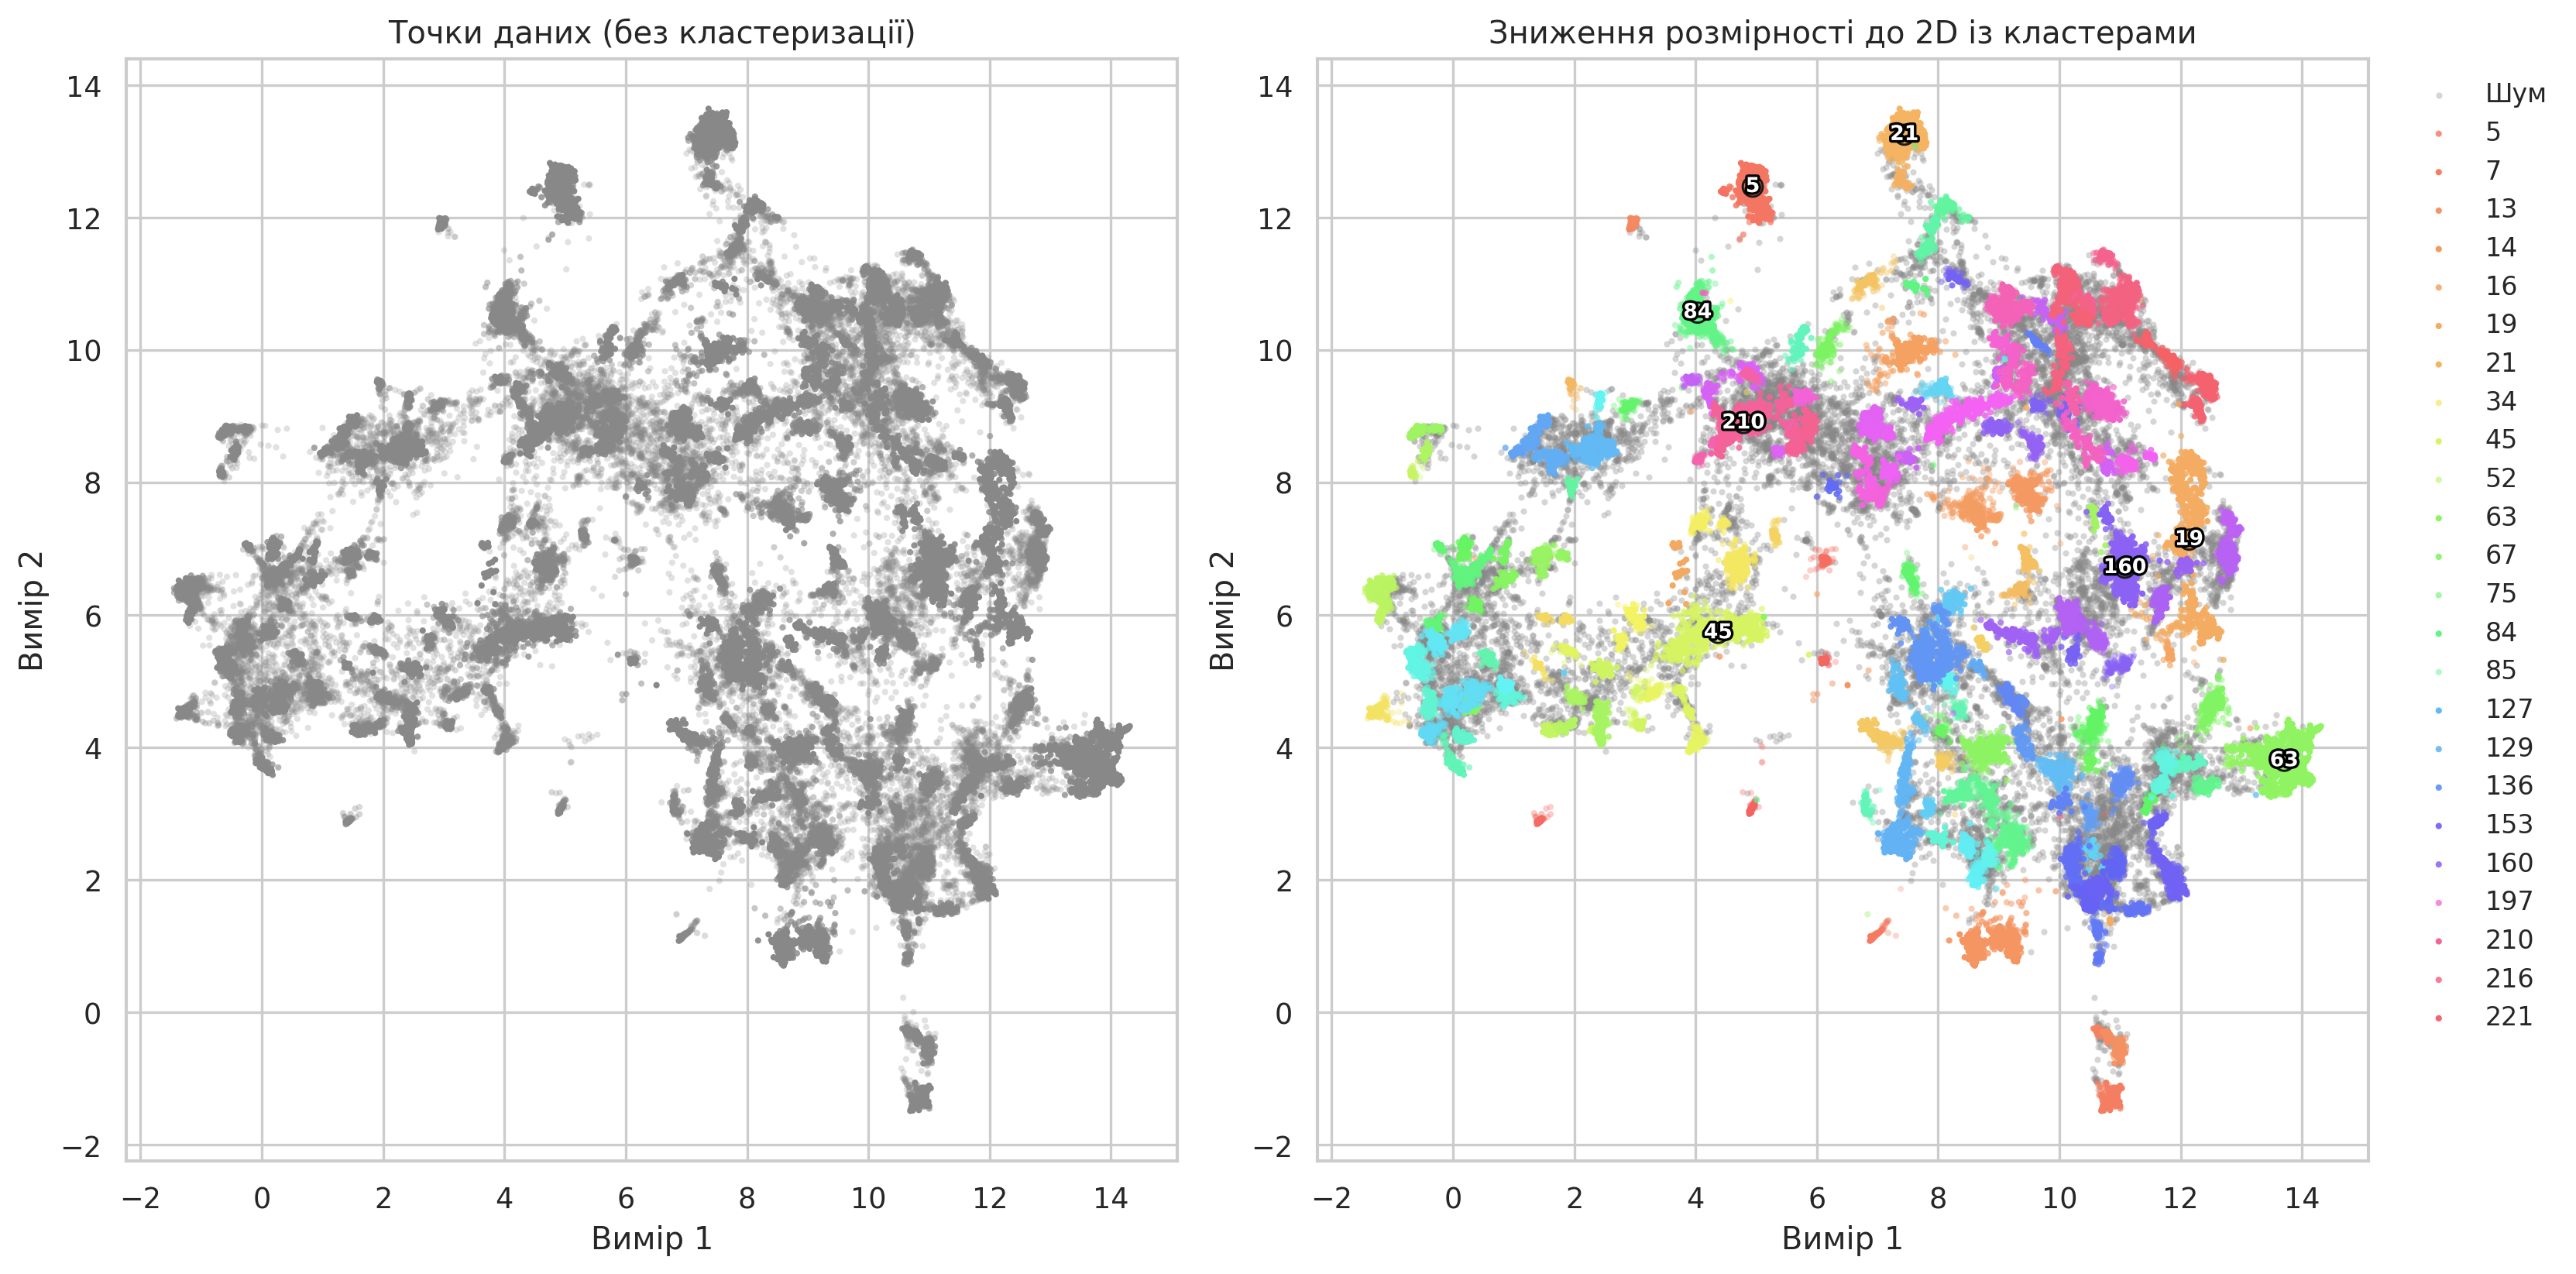

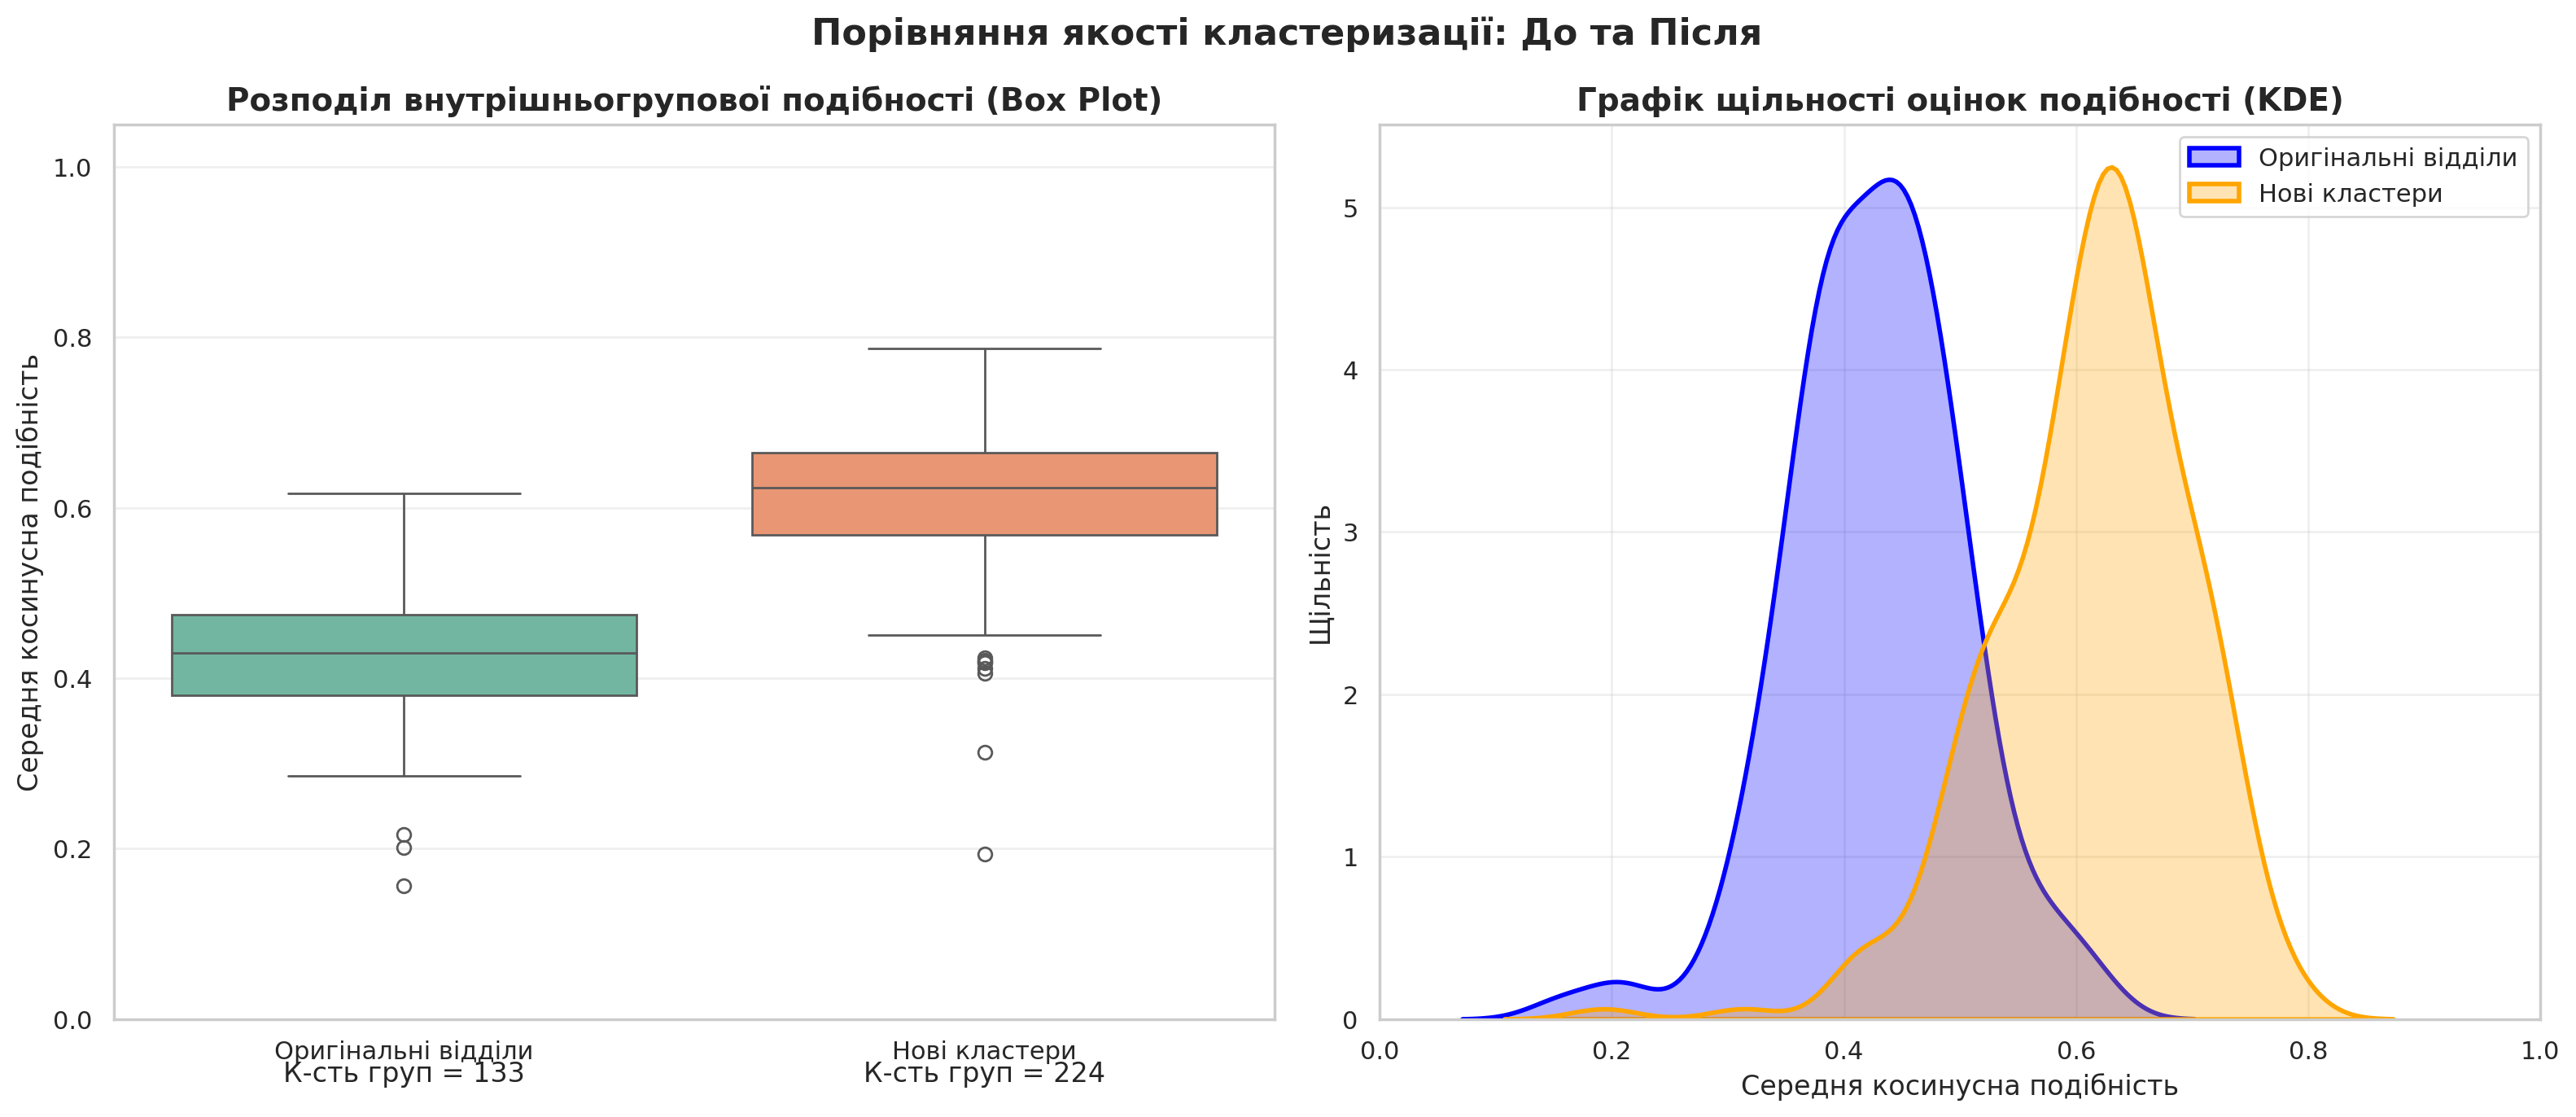

Total Time: 00:16:37


In [ ]:
UMAP_SETTINGS_1 = {
    "use_pca": True,
    "pca_dim": 50,
    "reducer_name": "umap",
    "reducer_dims": 5,
    "reducer_n_neighbors": 100,
    "reducer_min_dist": 0.1,
    "reducer_metric": "cosine",
    "hdb_min_cluster_size": 25,
    "do_plot": True
}

df_results_1, cluster_map_1, extras_1 = run_clustering(emb_cluster, UMAP_SETTINGS_1, name_to_emb=name_to_emb)

In [ ]:
print("BEFORE:")
similarity_in_clusters_1 = compute_cluster_similarities(df_results_1[df_results_1['cluster']!=-1][["proc_name", "cluster", "membership_score"]], name_to_emb=name_to_emb)

filtered_clusters_by_similarity_1 = filter_clusters_by_similarity(df_results_1, similarity_in_clusters_1, threshold_method='fixed', threshold_value=0.45)
print("AFTER:")
filtered_similarity_in_clusters_1 = compute_cluster_similarities(filtered_clusters_by_similarity_1[["proc_name", "cluster", "membership_score"]], name_to_emb=name_to_emb)

BEFORE:
Worst Cluster cohesion: 0.1920 ('non pareil capers')
Best Cluster cohesion:  0.7873 ('sweet and spicy caffeine free herbal tea bags')
AFTER:
Worst Cluster cohesion: 0.4503 ('absolute waterproof tape')
Best Cluster cohesion:  0.7873 ('sweet and spicy caffeine free herbal tea bags')


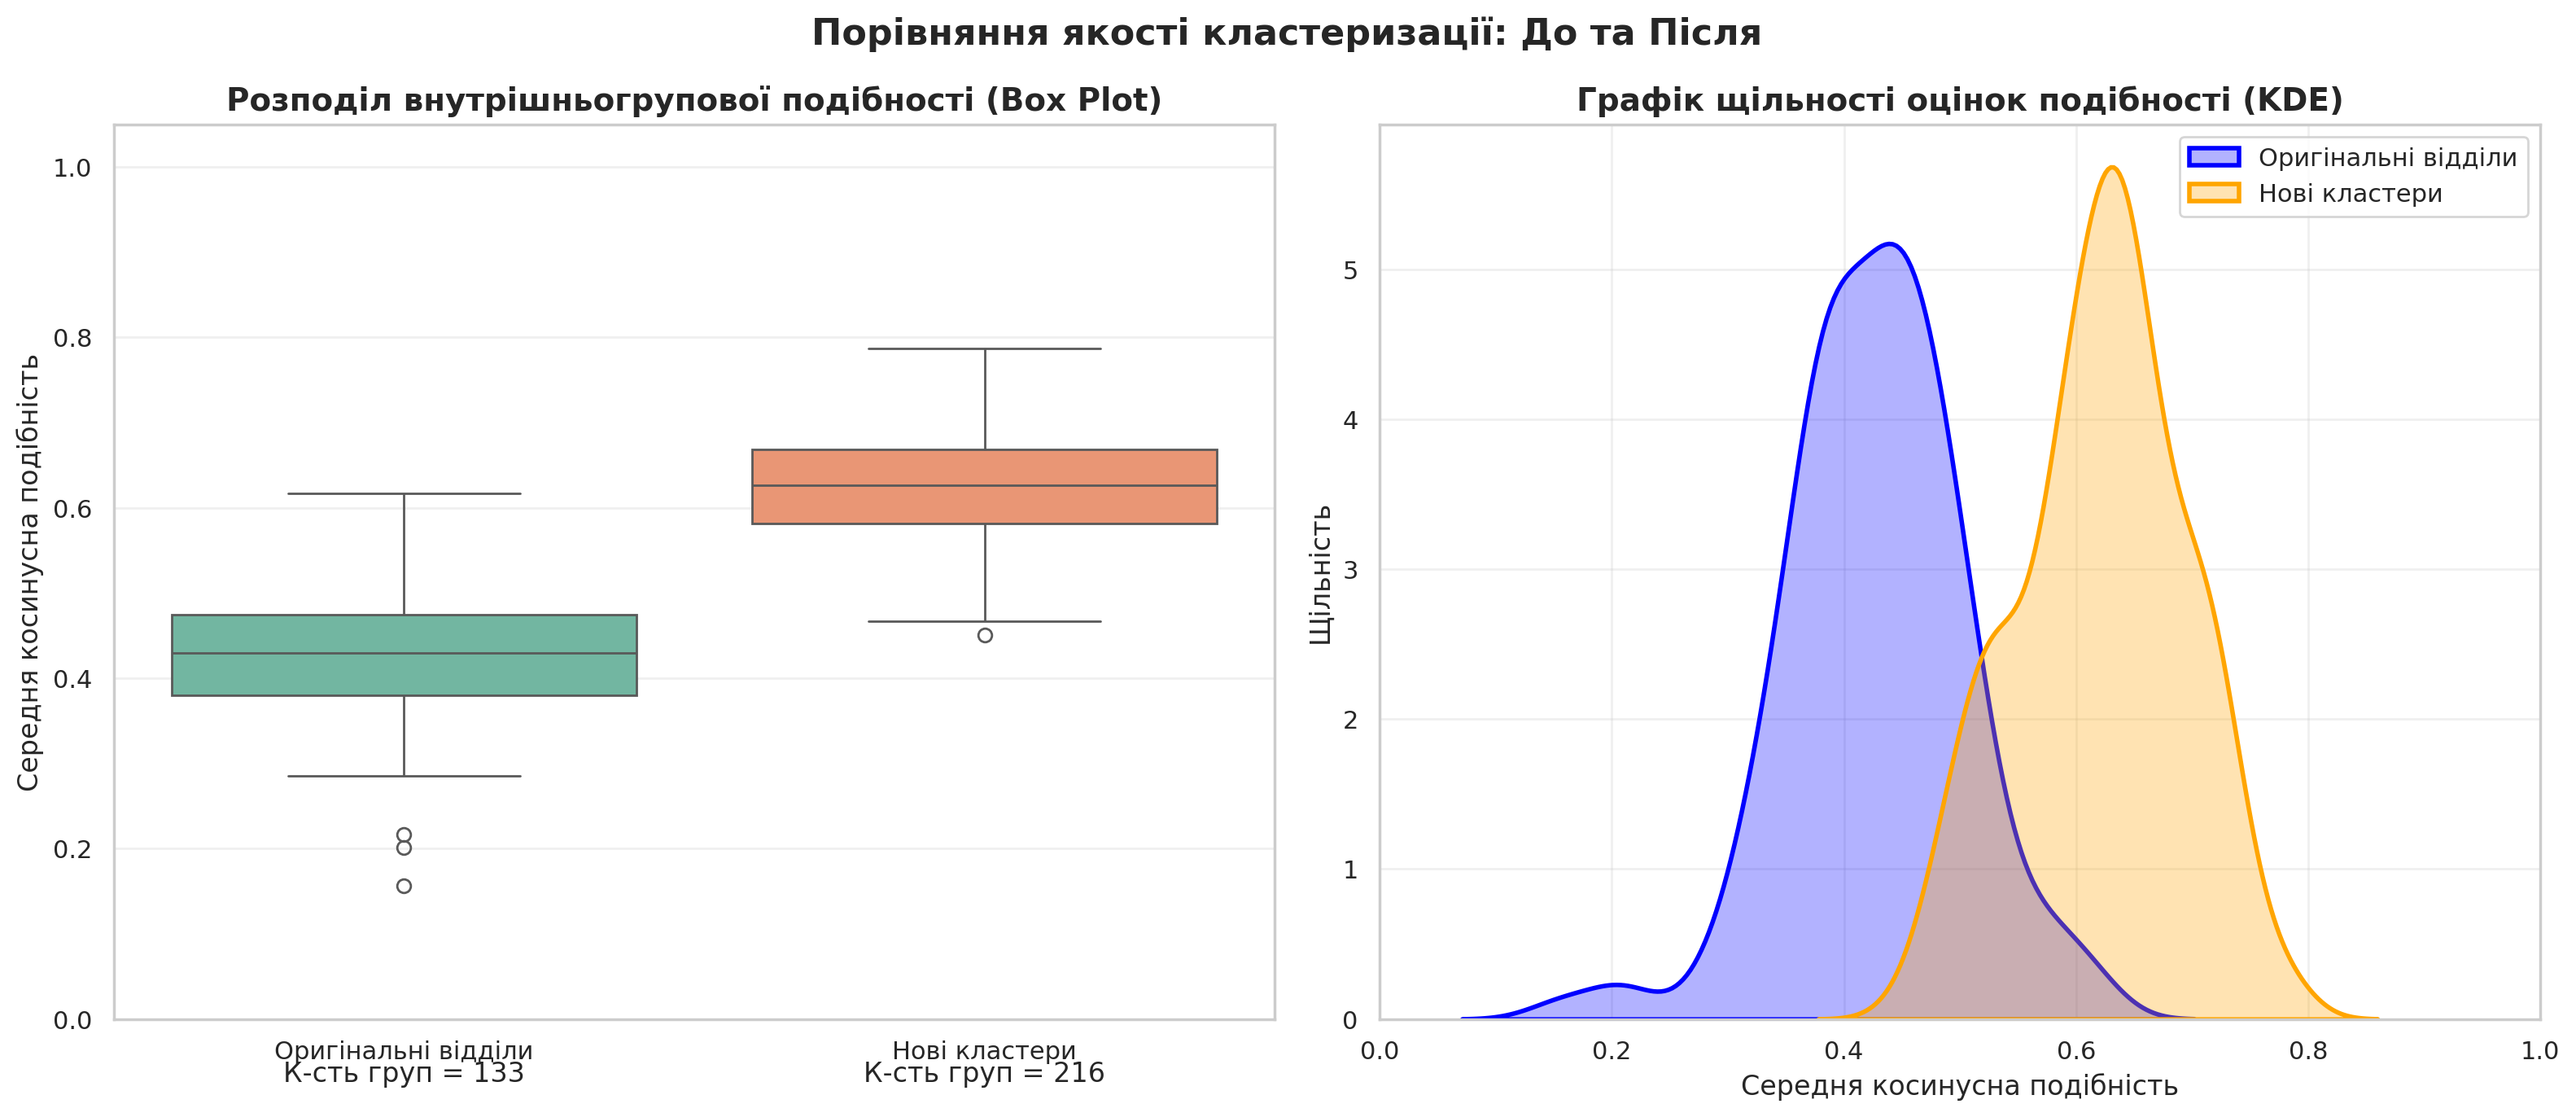

In [ ]:
plot_similarity_metrics_clusters(filtered_similarity_in_clusters_1)

Виводимо зміст кластерів

In [ ]:
top_clusters_table = cluster_representatives(
    cluster_df=df_results_1,
    top_k_clusters=5,
    top_n_items=20,
    max_name_length=45
)

display(top_clusters_table)

,Cluster 69,Cluster 215,Cluster 204,Cluster 206,Cluster 196
Rank,,,,,
1,Redness Relief Cooling Eye Drops,Raspberry Fig Bars,Original Sparkling Spring Water,Special K Fudge Mini Brownies,Toll House Ultimate Chocolate Peanut Butter D...
2,Optive Lubricant Eye Drops,Apple Pineapple Bar,Single & Sparkling Natural Mineral Water,Chocolate Chip Waffles,Peanut Butter Chocolate Chip Cookie Dough
3,Irritated Eye Relief Drops,1 Apple + 1 Pear Fruit Bar,Sparkling Spring Water,Chocolate Covered Biscuit Sticks,Walnut Chocolate Chip Cookie Dough
4,Visine Tears Dry Eye Relief Dry Eye,Pineapple & Passion Fruit Sandwich Fruit Bar,S. Pellegrino Sparkling Natural Mineral Water,153; Double Chocolate Brownie Bites 5.3 Oz,Ready to Bake Sugar Cookie Dough
5,Triple Action Relief Eye Drops,Raspberry Fruit Bars,Classic Carbonated Natural Mineral Water,Little Bites Fudge Brownies,Chocolate Chip Cookie Dough Bar
6,Eye Drops Advanced Relief,Apple + Blueberry Fruit Bar,Italian Sparkling Mineral Water,Little Bites Chocolate Chip Muffins,Ultimates Chocolate Chip Lovers Cookie Dough
7,"Lubricant /Redness Reliever Eye Drops, Maximu...",Apples & Mangoes Fruit Bars,Naturally Sparkling Mineral Water,Chocolate Belgian Waffles,Toll House Ultimates Dark Chocolate Delight C...
8,Stye Eye Relief Drops,Outshine Fruit Bars,Lemon Italian Sparkling Mineral Water,Special K Divine Fudge Brownies,Ultimates Turtle Cookie Dough
9,Advanced Redness + Irritation Relief Eye Drop...,Mixed Berry Strawberry Kiwi Black Cherry Frui...,Pure Sparkling Water,Chocolate Chip Little Muffins,Kitchens Chocolate Chip Spoonable Cookie Doug...


Виводимо ID кластеру конкретного товару або групи товарів

In [ ]:
# Один товар
print(get_product_clusters("Organic Creamy Peanut Butter", df_results_1))

# Група товарів
product_list_for_cluster_ids = ["Organic Creamy Peanut Butter", "Natural Honey Creamy Peanut Butter", "Mild Taco Seasoning Mix"]
print(get_product_clusters(product_list_for_cluster_ids, df_results_1))

{'Organic Creamy Peanut Butter': 14}
{'Natural Honey Creamy Peanut Butter': 14, 'Organic Creamy Peanut Butter': 14, 'Mild Taco Seasoning Mix': 87}


# Notes

Visualizing association rules in hierarchical groups:

https://link.springer.com/article/10.1007/s11573-016-0822-8

Як працює модель векторизації (embeding model)

Схема:

Вхідне речення / Слово -> Підслівна токенізація (Послідовність векторів однакових слів з різними значеннями мають ОДНАКОВІ вектори ~ Кожен токен - окремий вектор) -> Self-attention layer -> (Послідовність векторів однакових слів з різними значеннями мають РІЗНІ вектори - вловили контекст за сусідніми словами) -> Pooling (різні методи) - перетворення послідовності векторів (один токен - один вектор) у єдиний вектор

# Дослідження IPF

$$IPF(p) = \log \left( \frac{N}{|T_p|} \right)$$

Де:
- $N$ — загальна кількість чеків (транзакцій) у наборі даних.
- $|T_p|$ — кількість чеків, у яких зустрічається товар $p$.

$$support(p) = \frac{|T_p|}{N}$$

$$IPF(p) = \log \left( \frac{N}{|T_p|} \right) = \log \left( \frac{1}{support(p)} \right) = -\log(support(p))$$

Теорія інформації:

Формула особистої інформації (self-information formula) - вимірює кількість інформації, що міститься в настанні конкретної події x:

$$I(x) = -\log_b P(x) = \log_b \frac{1}{P(x)}$$

Враховуємо, що $support(p)$ - подія купівлі товару $p$ (ймовірність потрапляння товару p у транзакційний чек), тому $IPF(p)$ можемо звести до **Інформативності товару**.

----

Чим менш ймовірна подія - тим більше вона несе інформації (за Шенноном)

----

Також це буде працювати з $support(r)$, де $r$ - правило. Тобто в такому разі будемо мати **Інформативність правила**.

Відповідно, обидві оцінки з застосуванням інформативності (товару і правила) будуть корелювати. Якщо товари $A$ і $B$ рідкісні (високий IPF), то і їхня спільна купівля $A \cap B$ гарантовано буде рідкісною.

Але також можливий випадок, коли правило просто є рідкісним, навіть при наявності частого товару. Тому, оцінка повинна враховувати саме інформативність окремих товарів задля усунення шуму. Яскравим прикладом є правила, де правило є рідкісне, але принаймні один товар є дуже частим.



Візьмемо правила, де маємо дуже популярний товар "Organic Strawberries". У такому разі оцінка з урахуванням інформативності кожного ОКРЕМОГО ТОВАРУ розміщує правила на 66 та 78 місцях, при цьому самі оцінки дорівнюють 3.0061 та 2.8635 відповідно. Вже на цьому прикладі, видно, що оцінка з урахуванням інформативності ВЬСОГО ПРАВИЛА завищує ці правила порівнянно з іншими.

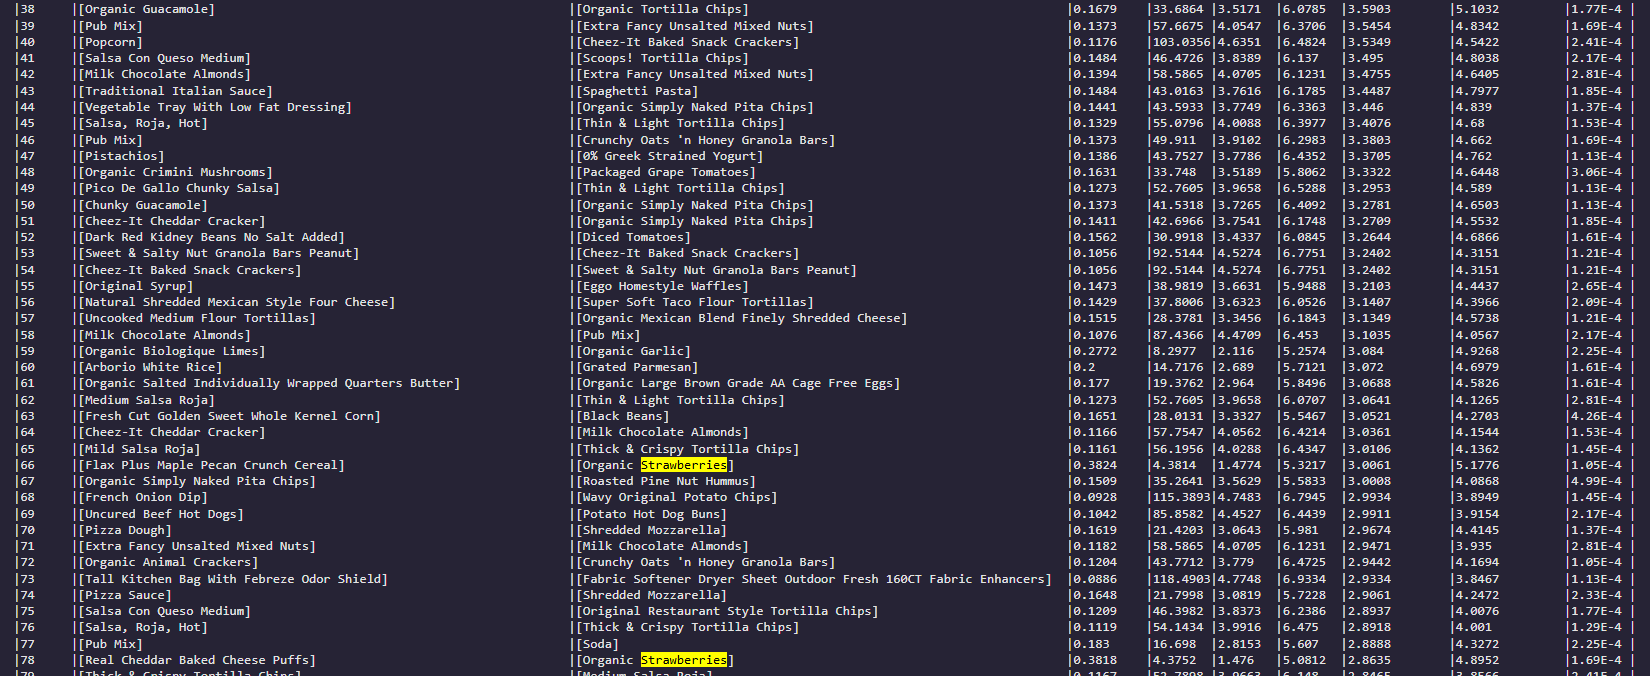

Тепер візьмемо правила, відфільтровані за оцінкою, що бере до уваги інформативність ВСЬОГО ПРАВИЛА. Бачимо, що раніше наведені правила з частим товаром "Organic Strawberries" займають 34 та 38 місця, а їх оцінки дорівнюють 5.1776 та 4.8952 відповідно.

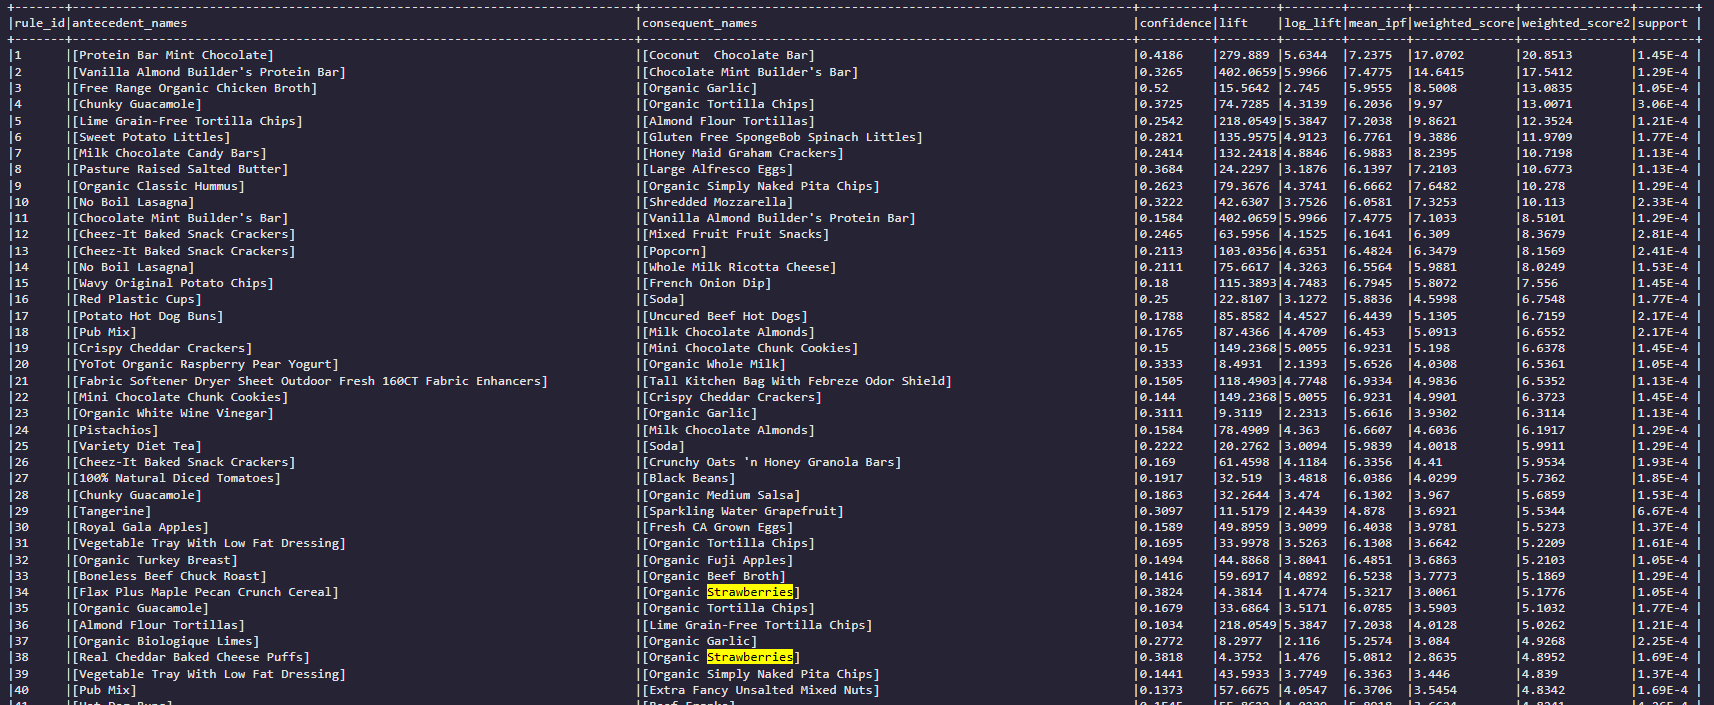

Ці та подібні правила дають достатньо підстав для того, що використання інформативності ЦІЛОГО ПРАВИЛА в метриці може піднімати вгору ті правила, що ми потенційно хочемо опустити, тобто вводять шум.

Аналогія до IDF (IDF та Теорія інформації):

https://www.researchgate.net/publication/238123710_Understanding_Inverse_Document_Frequency_On_Theoretical_Arguments_for_IDF

# Rules filtering and weighted scoring

current function: $MinMax(ipf_{min}) * MinMax(ln(lift)) * confidence$

In [ ]:
def make_rules_advanced(
    frequent_items_path,
    n_rules=20,
    minConfidence=0.4,
    minLift=1.2,
    filter="lift",
    decimals=4,
    show=False,
    filter_mode=None,
    pandas_df=None,
    membership_threshold=0.0,
    non_cluster=False,
    mode=None,
    department_mode=False,
    multy=True,
    conf_w=1,
    lift_w=1,
    ipf_w=1
):

    freq_itemsets = []
    pattern = re.compile(r'^\s*([\d]+(?:\s+[\d]+)*)\s+#SUP\s*:\s*([0-9]+)\s*$', flags=re.IGNORECASE)
    with open(frequent_items_path, 'r', encoding='utf-8') as f:
        for line in f:
            s = line.strip()
            if not s:
                continue
            m = pattern.match(s)
            if m:
                items = tuple(sorted(int(x) for x in re.split(r'\s+', m.group(1).strip()) if x != ''))
                support_count = int(m.group(2))
                freq_itemsets.append((items, support_count))

    freq_dict = {tuple(sorted(items)): sup for items, sup in freq_itemsets}

    def fmt_num(x, key=None):
        if isinstance(x, float):
            if math.isfinite(x):
                if key in ("support", "leverage"):
                    return f"{x:.6f}"
                else:
                    return round(x, decimals)
            else:
                return x
        return x

    # ---- IPF ----
    df_counts = defaultdict(int)

    N = 0
    with open("transactions.txt", "r", encoding="utf-8") as f:
        for ln in f:
            ln = ln.strip()
            if not ln:
                continue
            N += 1
            try:
                ids = [int(x) for x in ln.split() if x.strip()!='']
            except Exception:
                continue
            unique_ids = set(ids)
            for iid in unique_ids:
                df_counts[iid] += 1

    ipf_map = {}
    for iid, cnt in df_counts.items():
        if cnt > 0:
            ipf_map[iid] = math.log(N / cnt) if (N > 0 and cnt > 0) else 0.0
        else:
            ipf_map[iid] = 0.0
    # ---- IPF ----

    product_cluster_map = None
    if mode in ("cluster", "both"):
        if pandas_df is None:
            raise ValueError("mode 'cluster' requires passing pandas_df with columns ['product_name','cluster','membership_score']")
        prod_df = products.select("product_id", "product_name").toPandas()
        pd_src = pandas_df.copy()
        if "product_name" not in pd_src.columns:
            raise ValueError("pandas_df must contain 'product_name' column")
        if "membership_score" not in pd_src.columns:
            pd_src["membership_score"] = 0.0
        if "cluster" not in pd_src.columns:
            pd_src["cluster"] = -1
        merged = prod_df.merge(pd_src[["product_name", "cluster", "membership_score"]],
                               on="product_name", how="left")
        merged["membership_score"] = merged["membership_score"].fillna(0.0).astype(float)
        valid_mask = (~merged["cluster"].isna()) & ((merged["cluster"] != -1) | (non_cluster is True))
        product_cluster_map = dict(zip(
            merged.loc[valid_mask, "product_id"],
            zip(merged.loc[valid_mask, "cluster"].astype(int), merged.loc[valid_mask, "membership_score"])
        ))

    product_aisle_map = None
    if mode in ("aisle", "both"):
        prod_df = products.select("product_id", "product_name", "aisle_id").toPandas()
        prod_df["aisle_id"] = prod_df["aisle_id"].astype(str)
        try:
            aisles_pd = aisles.select("aisle_id", "aisle").toPandas()
            aisles_pd["aisle_id"] = aisles_pd["aisle_id"].astype(str)
            merged = prod_df.merge(aisles_pd, on="aisle_id", how="left")
            merged["aisle_identifier"] = merged["aisle"].fillna(merged["aisle_id"]).astype(str)
        except Exception:
            merged = prod_df.copy()
            merged["aisle_identifier"] = merged["aisle_id"].astype(str)

        merged["aisle_identifier"] = merged["aisle_identifier"].fillna("-999").astype(str)
        product_aisle_map = dict(zip(merged["product_id"], merged["aisle_identifier"]))

    product_department_map = None
    if department_mode:
        prod_df = products.select("product_id", "product_name", "department_id").toPandas()
        prod_df["department_id"] = prod_df["department_id"].astype(str)
        merged = prod_df.copy()
        merged["department_identifier"] = merged["department_id"].fillna("-999").astype(str)
        product_department_map = dict(zip(merged["product_id"], merged["department_identifier"]))

    rules = []
    candidates = []

    if multy:
        for items, sup_xy in freq_itemsets:
            if len(items) < 2:
                continue
            items = tuple(sorted(items))
            for i in range(1, len(items)):
                for X in itertools.combinations(items, i):
                    Y = tuple(sorted(set(items) - set(X)))
                    sup_x = freq_dict.get(tuple(sorted(X)))
                    sup_y = freq_dict.get(tuple(sorted(Y)))
                    if sup_x and sup_y and sup_x > 0 and sup_y > 0:
                        candidates.append((tuple(sorted(X)), tuple(sorted(Y)), sup_xy, sup_x, sup_y))
    else:
        pair_keys = [k for k in freq_dict.keys() if len(k) == 2]
        for pair in pair_keys:
            pair_sorted = tuple(sorted(pair))
            sup_xy = freq_dict.get(pair_sorted)
            a, b = pair_sorted
            sup_a = freq_dict.get((a,))
            sup_b = freq_dict.get((b,))
            if sup_xy and sup_a and sup_b and sup_a > 0 and sup_b > 0:
                candidates.append(((a,), (b,), sup_xy, sup_a, sup_b))
                candidates.append(((b,), (a,), sup_xy, sup_b, sup_a))

    for X, Y, sup_xy, sup_x, sup_y in candidates:
        P_xy = sup_xy / N
        P_x = sup_x / N
        P_y = sup_y / N

        support = P_xy
        confidence = (P_xy / P_x) if P_x > 0 else 0.0
        lift = (confidence / P_y) if P_y > 0 else float('inf')

        leverage = P_xy - P_x * P_y
        added_value = confidence - P_y

        denom_jacc = (P_x + P_y - P_xy)
        jaccard = (P_xy / denom_jacc) if denom_jacc > 0 else 0.0

        cosine = (P_xy / math.sqrt(P_x * P_y)) if (P_x > 0 and P_y > 0) else 0.0

        px_given_y = (P_xy / P_y) if P_y > 0 else 0.0
        kulczynski = 0.5 * (confidence + px_given_y)

        if (1.0 - confidence) == 0:
            conviction = float('inf')
        else:
            conviction = ((1.0 - P_y) / (1.0 - confidence)) if (1.0 - confidence) > 0 else float('inf')

        a = sup_xy
        b = sup_x - sup_xy
        c = sup_y - sup_xy
        d = N - sup_x - sup_y + sup_xy

        e11 = sup_x * sup_y / N
        e12 = sup_x * (N - sup_y) / N
        e21 = (N - sup_x) * sup_y / N
        e22 = (N - sup_x) * (N - sup_y) / N

        chi2 = 0.0
        for obs, exp in [(a, e11), (b, e12), (c, e21), (d, e22)]:
            if exp > 0:
                chi2 += (obs - exp) ** 2 / exp

        all_item_ids = list(X) + list(Y)

        if mode in ("cluster", "both") and product_cluster_map is not None:
            clusters = set()
            fail_membership = False
            for pid in all_item_ids:
                info = product_cluster_map.get(pid)
                if info is None:
                    fail_membership = True
                    break
                cluster_val, mem_score = info
                if membership_threshold > 0 and (mem_score is None or mem_score < membership_threshold):
                    fail_membership = True
                    break
                clusters.add(cluster_val)
            if fail_membership:
                continue
            if len(clusters) <= 1:
                continue

        if mode in ("aisle", "both") and product_aisle_map is not None:
            aisles_set = set()
            for pid in all_item_ids:
                aisle_ident = product_aisle_map.get(pid, "-999")
                aisles_set.add(str(aisle_ident))
            if len(aisles_set) <= 1:
                continue

        if department_mode and product_department_map is not None:
            depts_set = set()
            for pid in all_item_ids:
                dept_ident = product_department_map.get(pid, "-999")
                depts_set.add(str(dept_ident))
            if len(depts_set) <= 1:
                continue

        # ---- New Metric ----
        # Середнє арифметичне
        '''
        ipf_values = [ipf_map.get(int(pid), 0.0) for pid in all_item_ids]
        rule_ipf = sum(ipf_values) / len(ipf_values) if len(ipf_values) > 0 else 0.0
        '''
        # Мінімум - The Weakest Link

        ipf_values = [ipf_map.get(int(pid), 0.0) for pid in all_item_ids]
        rule_ipf = min(ipf_values) if len(ipf_values) > 0 else 0.0

        # Гармонійне середнє
        '''
        ipf_values = [ipf_map.get(int(pid), 0.0) for pid in all_item_ids]
        if len(ipf_values) > 0 and all(v > 0 for v in ipf_values):
            rule_ipf = len(ipf_values) / sum(1.0 / v for v in ipf_values)
        else:
            rule_ipf = 0.0
        '''
        # ---- New Metric ----
        log_lift = math.log(lift) if lift > 1 else 0.001

        # ---- New Metric 2----
        weighted_score2 = log_lift*confidence*math.log(float(1/support))
        # ---- New Metric 2----

        rules.append(Row(
            antecedent=list(X),
            consequent=list(Y),
            sup_xy=int(sup_xy),
            sup_x=int(sup_x),
            sup_y=int(sup_y),
            support=fmt_num(float(support), "support"),
            confidence=fmt_num(float(confidence), "confidence"),
            log_lift=fmt_num(float(log_lift)),
            lift=fmt_num(float(lift), "lift"),
            weighted_score2=fmt_num(float(weighted_score2)),
            rule_ipf=fmt_num(float(rule_ipf)),
            leverage=fmt_num(float(leverage), "leverage"),
            added_value=fmt_num(float(added_value), "added_value"),
            jaccard=fmt_num(float(jaccard), None),
            cosine=fmt_num(float(cosine), None),
            kulczynski=fmt_num(float(kulczynski), None),
            conviction=fmt_num(float(conviction), None),
            chi2=fmt_num(float(chi2), None)
        ))

    rules_df = spark.createDataFrame(rules).filter((F.col("lift") > minLift) & (F.col("confidence") > minConfidence))

    bounds = rules_df.select(
        F.min("log_lift").alias("min_log_lift"),
        F.max("log_lift").alias("max_log_lift"),
        F.min("rule_ipf").alias("min_ipf"),
        F.max("rule_ipf").alias("max_ipf")
    ).first()

    min_log_lift, max_log_lift = bounds["min_log_lift"], bounds["max_log_lift"]
    min_ipf, max_ipf = bounds["min_ipf"], bounds["max_ipf"]

    denom_log_lift = (max_log_lift - min_log_lift) if (max_log_lift - min_log_lift) > 0 else 1.0
    denom_ipf = (max_ipf - min_ipf) if (max_ipf - min_ipf) > 0 else 1.0

    rules_df = rules_df.withColumn(
        "norm_log_lift", (F.col("log_lift") - F.lit(min_log_lift)) / F.lit(denom_log_lift)
    ).withColumn(
        "norm_ipf", (F.col("rule_ipf") - F.lit(min_ipf)) / F.lit(denom_ipf)
    ).withColumn(
        "weighted_score",
        F.pow(F.col("norm_log_lift"), lift_w) * F.pow(F.col("norm_ipf"), ipf_w) * F.pow(F.col("confidence"), conf_w)
    ).withColumn(
        "weighted_score", F.round(F.col("weighted_score"), 4)
    ).withColumn(
        "norm_log_lift", F.round(F.col("norm_log_lift"), 4)
    ).withColumn(
        "norm_ipf", F.round(F.col("norm_ipf"), 4)
    )

    antecedent_df = (
        rules_df
        .withColumn("antecedent_id", F.explode("antecedent"))
        .join(products.select("product_id", "product_name"),
              F.col("antecedent_id") == F.col("product_id"),
              "left")
        .groupBy("antecedent", "consequent",
                 "sup_xy", "sup_x", "sup_y",
                 "support", "confidence", "norm_log_lift", "lift", "log_lift", "weighted_score", "weighted_score2", "norm_ipf", "rule_ipf",
                 "leverage", "added_value", "jaccard", "cosine",
                 "kulczynski", "conviction", "chi2")
        .agg(F.collect_list("product_name").alias("antecedent_names"))
    )

    rules_with_names = (
        antecedent_df
        .withColumn("consequent_id", F.explode("consequent"))
        .join(products.select("product_id", "product_name"),
              F.col("consequent_id") == F.col("product_id"),
              "left")
        .groupBy("antecedent", "consequent",
                 "sup_xy", "sup_x", "sup_y",
                 "support", "confidence", "norm_log_lift", "lift", "log_lift", "weighted_score", "weighted_score2", "norm_ipf", "rule_ipf",
                 "leverage", "added_value", "jaccard", "cosine",
                 "kulczynski", "conviction", "chi2",
                 "antecedent_names")
        .agg(F.collect_list("product_name").alias("consequent_names"))
    )

    out_cols = ["antecedent_names", "consequent_names", "confidence", "lift", "log_lift","norm_log_lift", "rule_ipf", "norm_ipf", "weighted_score", "weighted_score2", "support"]

    if filter not in out_cols:
        filter = "lift"

    print(f"Base Rules:")
    print(f"Number of rules: { rules_with_names.select(*out_cols).count()}")
    if show:
      rules_with_names.select(*out_cols).orderBy(F.col(filter).desc()).show(n_rules, truncate=False)

    output_excel = "association_rules.xlsx"

    spark.conf.set(key, "false")
    try:
        rules_pd = (
            rules_with_names
            .select(*out_cols)
            .orderBy(F.col(filter).desc())
            .toPandas()
        )

        rules_pd.to_excel(output_excel, index=False, engine="openpyxl")
        print(f" - Base rules saved to {output_excel}")

        window_spec = Window.orderBy(F.col(filter).desc())
        final_out_cols = ["rule_id"] + out_cols

        if filter_mode:
            print(f"Filtered Rules")
            filtered = apply_filters_and_export(rules_with_names.select(*out_cols), mode = filter_mode, filter_order_col = filter)
            filtered = filtered.withColumn("rule_id", F.row_number().over(window_spec)).select(*final_out_cols)
            print(f"Number of filtered rules: {filtered.count()}")
            filtered.show(n_rules, truncate=False)
        else:
            rules_with_names = rules_with_names.withColumn("rule_id", F.row_number().over(window_spec))
    finally:
        if prev is None:
            spark.conf.set(key, "true")
        else:
            spark.conf.set(key, prev)

    if filter_mode:
        return filtered
    else:
        return rules_with_names.select(*final_out_cols).orderBy(F.col(filter).desc())

In [ ]:
def display_rules(rules_df, n_rows=20, max_name_len=45, interval=None):

    fetch_rows = n_rows
    if interval is not None:
        fetch_rows = interval[1]

    if type(rules_df).__name__ == 'DataFrame':
        df = rules_df.limit(fetch_rows).toPandas()
    else:
        df = rules_df.head(fetch_rows).copy()

    def format_names(items):
        if isinstance(items, str) and items.startswith('[') and items.endswith(']'):
            items = items.strip('[]').replace("'", "").replace('"', '')

        if isinstance(items, (list, tuple, np.ndarray)):
            text = ", ".join(str(x) for x in items)
        else:
            text = str(items)

        if len(text) > max_name_len:
            return text[:max_name_len - 3] + "..."
        return text

    if 'antecedent_names' in df.columns:
        df['antecedent_names'] = df['antecedent_names'].apply(format_names)
    if 'consequent_names' in df.columns:
        df['consequent_names'] = df['consequent_names'].apply(format_names)

    rename_dict = {
        'rule_id': 'ID',
        'antecedent_names': 'Antecedent',
        'consequent_names': 'Consequent',
        'confidence': 'Conf.',
        'lift': 'Lift',
        'rule_ipf': 'IPF',
        'support': 'Supp.',
        'norm_log_lift': 'NLift',
        'norm_ipf': 'NIPF',
        'weighted_score': 'W-Score'
    }
    df = df.rename(columns=rename_dict)

    if interval is not None:
        start_id, end_id = interval
        if 'ID' in df.columns:
            df = df[(df['ID'] >= start_id) & (df['ID'] <= end_id)]
        else:
            df = df.iloc[start_id - 1 : end_id]

    # cols_to_show = [c for c in ['ID', 'Antecedent', 'Consequent', 'Conf.', 'Lift', 'NLift', 'IPF', 'NIPF', 'W-Score', 'Supp.'] if c in df.columns]
    cols_to_show = [c for c in ['Antecedent', 'Consequent', 'Conf.', 'NLift', 'NIPF', 'W-Score', 'Supp.'] if c in df.columns]
    df = df[cols_to_show]

    styled_df = df.style \
        .set_properties(subset=['Antecedent', 'Consequent'], **{'text-align': 'left'}) \
        .set_properties(subset=[c for c in cols_to_show if c not in ['Antecedent', 'Consequent']], **{'text-align': 'right'}) \
        .set_table_styles([dict(selector='th', props=[('text-align', 'center')])]) \
        .hide(axis="index") \
        .format(precision=4) \
        .format(subset=['Supp.'], precision=6)

    display(styled_df)

In [ ]:
p2p_rules = make_rules_advanced("charm_output.txt", n_rules=500, minConfidence=0.0, minLift=0.0, show=False, filter="weighted_score", filter_mode='absolute', pandas_df=filtered_clusters_by_similarity_1, mode='both', multy=False, lift_w=1, ipf_w=1, conf_w=1)

Base Rules:
Number of rules: 37590
 - Base rules saved to association_rules.xlsx
Filtered Rules
 - Filtered rules saved to association_rules_filtered.xlsx
Number of filtered rules: 33824
+-------+--------------------------------------------------------------------+--------------------------------------------------------------------+----------+--------+--------+-------------+--------+--------+--------------+---------------+--------+
|rule_id|antecedent_names                                                    |consequent_names                                                    |confidence|lift    |log_lift|norm_log_lift|rule_ipf|norm_ipf|weighted_score|weighted_score2|support |
+-------+--------------------------------------------------------------------+--------------------------------------------------------------------+----------+--------+--------+-------------+--------+--------+--------------+---------------+--------+
|1      |[Protein Bar Mint Chocolate]                             

In [ ]:
display_rules(p2p_rules, n_rows=50, max_name_len=45, interval=None)

ID,Antecedent,Consequent,Conf.,Lift,NLift,IPF,NIPF,W-Score,Supp.
1,Protein Bar Mint Chocolate,Coconut Chocolate Bar,0.4186,279.8890,0.9396,6.5052,0.8694,0.3420,0.000145
2,Vanilla Almond Builder's Protein Bar,Chocolate Mint Builder's Bar,0.3265,402.0659,1.0000,7.1158,1.0000,0.3265,0.000129
3,Lime Grain-Free Tortilla Chips,Almond Flour Tortillas,0.2542,218.0549,0.8980,6.7542,0.9227,0.2106,0.000121
4,Sweet Potato Littles,Gluten Free SpongeBob Spinach Littles,0.2821,135.9575,0.8192,6.1780,0.7995,0.1848,0.000177
5,Chunky Guacamole,Organic Tortilla Chips,0.3725,74.7285,0.7194,5.3012,0.6120,0.1640,0.000306
6,Milk Chocolate Candy Bars,Honey Maid Graham Crackers,0.2414,132.2418,0.8146,6.3060,0.8269,0.1626,0.000113
7,Chocolate Mint Builder's Bar,Vanilla Almond Builder's Protein Bar,0.1584,402.0659,1.0000,7.1158,1.0000,0.1584,0.000129
8,Organic Classic Hummus,Organic Simply Naked Pita Chips,0.2623,79.3676,0.7294,5.7124,0.6999,0.1339,0.000129
9,French Onion Dip,Original Potato Chips,0.2062,107.2890,0.7797,6.2545,0.8158,0.1312,0.000322
10,Cheez-It Baked Snack Crackers,Popcorn,0.2113,103.0356,0.7730,6.1897,0.8020,0.1310,0.000241


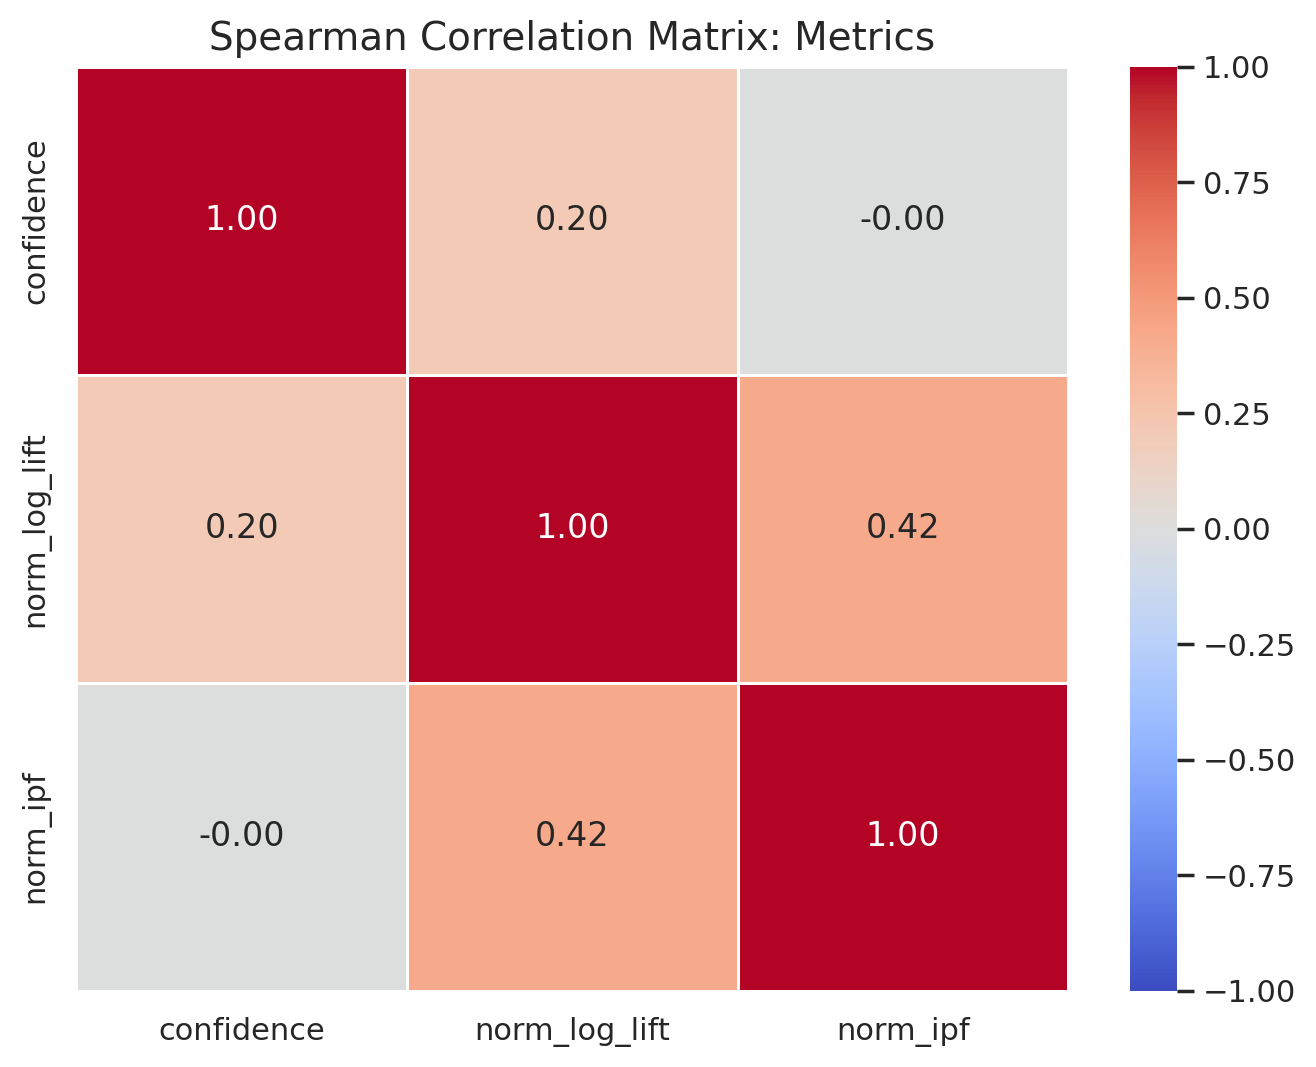

In [ ]:
df_corr = p2p_rules.select("confidence", "norm_log_lift", "norm_ipf").toPandas()
corr_matrix = df_corr.corr(method='spearman')
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            vmin=-1, vmax=1,
            fmt=".2f",
            linewidths=.5)

plt.title("Spearman Correlation Matrix: Metrics", fontsize=14)
plt.show()

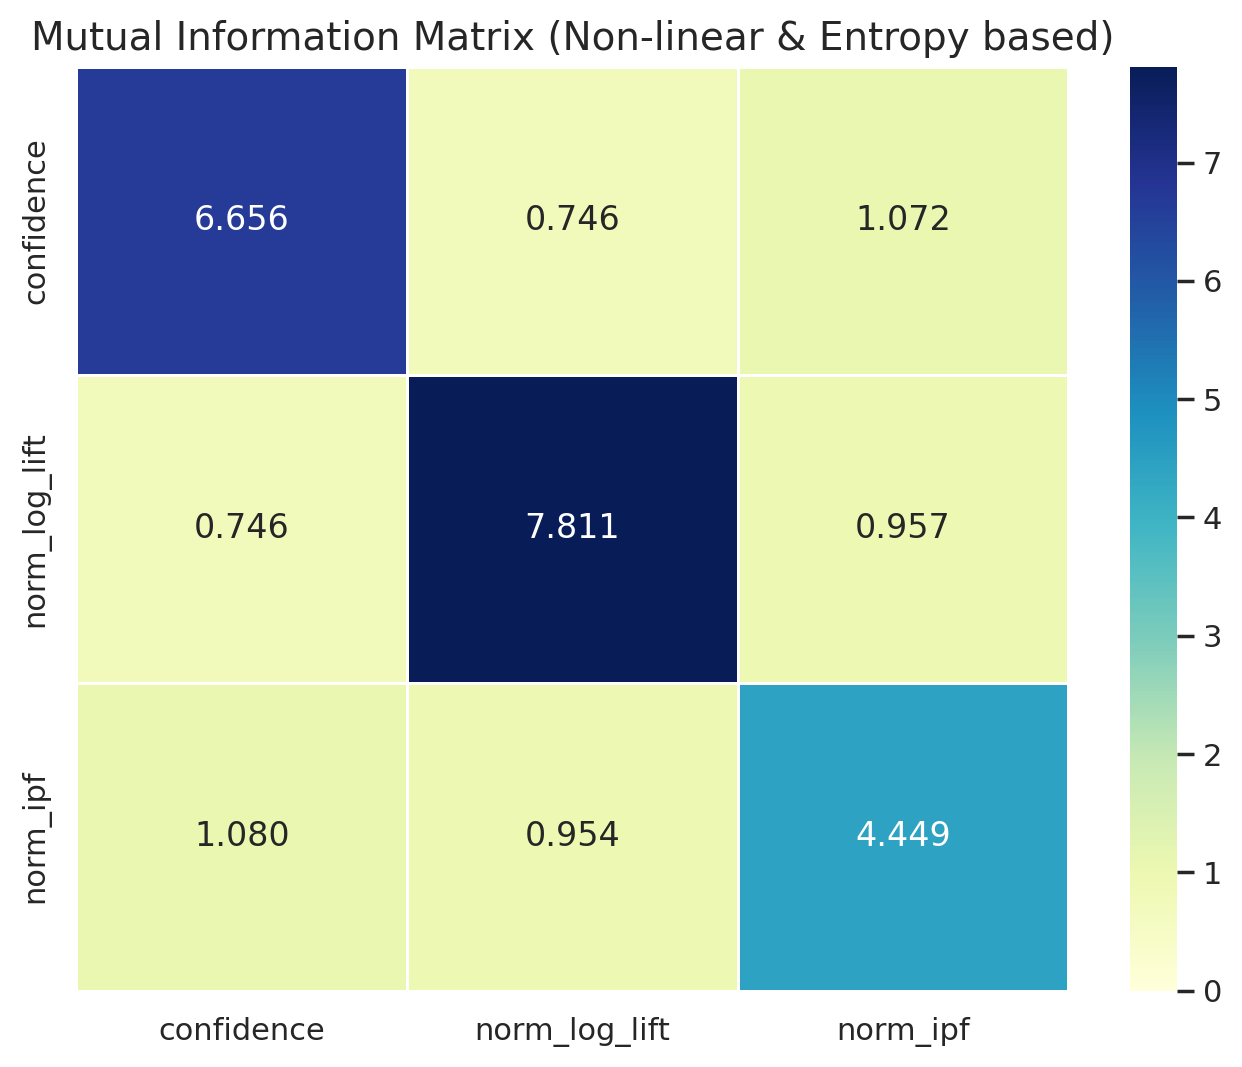

In [ ]:
from sklearn.feature_selection import mutual_info_regression

columns = ["confidence", "norm_log_lift", "norm_ipf"]

mi_matrix = pd.DataFrame(index=columns, columns=columns, dtype=float)

for col_y in columns:
    X = df_corr[columns].values
    y = df_corr[col_y].values

    mi_scores = mutual_info_regression(X, y, random_state=42)
    mi_matrix.loc[col_y] = mi_scores

plt.figure(figsize=(8, 6))

sns.heatmap(mi_matrix,
            annot=True,
            cmap='YlGnBu',
            vmin=0,
            fmt=".3f",
            linewidths=.5)

plt.title("Mutual Information Matrix (Non-linear & Entropy based)", fontsize=14)
plt.show()

Тут починаємо досліджувати кореляцію

In [ ]:
def analyze_ipf_impact(rules_df):

    df_analysis = rules_df.withColumn(
        "ipf_lift_delta",
        F.round(F.col("norm_ipf") - F.col("norm_log_lift"), 4)
    )

    window_lift = Window.orderBy(F.col("norm_log_lift").desc())
    window_score = Window.orderBy(F.col("weighted_score").desc())

    df_analysis = (
        df_analysis
        .withColumn("rank_lift", F.row_number().over(window_lift))
        .withColumn("rank_score", F.row_number().over(window_score))
        .withColumn("rank_improvement", F.col("rank_lift") - F.col("rank_score"))
    )

    return df_analysis

In [ ]:
analysis_df = p2p_rules.withColumn(
    "ipf_lift_delta",
    F.round(F.col("norm_ipf") - F.col("norm_log_lift"), 4)
)

def format_names_inline(items, max_name_len=45):
    if isinstance(items, str) and items.startswith('[') and items.endswith(']'):
        items = items.strip('[]').replace("'", "").replace('"', '')
    if isinstance(items, (list, tuple, np.ndarray)):
        text = ", ".join(str(x) for x in items)
    else:
        text = str(items)

    if len(text) > max_name_len:
        return text[:max_name_len - 3] + "..."
    return text

rename_dict = {
    'antecedent_names': 'Antecedent',
    'consequent_names': 'Consequent',
    'norm_log_lift': 'NLift',
    'norm_ipf': 'NIPF',
    'ipf_lift_delta': 'Delta'
}

# =========================================================
# (IPF > Lift) - Нішеві та специфічні зв'язки
# =========================================================
print("=== Домінація IPF (Специфічні/Нішеві товари) ===")
niche_rules = analysis_df.filter(F.col("ipf_lift_delta") > 0.1) \
                         .orderBy(F.col("ipf_lift_delta").desc())

niche_pdf = niche_rules.select("antecedent_names", "consequent_names", "norm_log_lift", "norm_ipf", "ipf_lift_delta").limit(25).toPandas()

niche_pdf['antecedent_names'] = niche_pdf['antecedent_names'].apply(format_names_inline)
niche_pdf['consequent_names'] = niche_pdf['consequent_names'].apply(format_names_inline)
niche_pdf = niche_pdf.rename(columns=rename_dict)

styled_niche = niche_pdf.style \
    .set_properties(subset=['Antecedent', 'Consequent'], **{'text-align': 'left'}) \
    .set_properties(subset=['NLift', 'NIPF', 'Delta'], **{'text-align': 'right'}) \
    .set_table_styles([dict(selector='th', props=[('text-align', 'center')])]) \
    .hide(axis="index") \
    .format(precision=4)

display(styled_niche)

# =========================================================
# (Lift > IPF) - Масові та банальні зв'язки
# =========================================================
print("\n=== Домінація Lift (Масові/Тривіальні товари) ===")
mass_rules = analysis_df.filter(F.col("ipf_lift_delta") < -0.1) \
                        .orderBy(F.col("ipf_lift_delta").asc())

mass_pdf = mass_rules.select("antecedent_names", "consequent_names", "norm_log_lift", "norm_ipf", "ipf_lift_delta").limit(25).toPandas()

mass_pdf['antecedent_names'] = mass_pdf['antecedent_names'].apply(format_names_inline)
mass_pdf['consequent_names'] = mass_pdf['consequent_names'].apply(format_names_inline)
mass_pdf = mass_pdf.rename(columns=rename_dict)

styled_mass = mass_pdf.style \
    .set_properties(subset=['Antecedent', 'Consequent'], **{'text-align': 'left'}) \
    .set_properties(subset=['NLift', 'NIPF', 'Delta'], **{'text-align': 'right'}) \
    .set_table_styles([dict(selector='th', props=[('text-align', 'center')])]) \
    .hide(axis="index") \
    .format(precision=4)

display(styled_mass)

=== Домінація IPF (Специфічні/Нішеві товари) ===


Antecedent,Consequent,NLift,NIPF,Delta
Pure Sparkling Water,Organic Reduced Fat Milk,0.0310,0.4705,0.4395
Organic Reduced Fat Milk,Pure Sparkling Water,0.0310,0.4705,0.4395
Organic Extra Firm Tofu,Fat Free Milk,0.0329,0.4694,0.4365
Fat Free Milk,Organic Extra Firm Tofu,0.0329,0.4694,0.4365
Honey Nut Cheerios,Organic Extra Firm Tofu,0.0320,0.4682,0.4362
Organic Extra Firm Tofu,Honey Nut Cheerios,0.0320,0.4682,0.4362
Original Orange Juice,Shredded Mild Cheddar Cheese,0.0670,0.4998,0.4328
Shredded Mild Cheddar Cheese,Original Orange Juice,0.0670,0.4998,0.4328
Italian Sparkling Mineral Water,Organic Large Grade AA Brown Eggs,0.0532,0.4856,0.4324
Organic Large Grade AA Brown Eggs,Italian Sparkling Mineral Water,0.0532,0.4856,0.4324



=== Домінація Lift (Масові/Тривіальні товари) ===


Antecedent,Consequent,NLift,NIPF,Delta
Free Range Organic Chicken Broth,Organic Garlic,0.4578,0.2053,-0.2525
Organic Garlic,Free Range Organic Chicken Broth,0.4578,0.2053,-0.2525
Made Good Chocolate Chip Granola Bars,Organic Strawberries,0.2523,0.0000,-0.2523
Organic Strawberries,Made Good Chocolate Chip Granola Bars,0.2523,0.0000,-0.2523
Flax Plus Maple Pecan Crunch Cereal,Organic Strawberries,0.2464,0.0000,-0.2464
Organic Strawberries,Flax Plus Maple Pecan Crunch Cereal,0.2464,0.0000,-0.2464
Organic Strawberries,Real Cheddar Baked Cheese Puffs,0.2461,0.0000,-0.2461
Real Cheddar Baked Cheese Puffs,Organic Strawberries,0.2461,0.0000,-0.2461
Single Serve Crispy Wheat Crackers,Organic Strawberries,0.2424,0.0000,-0.2424
Organic Strawberries,Single Serve Crispy Wheat Crackers,0.2424,0.0000,-0.2424


In [ ]:
pdf = p2p_rules.select("lift", "log_lift", "rule_ipf", "weighted_score").toPandas()

sns.set_theme(style="whitegrid", palette="muted")
%config InlineBackend.figure_format = 'retina'

# BLOCK 1: Lift vs. Log(Lift) - The Problem and The Solution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(pdf['lift'], bins=50, kde=True, ax=axes[0], color='indianred', edgecolor='black', alpha=0.6)
axes[0].set_title('Distribution of Lift (Original)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Lift Value', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

sns.histplot(pdf['log_lift'], bins=50, kde=True, ax=axes[1], color='steelblue', edgecolor='black', alpha=0.6)
axes[1].set_title('Distribution of Log(Lift) (Transformed)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Log(Lift) Value', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

# BLOCK 2: Mean IPF - The Semantic Feature
plt.figure(figsize=(8, 5))

sns.histplot(pdf['rule_ipf'], bins=50, kde=True, color='seagreen', edgecolor='black', alpha=0.6)
plt.title('Distribution of Min IPF (Semantic Feature)', fontsize=14, fontweight='bold')
plt.xlabel('Min IPF Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

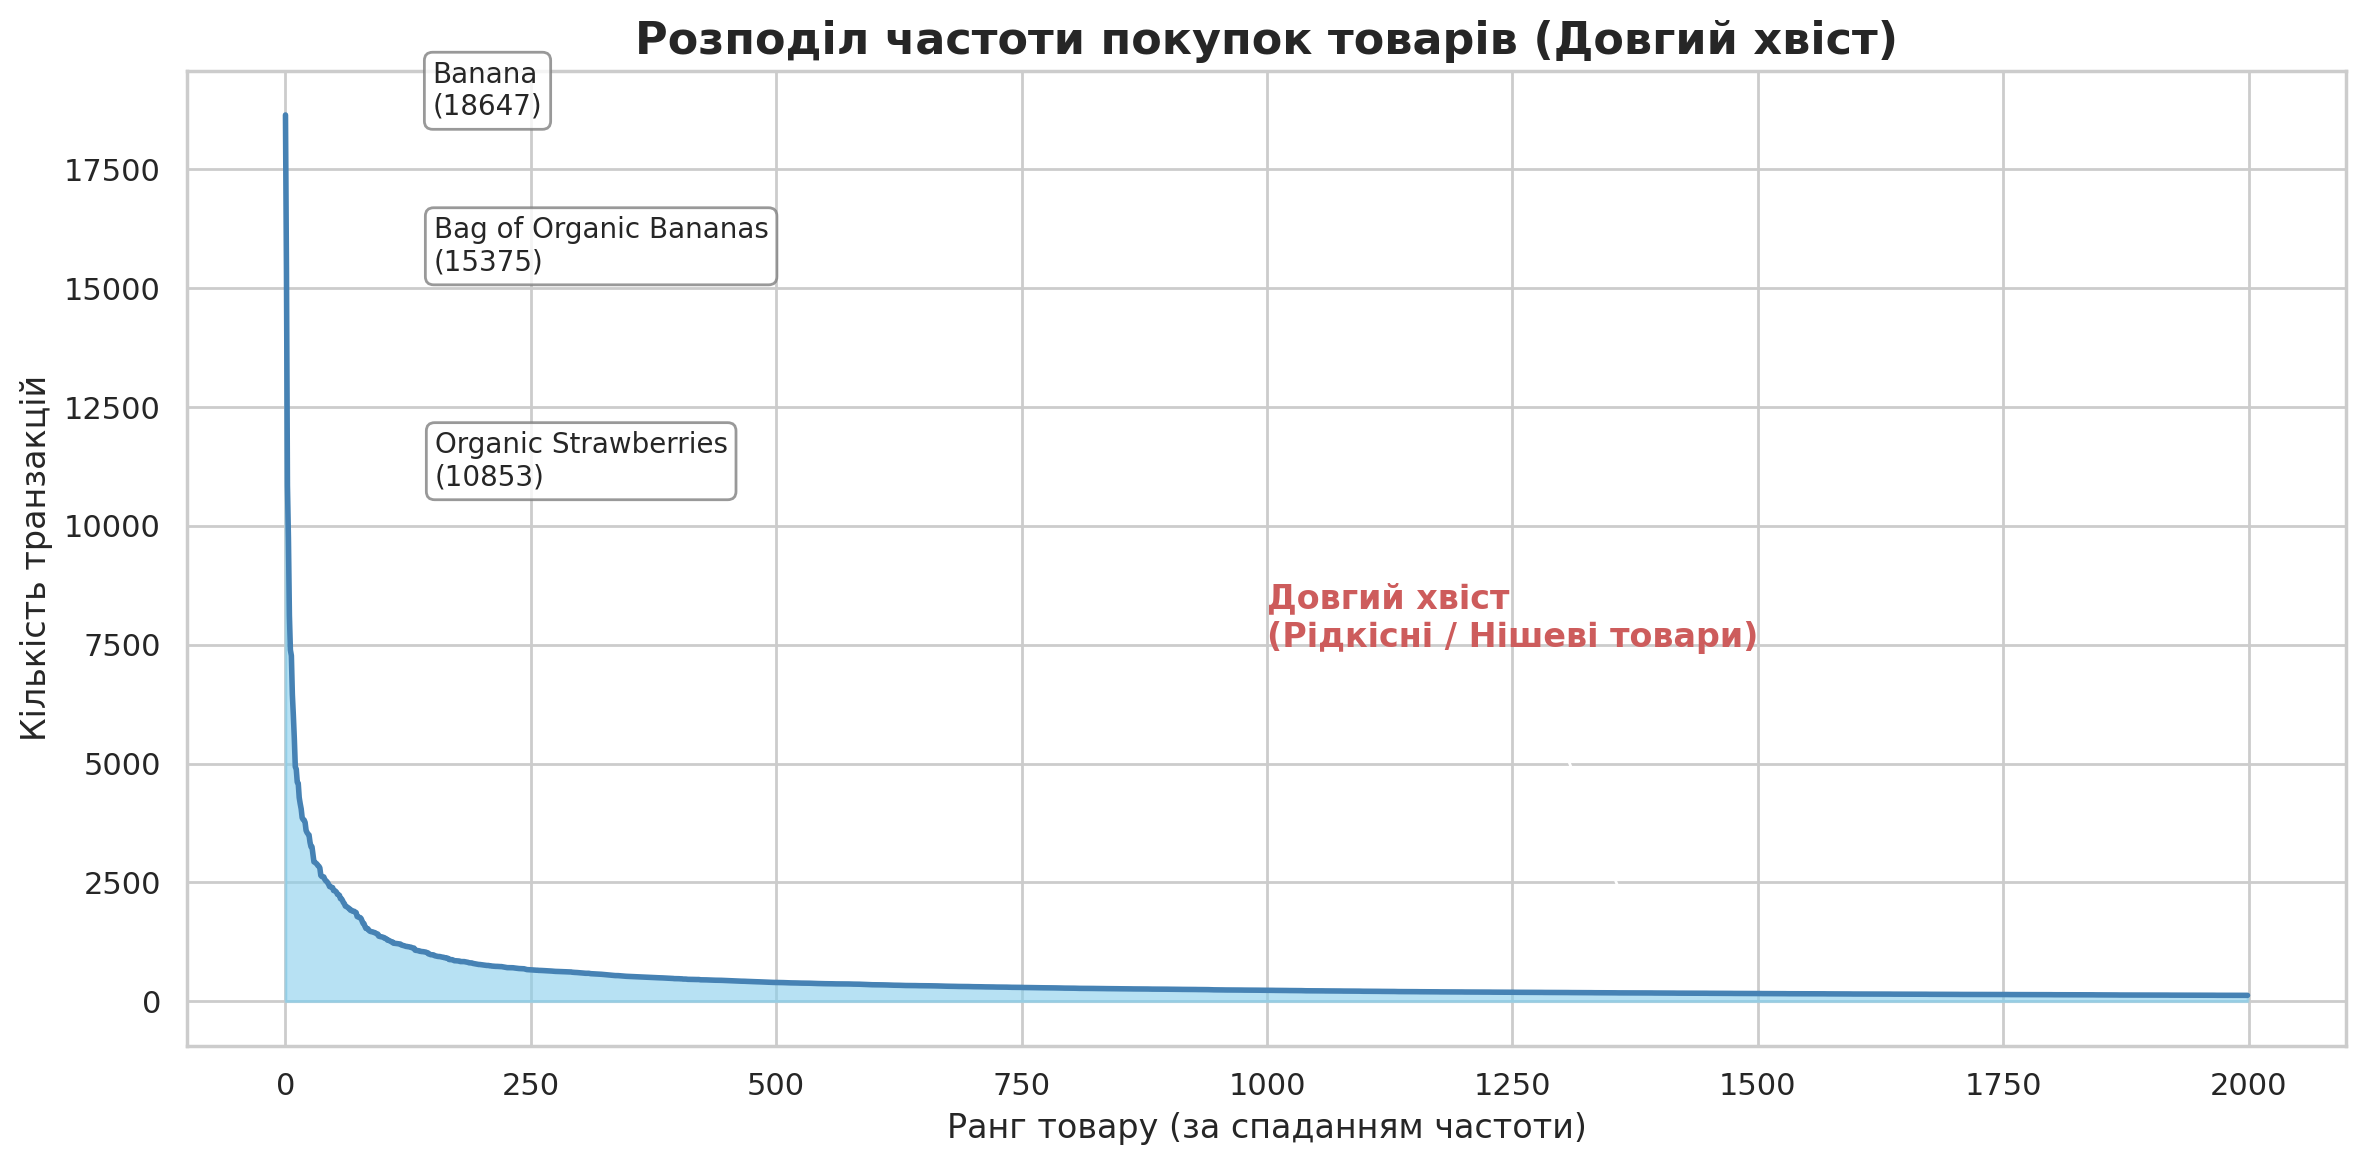

In [ ]:
item_counts = defaultdict(int)
with open("transactions.txt", "r", encoding="utf-8") as f:
    for line in f:
        items = [int(x) for x in line.strip().split() if x.strip() != '']
        for item in set(items):
            item_counts[item] += 1

df_freq = pd.DataFrame(list(item_counts.items()), columns=['product_id', 'frequency'])

pdf_products = products.select("product_id", "product_name").toPandas()
df_freq = df_freq.merge(pdf_products, on='product_id', how='left')

df_freq = df_freq.sort_values(by='frequency', ascending=False).reset_index(drop=True)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 6))

data_to_plot = df_freq.head(2000)

ax.fill_between(range(len(data_to_plot)), data_to_plot['frequency'], color="skyblue", alpha=0.6)
ax.plot(range(len(data_to_plot)), data_to_plot['frequency'], color="steelblue", linewidth=2)

ax.set_title("Розподіл частоти покупок товарів (Довгий хвіст)", fontsize=16, fontweight='bold')
ax.set_xlabel("Ранг товару (за спаданням частоти)", fontsize=12)
ax.set_ylabel("Кількість транзакцій", fontsize=12)

for i in range(3):
    prod_name = data_to_plot.iloc[i]['product_name']
    freq = data_to_plot.iloc[i]['frequency']
    ax.annotate(f"{prod_name}\n({freq})",
                xy=(i, freq),
                xytext=(i + 150, freq),
                arrowprops=dict(facecolor='black', arrowstyle="->", connectionstyle="arc3"),
                fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

ax.annotate("Довгий хвіст\n(Рідкісні / Нішеві товари)",
            xy=(len(data_to_plot)*0.7, data_to_plot['frequency'].iloc[int(len(data_to_plot)*0.7)]),
            xytext=(len(data_to_plot)*0.5, data_to_plot['frequency'].max()*0.4),
            arrowprops=dict(facecolor='indianred', arrowstyle="->"),
            fontsize=12, color='indianred', fontweight='bold')

plt.tight_layout()
plt.show()

# Rules filtering by departments

In [ ]:
p2p_rules = make_rules_advanced("charm_output.txt", n_rules=500, minConfidence=0.0, minLift=0.0, show=False, filter="weighted_score", filter_mode='absolute', pandas_df=filtered_clusters_by_similarity_1, mode='both', department_mode=False, multy=False, lift_w=1, ipf_w=1, conf_w=1)

Base Rules:
Number of rules: 45186
 - Base rules saved to association_rules.xlsx
Filtered Rules
 - Filtered rules saved to association_rules_filtered.xlsx
Number of filtered rules: 40102
+-------+--------------------------------------------------------------------+--------------------------------------------------------------------+----------+--------+--------+-------------+--------+--------+--------------+---------------+--------+
|rule_id|antecedent_names                                                    |consequent_names                                                    |confidence|lift    |log_lift|norm_log_lift|rule_ipf|norm_ipf|weighted_score|weighted_score2|support |
+-------+--------------------------------------------------------------------+--------------------------------------------------------------------+----------+--------+--------+-------------+--------+--------+--------------+---------------+--------+
|1      |[Protein Bar Mint Chocolate]                             

In [ ]:
p2p_rules_dept = make_rules_advanced("charm_output.txt", n_rules=500, minConfidence=0.0, minLift=0.0, show=False, filter="weighted_score", filter_mode='absolute', pandas_df=filtered_clusters_by_similarity_1, mode='both', department_mode=True, multy=False, lift_w=1, ipf_w=1, conf_w=1)

Base Rules:
Number of rules: 38480
 - Base rules saved to association_rules.xlsx
Filtered Rules
 - Filtered rules saved to association_rules_filtered.xlsx
Number of filtered rules: 34118
+-------+--------------------------------------------------------------------+--------------------------------------------------------------------+----------+--------+--------+-------------+--------+--------+--------------+---------------+--------+
|rule_id|antecedent_names                                                    |consequent_names                                                    |confidence|lift    |log_lift|norm_log_lift|rule_ipf|norm_ipf|weighted_score|weighted_score2|support |
+-------+--------------------------------------------------------------------+--------------------------------------------------------------------+----------+--------+--------+-------------+--------+--------+--------------+---------------+--------+
|1      |[Protein Bar Mint Chocolate]                             

Визначаємо правила, що були видалені під час додаткової фільтрації по department

In [ ]:
df_all = p2p_rules.withColumn("join_a", F.col("antecedent_names").cast("string")) \
                  .withColumn("join_c", F.col("consequent_names").cast("string"))

df_dept = p2p_rules_dept.select(
    F.col("antecedent_names").cast("string").alias("join_a"),
    F.col("consequent_names").cast("string").alias("join_c")
)

removed_rules = df_all.join(df_dept, on=["join_a", "join_c"], how="left_anti") \
                      .drop("join_a", "join_c") \
                      .orderBy(F.col("weighted_score").desc())

In [ ]:
display_rules(removed_rules, n_rows=50, max_name_len=45, interval=None)

ID,Antecedent,Consequent,Conf.,Lift,NLift,IPF,NIPF,W-Score,Supp.
6,Milk Chocolate Candy Bars,Honey Maid Graham Crackers,0.2414,132.2418,0.8146,6.3060,0.8389,0.1649,0.000113
9,Cheez-It Baked Snack Crackers,Popcorn,0.2113,103.0356,0.7730,6.1897,0.8157,0.1332,0.000241
12,Crispy Cheddar Crackers,Mini Chocolate Chunk Cookies,0.1500,149.2368,0.8347,6.9027,0.9576,0.1199,0.000145
13,Cheez-It Baked Snack Crackers,Mixed Fruit Fruit Snacks,0.2465,63.5956,0.6925,5.5530,0.6890,0.1176,0.000281
14,Pears,Clementines,0.3950,37.6099,0.6049,4.5562,0.4907,0.1172,0.000378
15,Mini Chocolate Chunk Cookies,Crispy Cheddar Crackers,0.1440,149.2368,0.8347,6.9027,0.9576,0.1151,0.000145
18,Fabric Softener Dryer Sheet Outdoor Fresh ...,Tall Kitchen Bag With Febreze Odor Shield,0.1505,118.4903,0.7962,6.6684,0.9110,0.1092,0.000113
21,Pub Mix,Milk Chocolate Almonds,0.1765,87.4366,0.7456,6.2055,0.8189,0.1078,0.000217
22,Red Delicious Apples,Clementines,0.3524,33.5555,0.5859,4.5562,0.4907,0.1013,0.000298
23,Apples,Clementines,0.3443,32.7824,0.5820,4.5562,0.4907,0.0983,0.000844


Видаляються такі правила як (вибірка правил):

$$
\begin{array}{|l|l|c|c|c|c|c|c|c|}
\hline
\text{antecedent_names} & \text{consequent_names} & \text{confidence} & \text{lift} & \text{log_lift} & \text{mean_ipf} & \text{weighted_score} & \text{weighted_score2} & \text{support} \\
\hline
\text{Milk Chocolate Candy} & \text{Honey Maid Graham Crackers} & 0.2414 & 132.2418 & 4.8846 & 6.9883 & 8.2395 & 10.7198 & 1.13E-4 \\
\hline
\text{Pasture Raised Salted Butter} & \text{Large Alfresco Eggs} & 0.3684 & 24.2297 & 3.1876 & 6.1397 & 7.2103 & 10.6773 & 1.13E-4 \\
\hline
\text{Cheez-It Baked Snack Crackers} & \text{Popcorn} & 0.2113 & 103.0356 & 4.6351 & 6.4824 & 6.3479 & 8.1569 & 2.41E-4 \\
\hline
\text{Cheez-It Baked Snack Crackers} & \text{Mixed Fruit Fruit Snacks} & 0.2465 & 63.5956 & 4.1525 & 6.1641 & 6.309 & 8.3679 & 2.81E-4 \\
\hline
\text{Crispy Cheddar Crackers} & \text{Mini Chocolate Chunk Cookies} & 0.15 & 149.2368 & 5.0055 & 6.9231 & 5.198 & 6.6378 & 1.45E-4 \\
\hline
\text{Pub Mix} & \text{Milk Chocolate Almonds} & 0.1765 & 87.4366 & 4.4709 & 6.453 & 5.0913 & 6.6552 & 2.17E-4 \\
\hline
\text{Mini Chocolate Chunk Cookies} & \text{Crispy Cheddar Crackers} & 0.144 & 149.2368 & 5.0055 & 6.9231 & 4.9901 & 6.3723 & 1.45E-4 \\
\hline
\text{Fabric Softener Dryer Sheet Outdoor Fresh 160CT Fabric Enhancers} & \text{Tall Kitchen Bag With Febreze Odor Shield} & 0.1505 & 118.4903 & 4.7748 & 6.9334 & 4.9836 & 6.5352 & 1.13E-4 \\
\hline
\text{Pistachios} & \text{Milk Chocolate Almonds} & 0.1584 & 78.4909 & 4.363 & 6.6607 & 4.6036 & 6.1917 & 1.29E-4 \\
\hline
\text{Cheez-It Baked Snack Crackers} & \text{Crunchy Oats 'n Honey Granola Bars} & 0.169 & 61.4598 & 4.1184 & 6.3356 & 4.41 & 5.9534 & 1.93E-4 \\
\hline
\text{YoTot Organic Raspberry Pear Yogurt} & \text{Organic Whole Milk} & 0.3333 & 8.4931 & 2.1393 & 5.6526 & 4.0308 & 6.5361 & 1.05E-4 \\
\hline
\text{100% Natural Diced Tomatoes} & \text{Black Beans} & 0.1917 & 32.519 & 3.4818 & 6.0386 & 4.0299 & 5.7362 & 1.85E-4 \\
\hline
\text{Variety Diet Tea} & \text{Soda} & 0.2222 & 20.2762 & 3.0094 & 5.9839 & 4.0018 & 5.9911 & 1.29E-4 \\
\hline
\text{Traditional Italian Sauce} & \text{Spaghetti Pasta} & 0.1484 & 43.0163 & 3.7616 & 6.1785 & 3.4487 & 4.7977 & 1.85E-4 \\
\hline
\text{Organic Crimini Mushrooms} & \text{Packaged Grape Tomatoes} & 0.1631 & 33.748 & 3.5189 & 5.8062 & 3.3322 & 4.6448 & 3.06E-4 \\
\hline
\text{Cheez-It Cheddar Cracker} & \text{Organic Simply Naked Pita Chips} & 0.1411 & 42.6966 & 3.7541 & 6.1748 & 3.2709 & 4.5532 & 1.85E-4 \\
\hline
\text{Sweet & Salty Nut Granola Bars Peanut} & \text{Cheez-It Baked Snack Crackers} & 0.1056 & 92.5144 & 4.5274 & 6.7751 & 3.2402 & 4.3151 & 1.21E-4 \\
\hline
\text{Cheez-It Baked Snack Crackers} & \text{Sweet & Salty Nut Granola Bars Peanut} & 0.1056 & 92.5144 & 4.5274 & 6.7751 & 3.2402 & 4.3151 & 1.21E-4 \\
\hline
\end{array}
$$

Нам необхідно перетворити транзації, а саме кожному товару призначити його department. Це зробимо в 3 етами:

Нехай маємо транзацію $[Товар_1, Товар_2, Товар_3, Товар_4, Товар_5]$, тоді:

1. Робимо заміну: $Товар_N → Departpment(Товар_N)$.

Після заміни нехай маємо: $[Department_1, Department_1, Department_2, Department_1, Department_1]$

2. Групуємо так, щоб кожного $Department_N$ не було більше ніж 1.

Після группування маємо: $[Department_1, Department_2]$

3. Видаляємо транзакції, що мають лише 1 department.

Після чого на отриманих транзаціях проводимо пошук правил за CHARM.

In [ ]:
pdf = products.select("product_id", "department_id").toPandas()

pdf['product_id'] = pd.to_numeric(pdf['product_id'], errors='coerce')
pdf['department_id'] = pd.to_numeric(pdf['department_id'], errors='coerce')

pdf = pdf.dropna(subset=['product_id', 'department_id'])
prod_to_dept = dict(zip(pdf['product_id'].astype(int), pdf['department_id'].astype(int)))

input_file = "transactions.txt"
output_file = "transactions_departments.txt"

with open(input_file, 'r', encoding='utf-8') as f_in, \
     open(output_file, 'w', encoding='utf-8') as f_out:

    for line in f_in:
        items = line.strip().split()
        if not items:
            continue

        dept_list = []
        for item in items:
            try:
                pid = int(item)
                if pid in prod_to_dept:
                    dept_list.append(prod_to_dept[pid])
            except ValueError:
                continue

        unique_depts = set(dept_list)

        if len(unique_depts) > 1:
            f_out.write(" ".join(map(str, sorted(list(unique_depts)))) + "\n")

Створюємо часті набори

In [ ]:
input_filename = "transactions_departments.txt"
output_filename = "charm_departments_output.txt"
memory_allocation = "-Xmx8g"
spmf_jar_path = "spmf.jar"
min_support = "5%"

command = [
    "java",
    memory_allocation,
    "-jar",
    spmf_jar_path,
    "run",
    "Charm_bitset",
    input_filename,
    output_filename,
    str(min_support)
]

print(f"Running: {' '.join(command)}")

try:
    result = subprocess.run(command, capture_output=True, text=True, check=True, encoding='utf-8')

    print("\n--- STDOUT (SPMF Stats) ---")
    print(result.stdout)

    if result.stderr:
        print("\n--- STDERR ---")
        print(result.stderr)

    print(f"\nThe CHARM algorithm has been successfully executed..")
    print(f"The results are saved to '{output_filename}'.")

except subprocess.CalledProcessError as e:
    print("\n--- SPMF RUNTIME ERROR ---")
    print("Return code:", e.returncode)
    print("Stdout:", e.stdout)
    print("Stderr:", e.stderr)

Running: java -Xmx8g -jar spmf.jar run Charm_bitset transactions_departments.txt charm_departments_output.txt 5%

--- STDOUT (SPMF Stats) ---
[0.029s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.030s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
>/content/spmf.jar
=============  CHARM v96r6 Bitset - STATS =============
 Transactions count from database : 119244
 Frequent closed itemsets count : 457
 Total time ~ 365 ms
 Maximum memory usage : 32.91767120361328 mb


The CHARM algorithm has been successfully executed..
The results are saved to 'charm_departments_output.txt'.


Функція make_dept_rules() - призначена для створення правил для department рівня

In [ ]:
def make_dept_rules(
    frequent_items_path,
    departments_df,
    min_confidence=0.1,
    min_lift=1.0,
    conf_w=1, lift_w=1, ipf_w=1,
    show=False,
    n_rules=20,
    filter_col="lift",
    multy=False,
    target_department=None
):

    freq_itemsets = []
    pattern = re.compile(r'^\s*([\d]+(?:\s+[\d]+)*)\s+#SUP\s*:\s*([0-9]+)\s*$', flags=re.IGNORECASE)

    N_transactions = 0
    with open("transactions_departments.txt", 'r', encoding='utf-8') as f:
        for _ in f:
            if not _:
                continue
            N_transactions += 1

    with open(frequent_items_path, 'r', encoding='utf-8') as f:
        for line in f:
            s = line.strip()
            if not s: continue
            m = pattern.match(s)
            if m:
                items = tuple(sorted(int(x) for x in re.split(r'\s+', m.group(1).strip()) if x != ''))
                support_count = int(m.group(2))
                freq_itemsets.append((items, support_count))

    freq_dict = {tuple(sorted(items)): sup for items, sup in freq_itemsets}

    rules = []
    candidates = []

    if multy:
        for items, sup_xy in freq_itemsets:
            if len(items) < 2:
                continue
            items = tuple(sorted(items))
            for i in range(1, len(items)):
                for X in itertools.combinations(items, i):
                    Y = tuple(sorted(set(items) - set(X)))
                    sup_x = freq_dict.get(tuple(sorted(X)))
                    sup_y = freq_dict.get(tuple(sorted(Y)))

                    if sup_x and sup_y and sup_x > 0 and sup_y > 0:
                        candidates.append((tuple(sorted(X)), tuple(sorted(Y)), sup_xy, sup_x, sup_y))
    else:
        pair_keys = [k for k in freq_dict.keys() if len(k) == 2]
        for pair in pair_keys:
            pair_sorted = tuple(sorted(pair))
            sup_xy = freq_dict.get(pair_sorted)
            a, b = pair_sorted
            sup_a = freq_dict.get((a,))
            sup_b = freq_dict.get((b,))
            if sup_xy and sup_a and sup_b and sup_a > 0 and sup_b > 0:
                candidates.append(((a,), (b,), sup_xy, sup_a, sup_b))
                candidates.append(((b,), (a,), sup_xy, sup_b, sup_a))

    for X, Y, sup_xy, sup_x, sup_y in candidates:
        P_xy = sup_xy / N_transactions
        P_x = sup_x / N_transactions
        P_y = sup_y / N_transactions

        confidence = P_xy / P_x if P_x > 0 else 0.0
        lift = confidence / P_y if P_y > 0 else 0.0

        if confidence < min_confidence or lift < min_lift:
            continue

        all_item_ids = list(X) + list(Y)
        item_informations = []

        for dept_id in all_item_ids:
            item_count = freq_dict.get((dept_id,))
            if item_count:
                item_prob = item_count / N_transactions
                info = -math.log(item_prob)
                item_informations.append(info)
            else:
                item_informations.append(0.0)

        mean_ipf = sum(item_informations) / len(item_informations) if item_informations else 0.0
        log_lift = math.log(lift) if lift > 1 else 0.001

        rules.append(Row(
            antecedent=list(X),
            consequent=list(Y),
            support=float(round(P_xy, 6)),
            confidence=float(round(confidence, 4)),
            lift=float(round(lift, 4)),
            log_lift=float(round(log_lift, 4)),
            mean_ipf=float(round(mean_ipf, 4))
        ))

    if not rules:
        print("No Rules found based on the given thresholds.")
        return None

    rules_df = spark.createDataFrame(rules)

    bounds = rules_df.select(
        F.min("log_lift").alias("min_log_lift"),
        F.max("log_lift").alias("max_log_lift"),
        F.min("mean_ipf").alias("min_ipf"),
        F.max("mean_ipf").alias("max_ipf")
    ).first()

    min_log_lift, max_log_lift = bounds["min_log_lift"], bounds["max_log_lift"]
    min_ipf, max_ipf = bounds["min_ipf"], bounds["max_ipf"]

    denom_log_lift = (max_log_lift - min_log_lift) if (max_log_lift - min_log_lift) > 0 else 1.0
    denom_ipf = (max_ipf - min_ipf) if (max_ipf - min_ipf) > 0 else 1.0

    rules_df = rules_df.withColumn(
        "norm_log_lift", (F.col("log_lift") - F.lit(min_log_lift)) / F.lit(denom_log_lift)
    ).withColumn(
        "norm_ipf", (F.col("mean_ipf") - F.lit(min_ipf)) / F.lit(denom_ipf)
    ).withColumn(
        "weighted_score",
        F.pow(F.col("norm_log_lift"), lift_w) * F.pow(F.col("norm_ipf"), ipf_w) * F.pow(F.col("confidence"), conf_w)
    ).withColumn(
        "weighted_score", F.round(F.col("weighted_score"), 4)
    ).withColumn(
        "norm_log_lift", F.round(F.col("norm_log_lift"), 4)
    ).withColumn(
        "norm_ipf", F.round(F.col("norm_ipf"), 4)
    )

    dept_df_clean = departments_df.withColumn("department_id", F.col("department_id").cast("int"))

    antecedent_df = (
        rules_df
        .withColumn("antecedent_id", F.explode("antecedent"))
        .join(dept_df_clean, F.col("antecedent_id") == F.col("department_id"), "left")
        .groupBy("antecedent", "consequent", "support", "confidence", "lift", "log_lift", "norm_log_lift", "mean_ipf", "norm_ipf", "weighted_score")
        .agg(F.collect_list("department").alias("antecedent_names"))
    )

    final_rules = (
        antecedent_df
        .withColumn("consequent_id", F.explode("consequent"))
        .join(dept_df_clean, F.col("consequent_id") == F.col("department_id"), "left")
        .groupBy("antecedent", "consequent", "support", "confidence", "lift", "log_lift", "norm_log_lift", "mean_ipf", "norm_ipf", "weighted_score", "antecedent_names")
        .agg(F.collect_list("department").alias("consequent_names"))
    )

    out_cols = ["antecedent_names", "consequent_names", "confidence", "lift", "log_lift","norm_log_lift", "mean_ipf", "norm_ipf", "weighted_score", "support"]

    if target_department is not None:
        final_rules = final_rules.filter(F.array_contains(F.col("antecedent_names"), target_department))

    if filter_col not in out_cols:
        print(f"Warning: filter_col '{filter_col}' not found. Defaulting to 'lift'.")
        filter_col = "lift"

    result_df = final_rules.select(*out_cols).orderBy(F.col(filter_col).desc())

    total_rules = result_df.count()
    print(f"Base Rules:")
    print(f"Number of rules: {total_rules}")

    if show:
        result_df.show(n_rules, truncate=False)

    return result_df

In [ ]:
dept_rules = make_dept_rules(
    frequent_items_path="charm_departments_output.txt",
    departments_df=departments,
    min_confidence=0.1,
    min_lift=1.0,
    show=True,
    n_rules=50,
    filter_col="weighted_score",
    multy=True
)

Base Rules:
Number of rules: 4355
+-------------------------------------+--------------------+----------+------+--------+-------------+--------+--------+--------------+--------+
|antecedent_names                     |consequent_names    |confidence|lift  |log_lift|norm_log_lift|mean_ipf|norm_ipf|weighted_score|support |
+-------------------------------------+--------------------+----------+------+--------+-------------+--------+--------+--------------+--------+
|[dry goods pasta, pantry]            |[canned goods]      |0.4718    |1.9203|0.6525  |0.955        |1.2878  |0.7531  |0.3393        |0.052741|
|[frozen, canned goods]               |[dry goods pasta]   |0.4114    |1.9021|0.643   |0.941        |1.2649  |0.7359  |0.2849        |0.052632|
|[pantry, canned goods]               |[dry goods pasta]   |0.4049    |1.8723|0.6272  |0.9179       |1.2878  |0.7531  |0.2799        |0.052741|
|[dry goods pasta, canned goods]      |[pantry]            |0.6019    |1.5229|0.4206  |0.6149       |1

In [ ]:
dept_rules = make_dept_rules(
    frequent_items_path="charm_departments_output.txt",
    departments_df=departments,
    min_confidence=0.1,
    min_lift=1.0,
    show=True,
    n_rules=50,
    filter_col="weighted_score",
    multy=False
)

Base Rules:
Number of rules: 148
+-----------------+-----------------+----------+------+--------+-------------+--------+--------+--------------+--------+
|antecedent_names |consequent_names |confidence|lift  |log_lift|norm_log_lift|mean_ipf|norm_ipf|weighted_score|support |
+-----------------+-----------------+----------+------+--------+-------------+--------+--------+--------------+--------+
|[dry goods pasta]|[canned goods]   |0.4051    |1.6491|0.5003  |1.0          |1.4675  |0.888   |0.3597        |0.087619|
|[canned goods]   |[dry goods pasta]|0.3566    |1.6491|0.5003  |1.0          |1.4675  |0.888   |0.3167        |0.087619|
|[meat seafood]   |[dry goods pasta]|0.3236    |1.4961|0.4029  |0.8032       |1.5644  |0.9608  |0.2497        |0.065479|
|[breakfast]      |[snacks]         |0.6187    |1.3108|0.2706  |0.5358       |1.2263  |0.7069  |0.2343        |0.112811|
|[dry goods pasta]|[meat seafood]   |0.3028    |1.4961|0.4029  |0.8032       |1.5644  |0.9608  |0.2337        |0.065479|

Отримання правил за конкретним department:

In [ ]:
dept_rules = make_dept_rules(
    frequent_items_path="charm_departments_output.txt",
    departments_df=departments,
    min_confidence=0.1,
    min_lift=1.0,
    show=True,
    n_rules=50,
    filter_col="weighted_score",
    multy=True,
    target_department="meat seafood"
)

Base Rules:
Number of rules: 220
+----------------------------------------+-----------------------------+----------+------+--------+-------------+--------+--------+--------------+--------+
|antecedent_names                        |consequent_names             |confidence|lift  |log_lift|norm_log_lift|mean_ipf|norm_ipf|weighted_score|support |
+----------------------------------------+-----------------------------+----------+------+--------+-------------+--------+--------+--------------+--------+
|[meat seafood]                          |[dry goods pasta]            |0.3236    |1.4961|0.4029  |0.5889       |1.5644  |0.9608  |0.1831        |0.065479|
|[meat seafood, snacks]                  |[frozen]                     |0.6022    |1.4228|0.3526  |0.5152       |1.0694  |0.5891  |0.1828        |0.061689|
|[dry goods pasta, meat seafood]         |[produce, dairy eggs]        |0.8215    |1.3728|0.3168  |0.4627       |0.9247  |0.4804  |0.1826        |0.053789|
|[meat seafood, snacks]        

In [ ]:
dept_rules = make_dept_rules(
    frequent_items_path="charm_departments_output.txt",
    departments_df=departments,
    min_confidence=0.1,
    min_lift=1.0,
    show=True,
    n_rules=50,
    filter_col="confidence",
    multy=False,
    target_department="meat seafood"
)

Base Rules:
Number of rules: 10
+----------------+-----------------+----------+------+--------+-------------+--------+--------+--------------+--------+
|antecedent_names|consequent_names |confidence|lift  |log_lift|norm_log_lift|mean_ipf|norm_ipf|weighted_score|support |
+----------------+-----------------+----------+------+--------+-------------+--------+--------+--------------+--------+
|[meat seafood]  |[produce]        |0.8821    |1.1247|0.1176  |0.2266       |0.9203  |0.4771  |0.0954        |0.178516|
|[meat seafood]  |[dairy eggs]     |0.812     |1.1259|0.1186  |0.2286       |0.9622  |0.5086  |0.0944        |0.164327|
|[meat seafood]  |[frozen]         |0.5135    |1.2132|0.1933  |0.3795       |1.2287  |0.7087  |0.1381        |0.103913|
|[meat seafood]  |[snacks]         |0.5062    |1.0724|0.0699  |0.1302       |1.1742  |0.6678  |0.044         |0.102445|
|[meat seafood]  |[beverages]      |0.5039    |1.0193|0.0191  |0.0275       |1.1511  |0.6504  |0.009         |0.101967|
|[meat s

# Saving results

In [ ]:
p2p_rules_0 = make_rules_advanced("charm_output.txt", n_rules=500, minConfidence=0.0, minLift=0.0, show=False, filter="weighted_score", filter_mode='absolute', pandas_df=filtered_clusters_by_similarity_1, mode=None, multy=False, lift_w=1, ipf_w=1, conf_w=1)

In [ ]:
p2p_rules_1 = make_rules_advanced("charm_output.txt", n_rules=500, minConfidence=0.0, minLift=0.0, show=False, filter="weighted_score", filter_mode='absolute', pandas_df=filtered_clusters_by_similarity_1, mode='aisle', multy=False, lift_w=1, ipf_w=1, conf_w=1)

In [ ]:
p2p_rules_2 = make_rules_advanced("charm_output.txt", n_rules=500, minConfidence=0.0, minLift=0.0, show=False, filter="weighted_score", filter_mode='absolute', pandas_df=filtered_clusters_by_similarity_1, mode='both', multy=False, lift_w=1, ipf_w=1, conf_w=1)

In [ ]:
p2p_rules_3 = make_rules_advanced("charm_output.txt", n_rules=500, minConfidence=0.0, minLift=0.0, show=False, filter="weighted_score", filter_mode='absolute', pandas_df=filtered_clusters_by_similarity_1, mode='both', department_mode=True, multy=False, lift_w=1, ipf_w=1, conf_w=1)

In [ ]:
p2p_rules_0.write.mode("overwrite").parquet("rules_0_unfiltered.parquet")

In [ ]:
p2p_rules_1.write.mode("overwrite").parquet("rules_1_aisle.parquet")

In [ ]:
p2p_rules_2.write.mode("overwrite").parquet("rules_2_aisle_cluster.parquet")

In [ ]:
p2p_rules_3.write.mode("overwrite").parquet("rules_3_aisle_cluster_department.parquet")

In [ ]:
p2p_rules_01 = make_rules_advanced("charm_output.txt", n_rules=500, minConfidence=0.0, minLift=0.0, show=False, filter="weighted_score", filter_mode='absolute', pandas_df=filtered_clusters_by_similarity_1, mode=None, multy=True, lift_w=1, ipf_w=1, conf_w=1)

In [ ]:
p2p_rules_11 = make_rules_advanced("charm_output.txt", n_rules=500, minConfidence=0.0, minLift=0.0, show=False, filter="weighted_score", filter_mode='absolute', pandas_df=filtered_clusters_by_similarity_1, mode='aisle', multy=True, lift_w=1, ipf_w=1, conf_w=1)

In [ ]:
p2p_rules_21 = make_rules_advanced("charm_output.txt", n_rules=500, minConfidence=0.0, minLift=0.0, show=False, filter="weighted_score", filter_mode='absolute', pandas_df=filtered_clusters_by_similarity_1, mode='both', multy=True, lift_w=1, ipf_w=1, conf_w=1)

In [ ]:
p2p_rules_31 = make_rules_advanced("charm_output.txt", n_rules=500, minConfidence=0.0, minLift=0.0, show=False, filter="weighted_score", filter_mode='absolute', pandas_df=filtered_clusters_by_similarity_1, mode='both', department_mode=True, multy=True, lift_w=1, ipf_w=1, conf_w=1)

In [ ]:
p2p_rules_01.write.mode("overwrite").parquet("multy_rules_0_unfiltered.parquet")

In [ ]:
p2p_rules_11.write.mode("overwrite").parquet("multy_rules_1_aisle.parquet")

In [ ]:
p2p_rules_21.write.mode("overwrite").parquet("multy_rules_2_aisle_cluster.parquet")

In [ ]:
p2p_rules_31.write.mode("overwrite").parquet("multy_rules_3_aisle_cluster_department.parquet")

# Session Holder

In [ ]:
import time
from IPython.display import clear_output

minutes_to_wait = 480

try:
    for i in range(minutes_to_wait):
        clear_output(wait=True)
        print(f"⏳ Сесія підтримується. Минуло {i} з {minutes_to_wait} хвилин.")
        time.sleep(60)
    print("✅ 4 години минуло!")
except KeyboardInterrupt:
    print("\n🛑 Виконання зупинено вручну.")

⏳ Сесія підтримується. Минуло 0 з 480 хвилин.

🛑 Виконання зупинено вручну.
